# Connect Forest Management Model with Forest Carbon Budget Model

In [15]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [16]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [17]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons',  'bau_redchrs', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'bau_gldbr', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'bau_eqtslvr', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='redchris',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='max_st',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', options=('redchris', 'goldenbear', 'equitysilver', 'test'), value='redchri…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'bau_redchrs', 'redchrs_AAC_90…

Dropdown(description='Objective:', index=2, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='max_st')

In [18]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [19]:
#Start Calculating the Running Time
Start = time.time()

In [20]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [21]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [22]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [23]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [24]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/redchris_c_curves_p.pkl
Loaded data from ./inputs/curves/redchris_c_curves_f.pkl


In [25]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for redchris_max_st_no_cons...
running no_cons scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3667 rows, 34533 columns and 34533 nonzeros
Model fingerprint: 0x184cd756
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3667 rows and 34533 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.3250201e+08   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.01 work units)
Optimal objective  5.325020070e+08


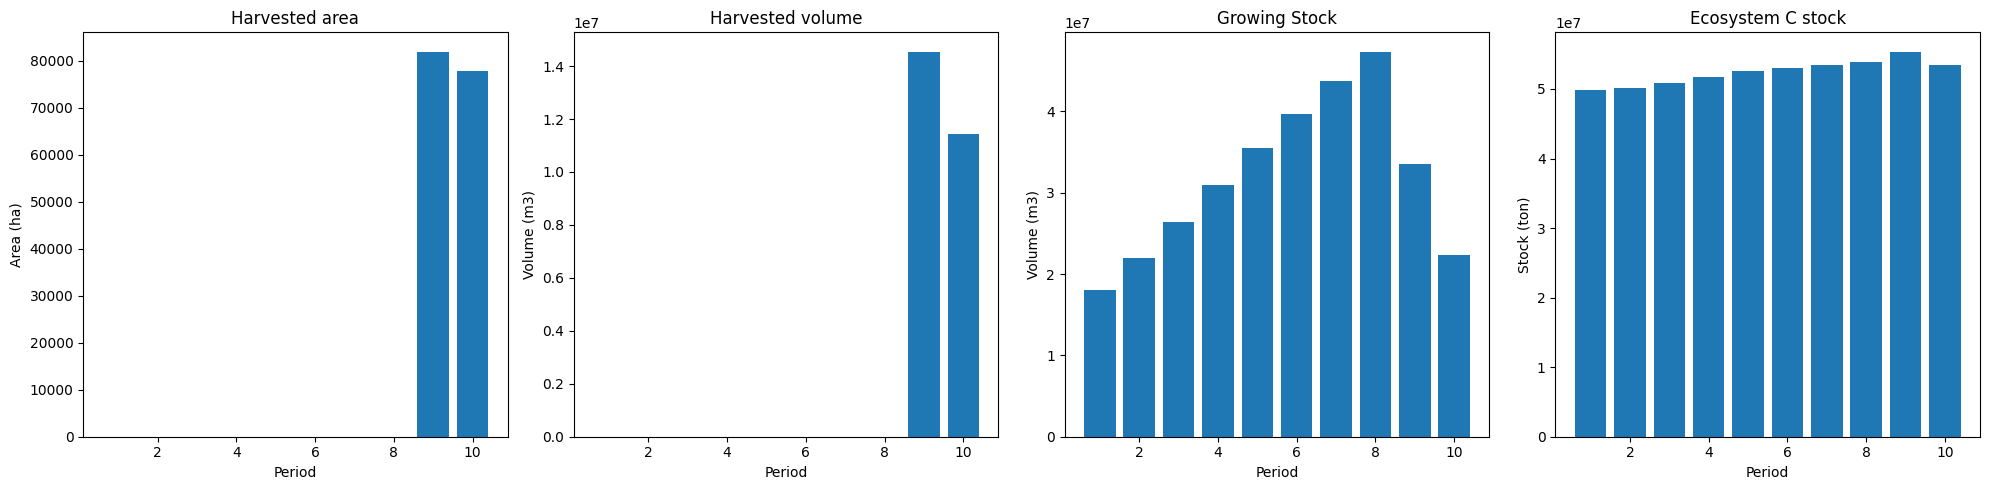

Plot saved to ./outputs/fig/redchris/redchris_max_st_no_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  27450
The economic indicator (the provincial government revenues) is:  936119
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


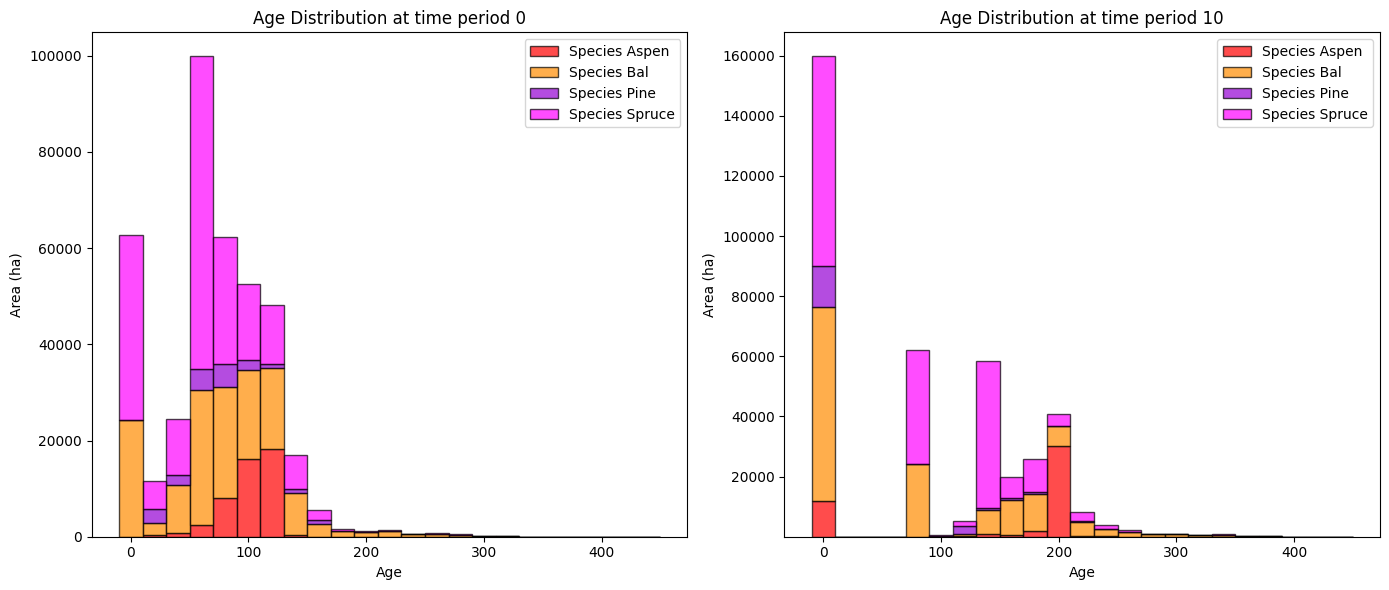

Plot saved to ./outputs/fig/redchris/redchris_max_st_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  33570.534690  32625.221002
Pine     602.782616   1505.368343    902.585727
Bal     4315.588546  27951.218565  23635.630019
Spruce  1072.814408  12878.635366  11805.820959

Overall diversity has **increased** by 68969.26 hectares from time period 0 to time period 10.


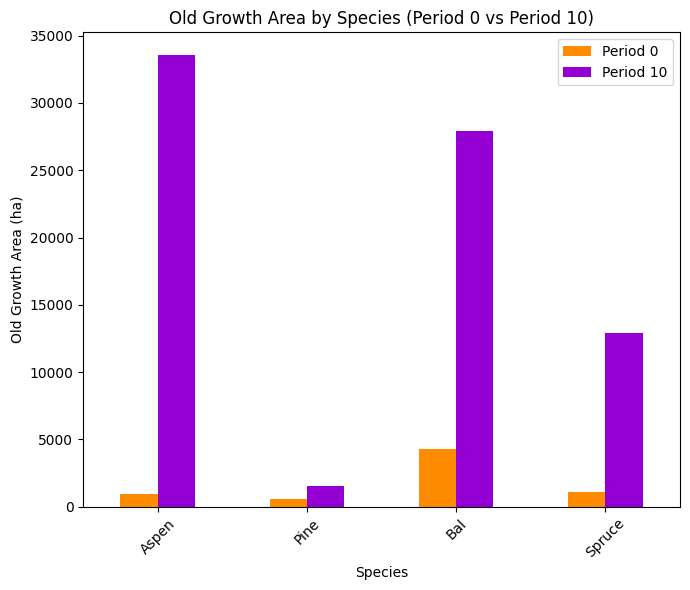

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8196

Diversity has **decreased** by 6.53% from time 0 to time 10.


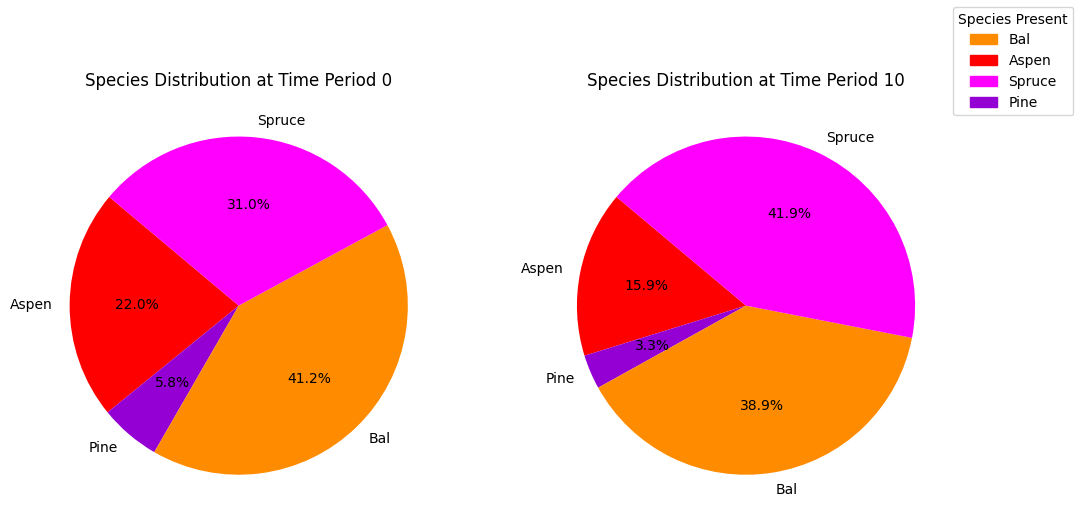

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_no_cons_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s



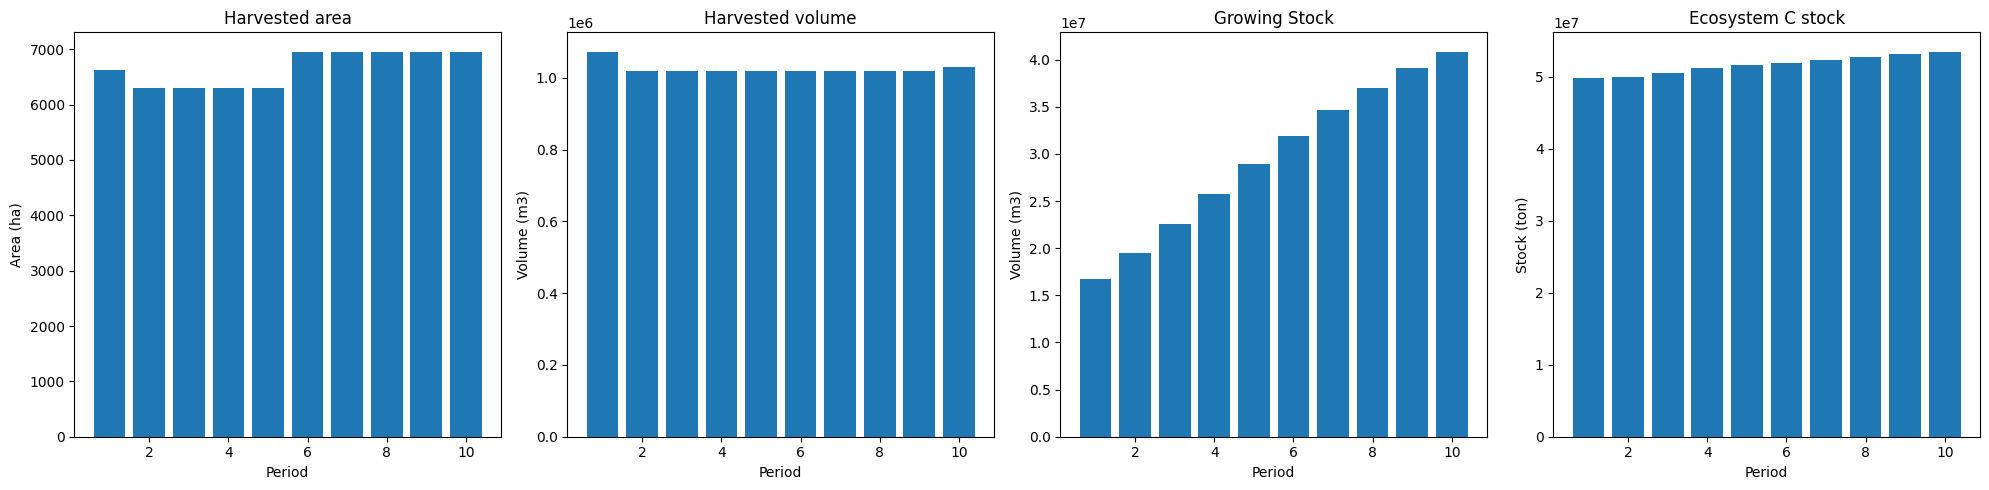

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


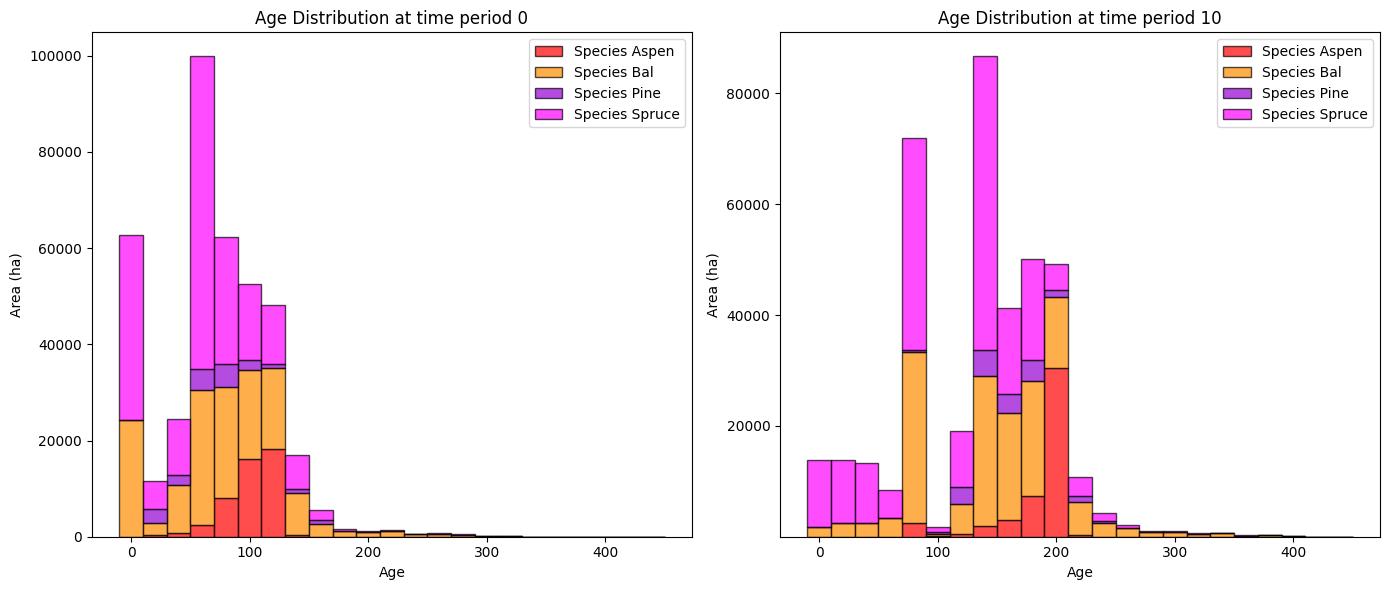

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


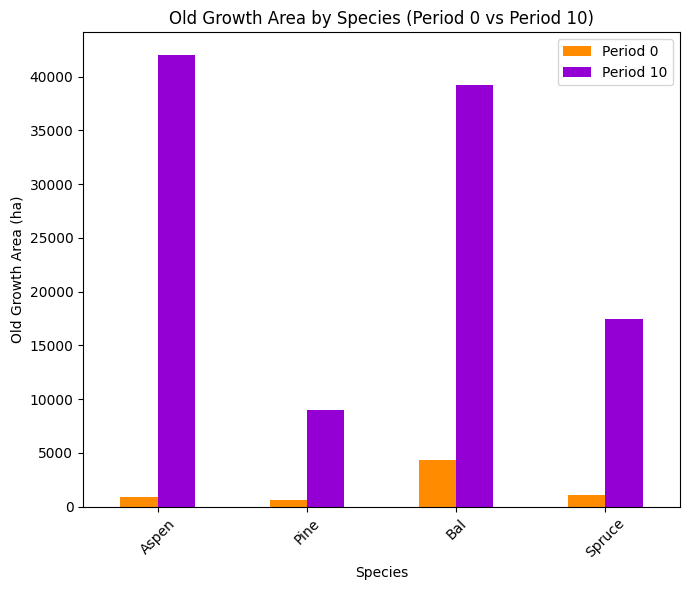

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


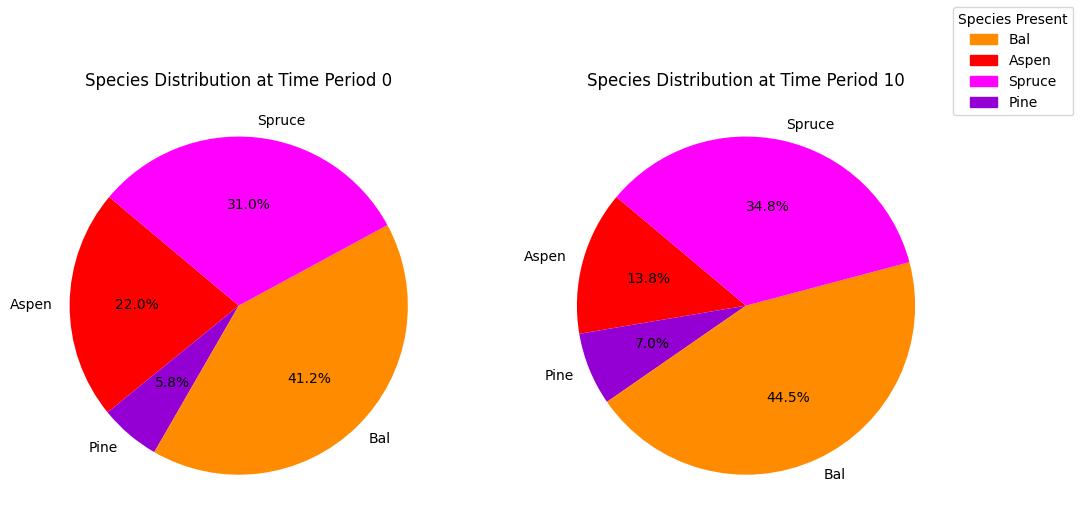

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


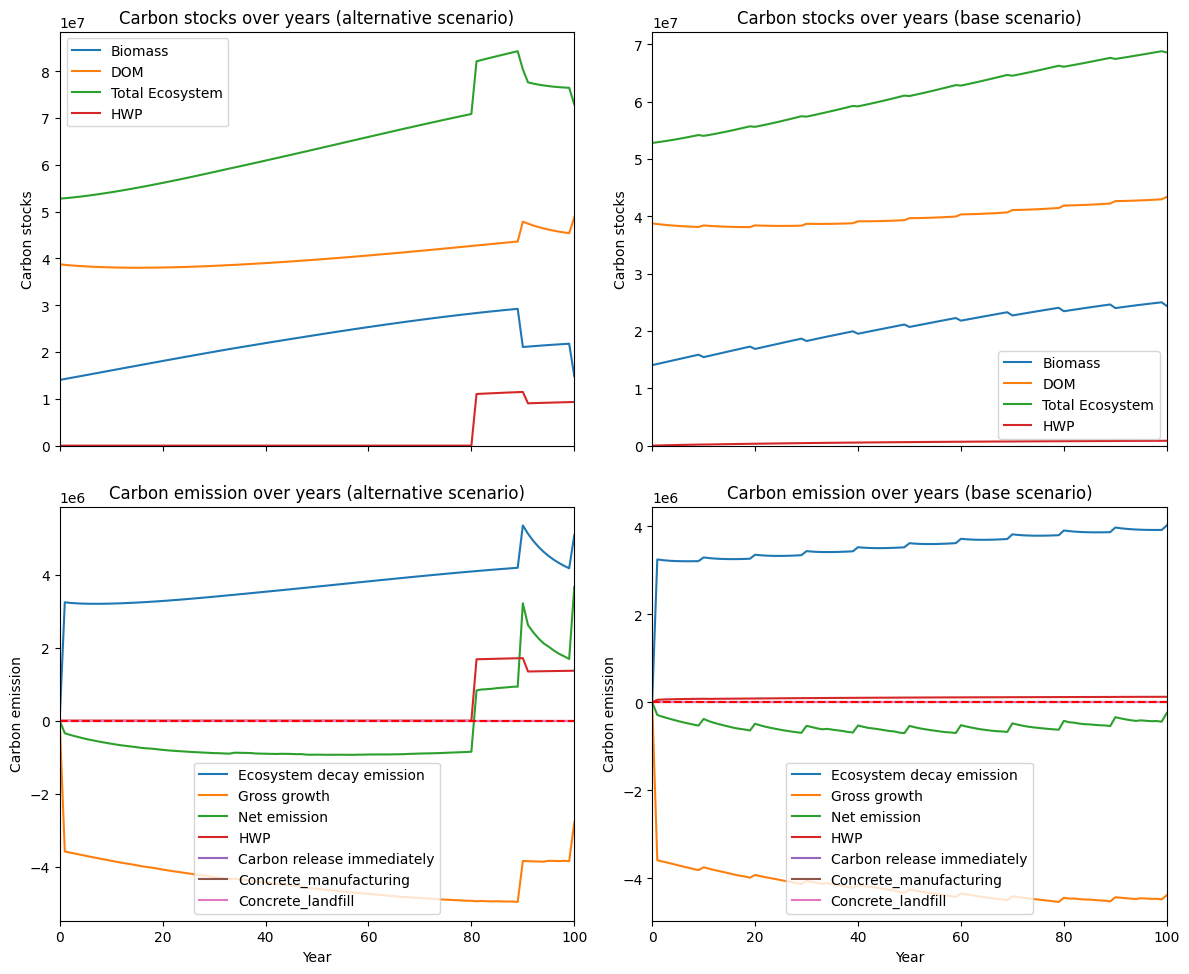

---------------------------------------------------------------------------------------
Net emission difference -3839236.7827047333
Net emission base scenario -15685652.55028563
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  2.6046843594145352
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0  -8440.103034  -8440.103034
Pine    0.0  -7468.112357  -7468.112357
Bal     0.0 -11302.895031 -11302.895031
Spruce  0.0  -4621.823044  -4621.823044

Overall, the old growth area has **decreased** by -31832.93 hectares in the alternative scenario compared to the base scenario.


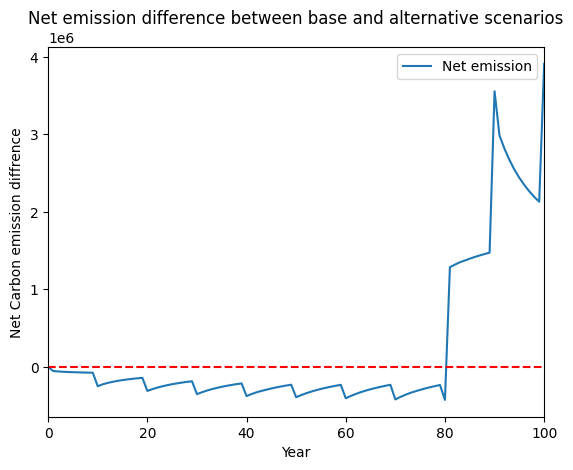

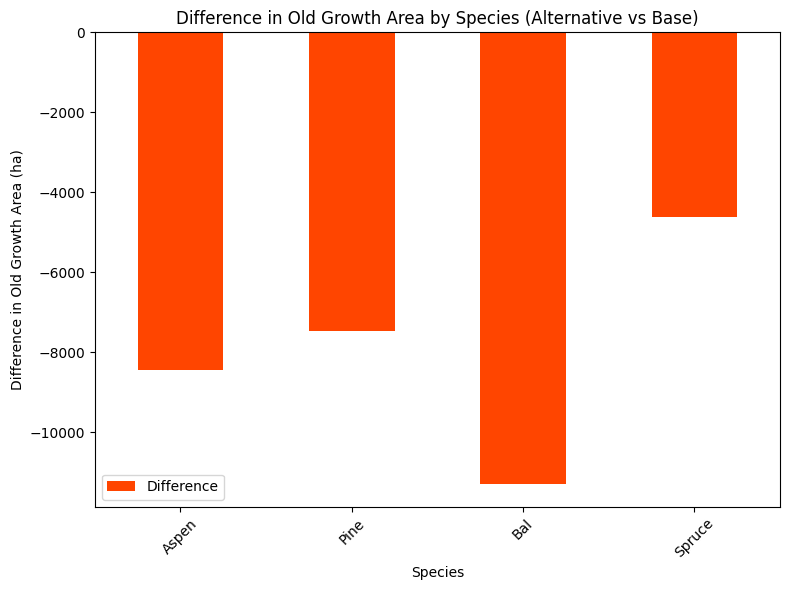

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


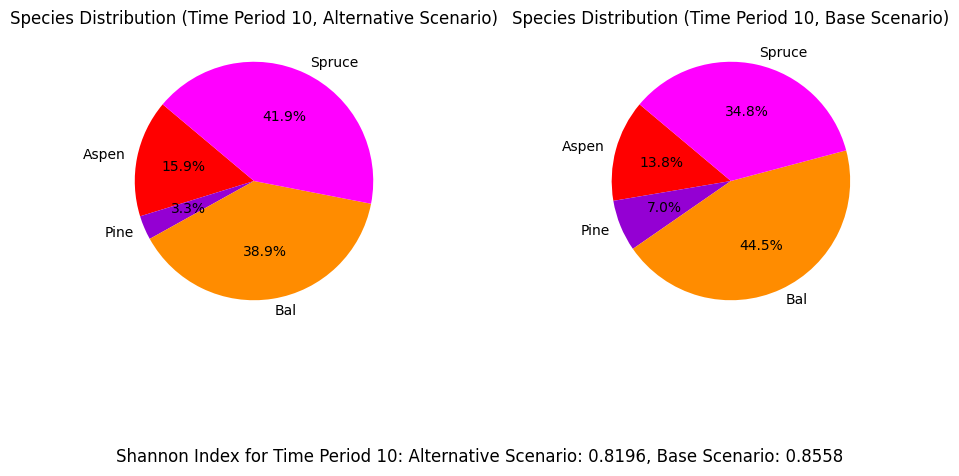

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3707 rows, 34533 columns and 445161 nonzeros
Model fingerprint: 0x1afcb496
Coefficient statistics:
  Matrix range     [1e-02, 1e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 2009 rows and 2005 columns
Presolve time: 0.10s
Presolved: 1698 rows, 32528 columns, 415336 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.

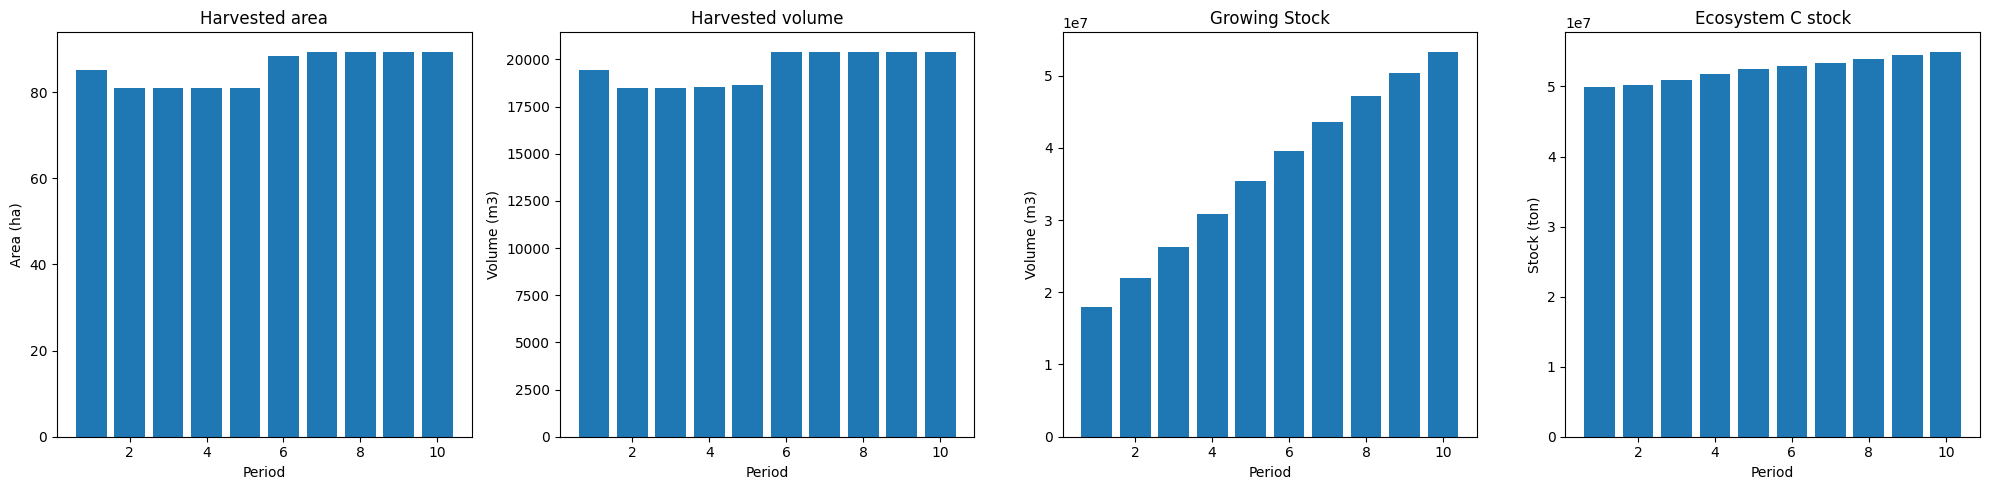

Plot saved to ./outputs/fig/redchris/redchris_max_st_evenflow_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  206
The economic indicator (the provincial government revenues) is:  7054
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


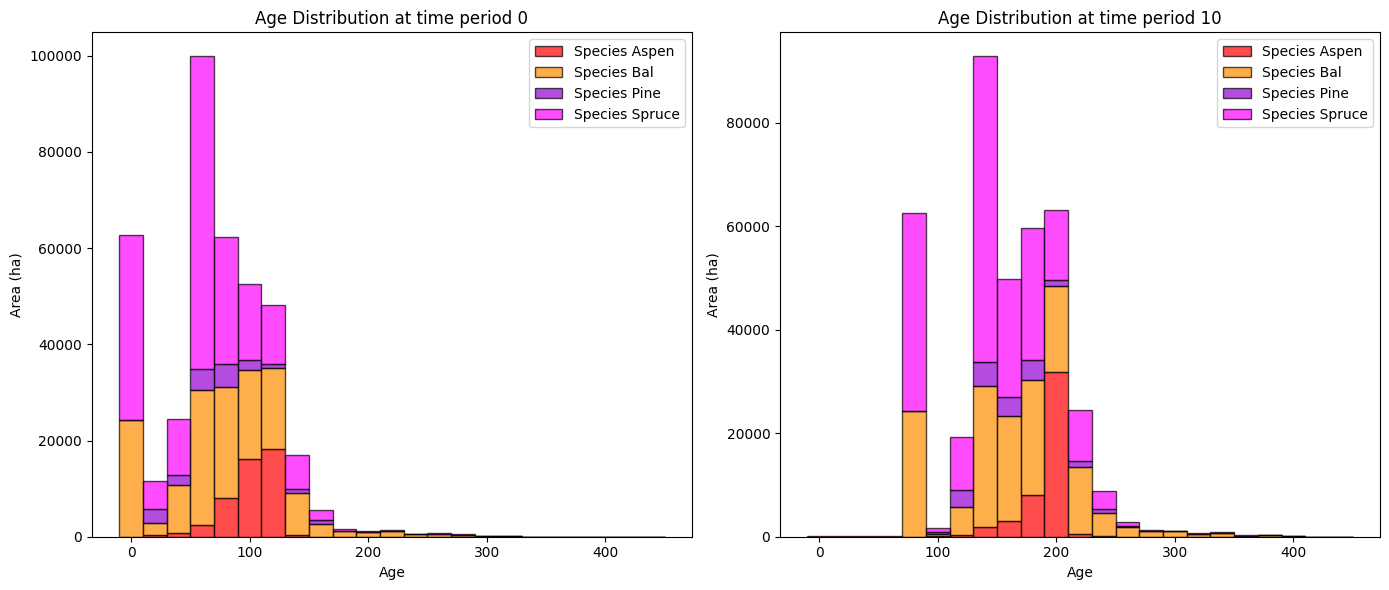

Plot saved to ./outputs/fig/redchris/redchris_max_st_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  44508.623748  43563.310060
Pine     602.782616   9389.986273   8787.203656
Bal     4315.588546  54242.845266  49927.256720
Spruce  1072.814408  41318.874520  40246.060112

Overall diversity has **increased** by 142523.83 hectares from time period 0 to time period 10.


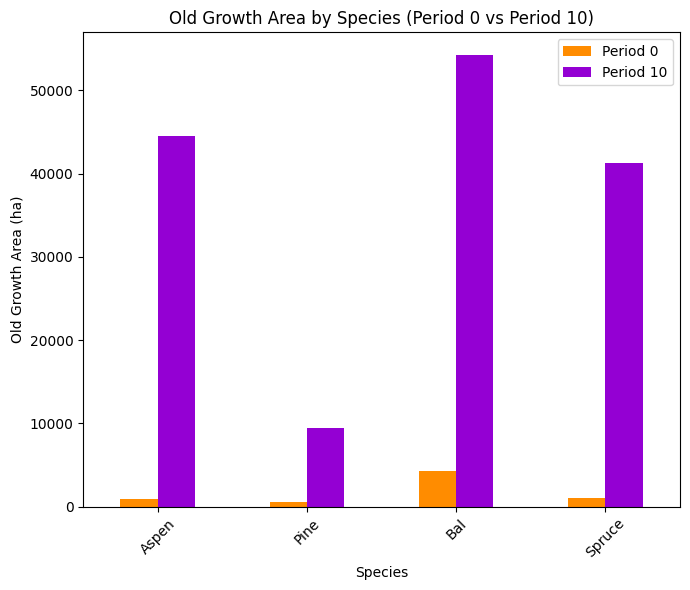

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8129

Diversity has **decreased** by 7.20% from time 0 to time 10.


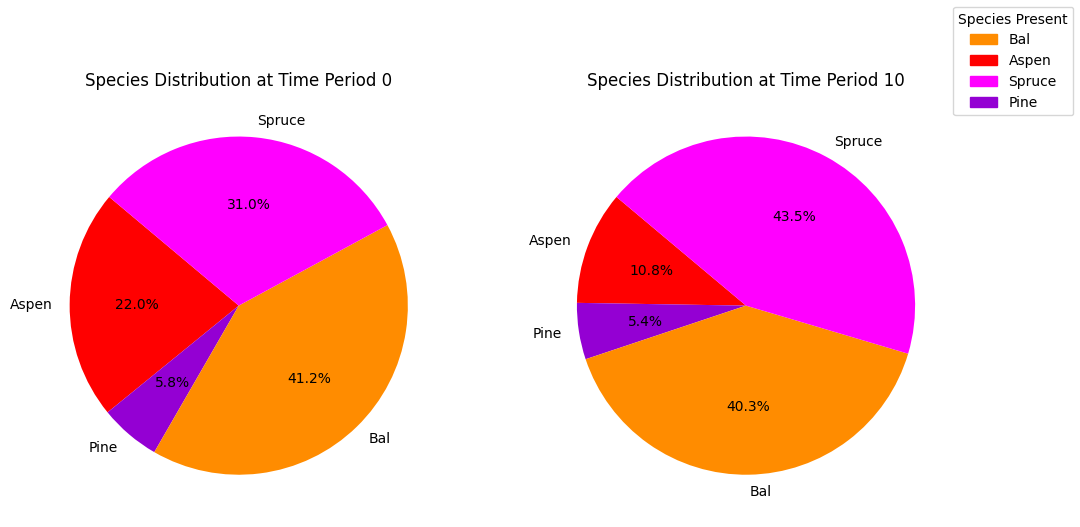

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_evenflow_cons_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.19s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0

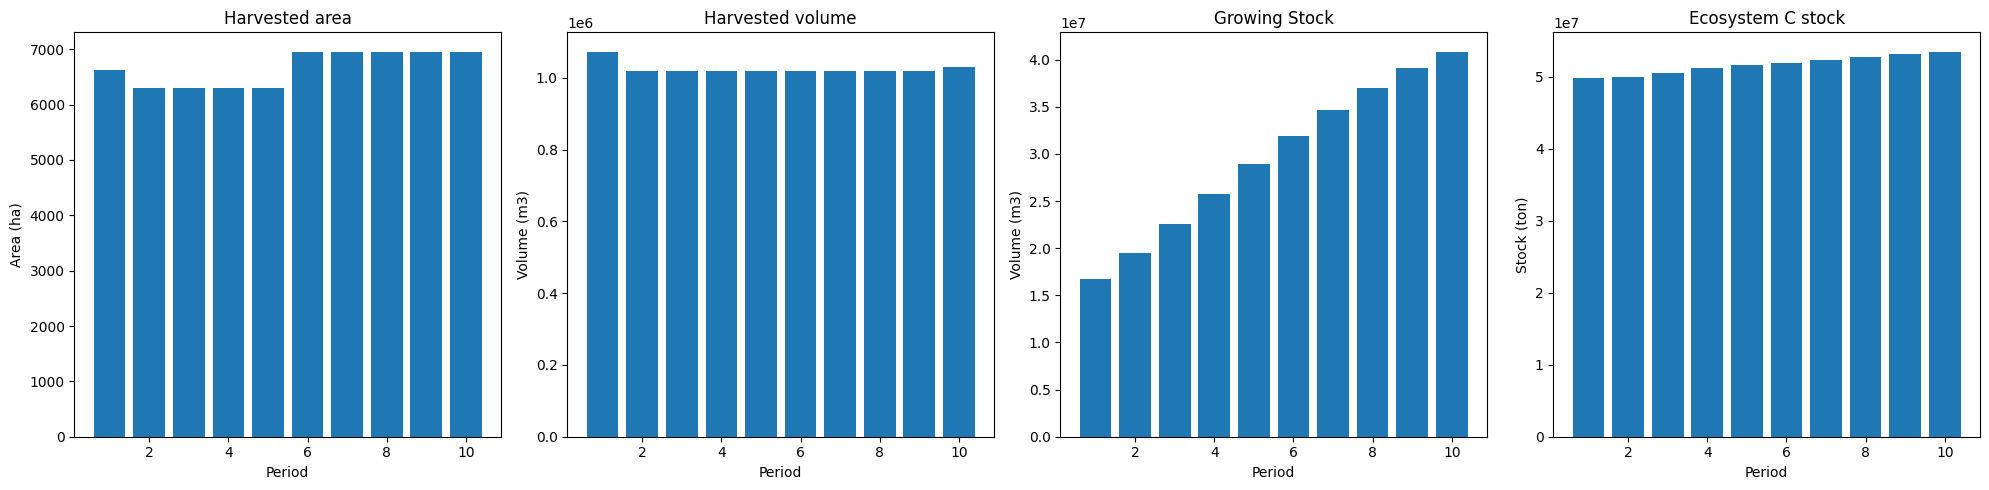

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


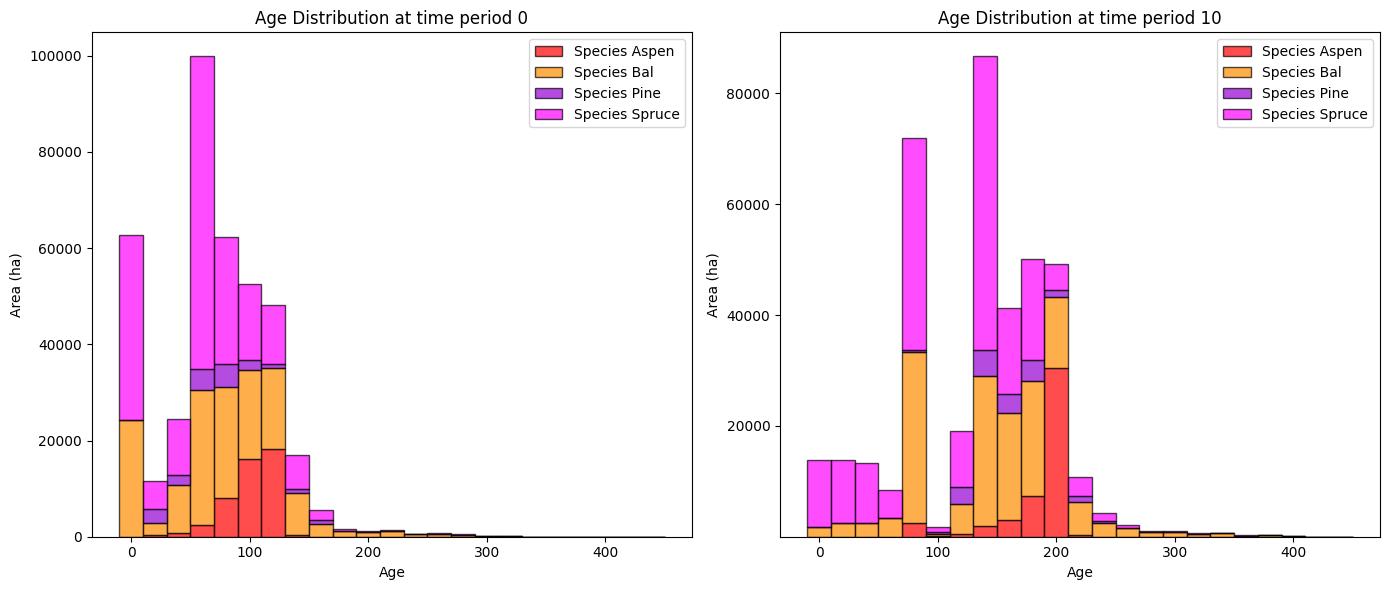

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


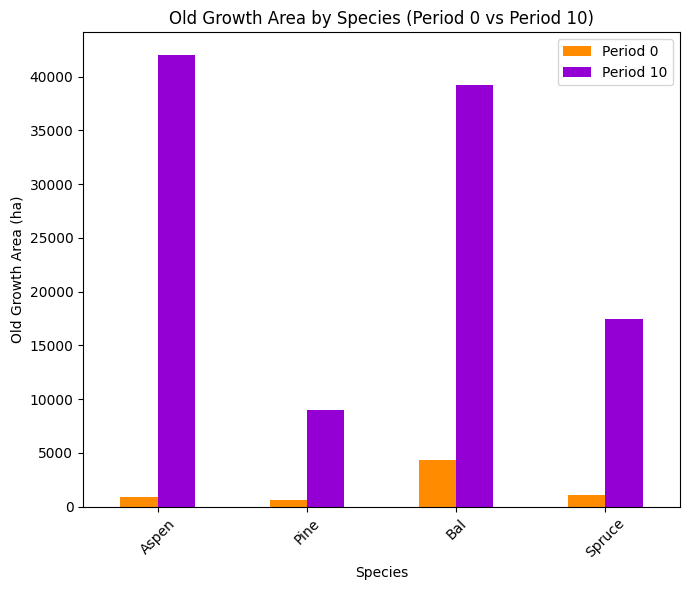

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


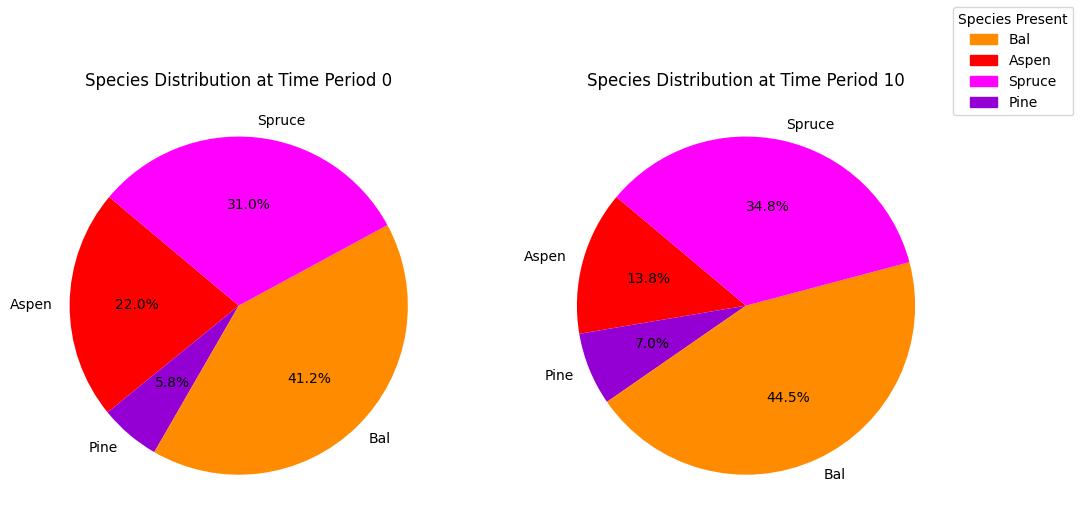

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


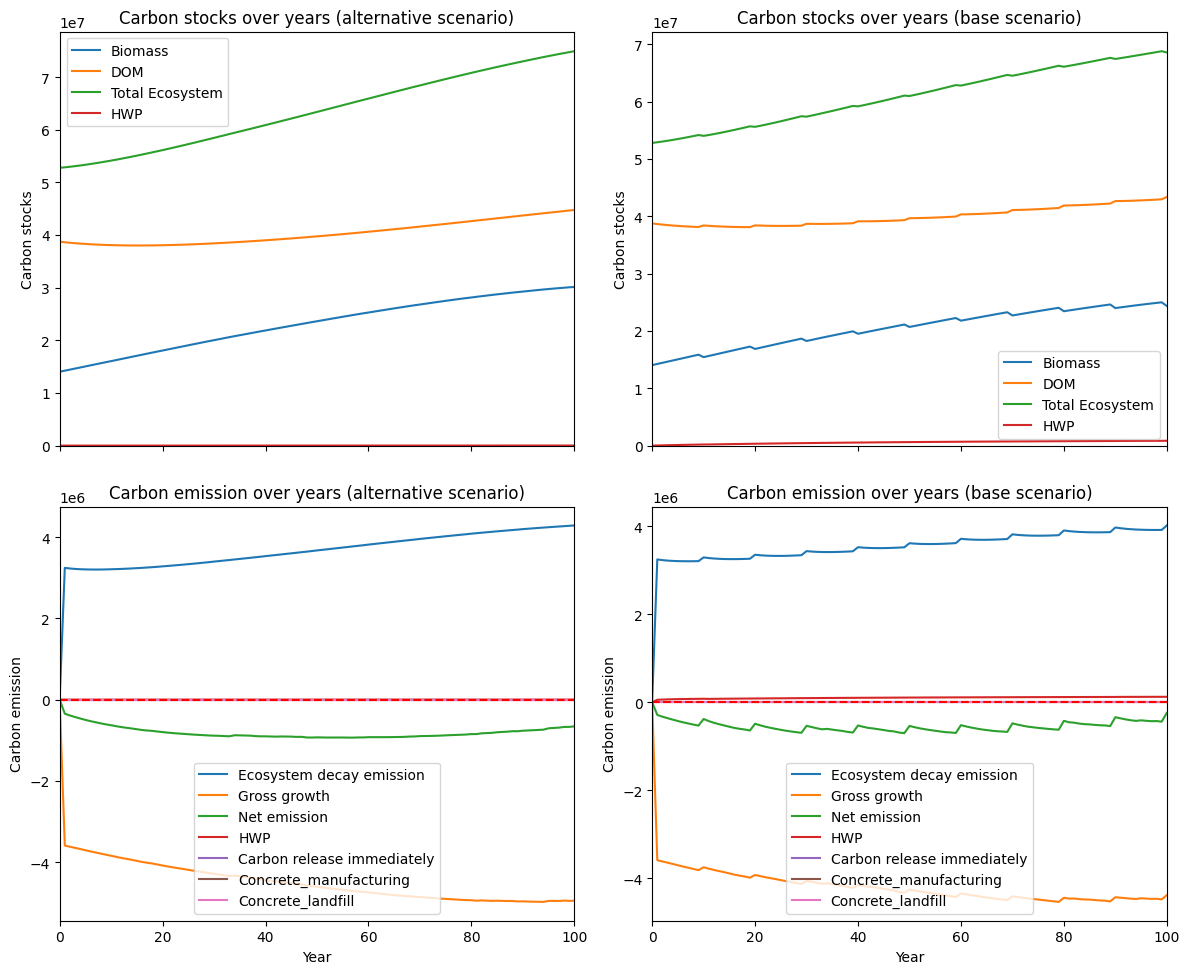

---------------------------------------------------------------------------------------
Net emission difference -3775569.3342915215
Net emission base scenario -15621985.101872418
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  2.6486071674476297
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   2497.986024   2497.986024
Pine    0.0    416.505573    416.505573
Bal     0.0  14988.731670  14988.731670
Spruce  0.0  23818.416110  23818.416110

Overall, the old growth area has **increased** by 41721.64 hectares in the alternative scenario compared to the base scenario.


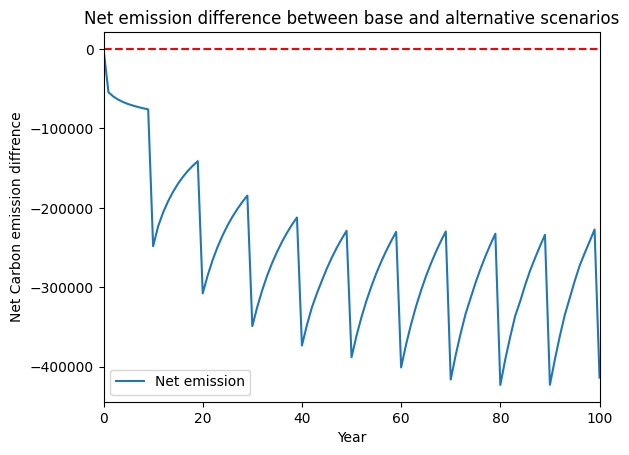

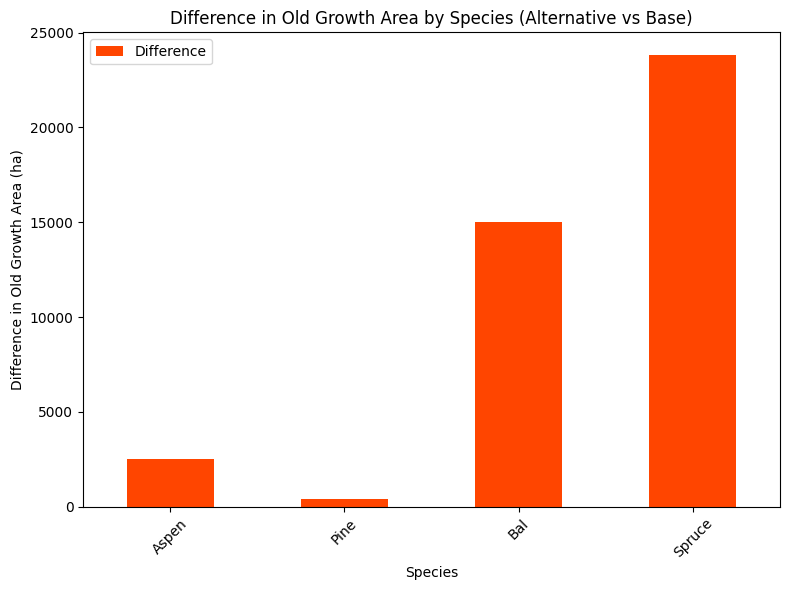

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


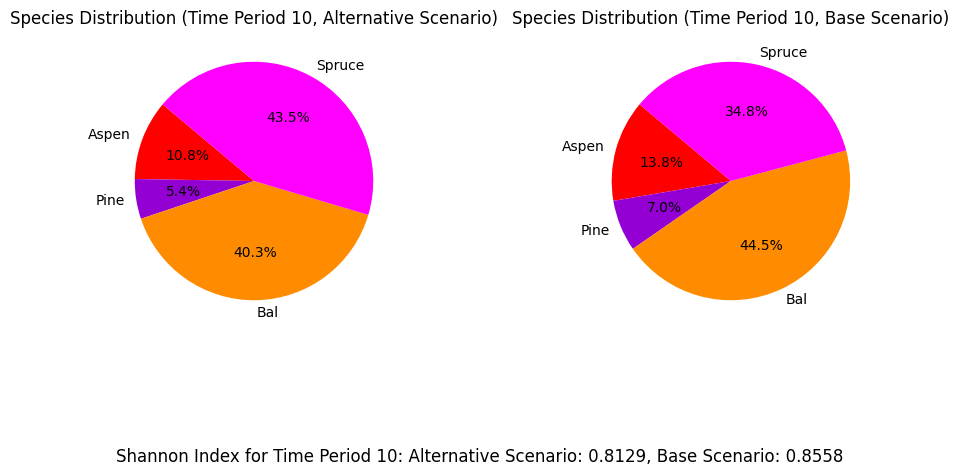

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_bau_redchrs...
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32528 column

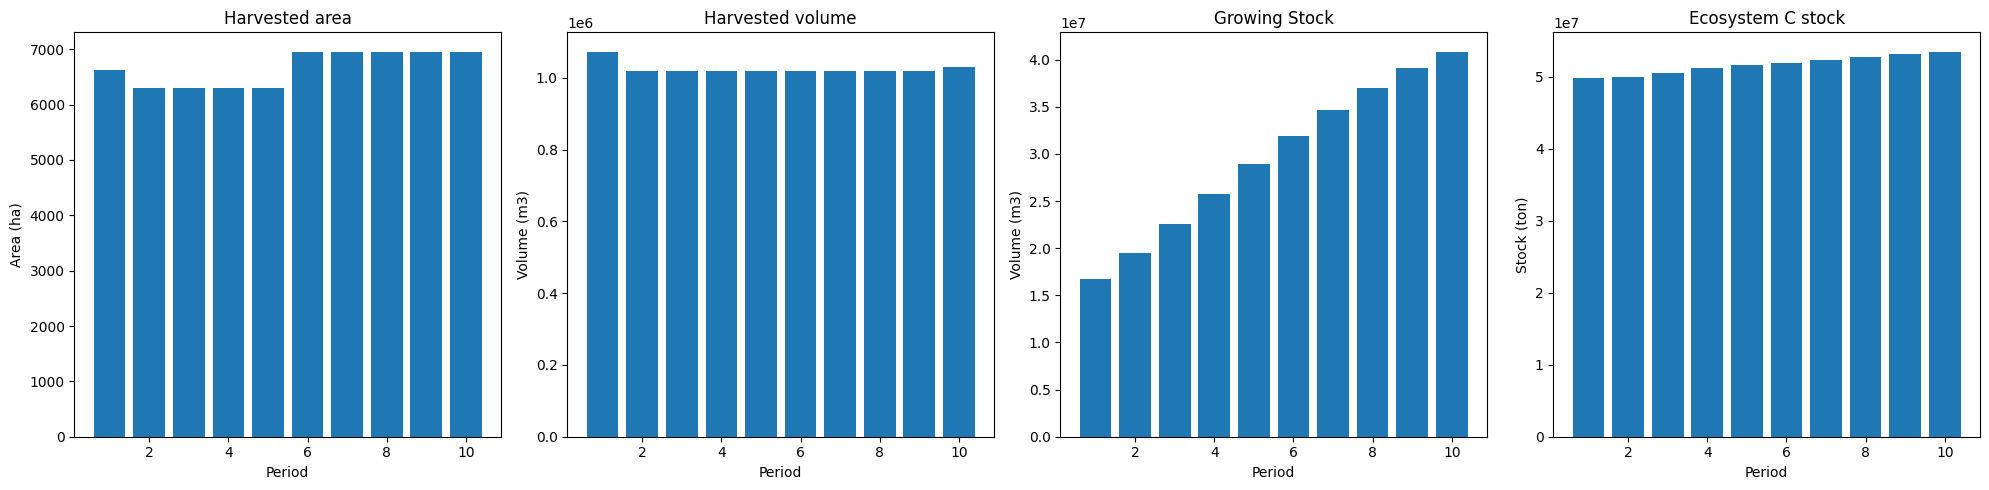

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


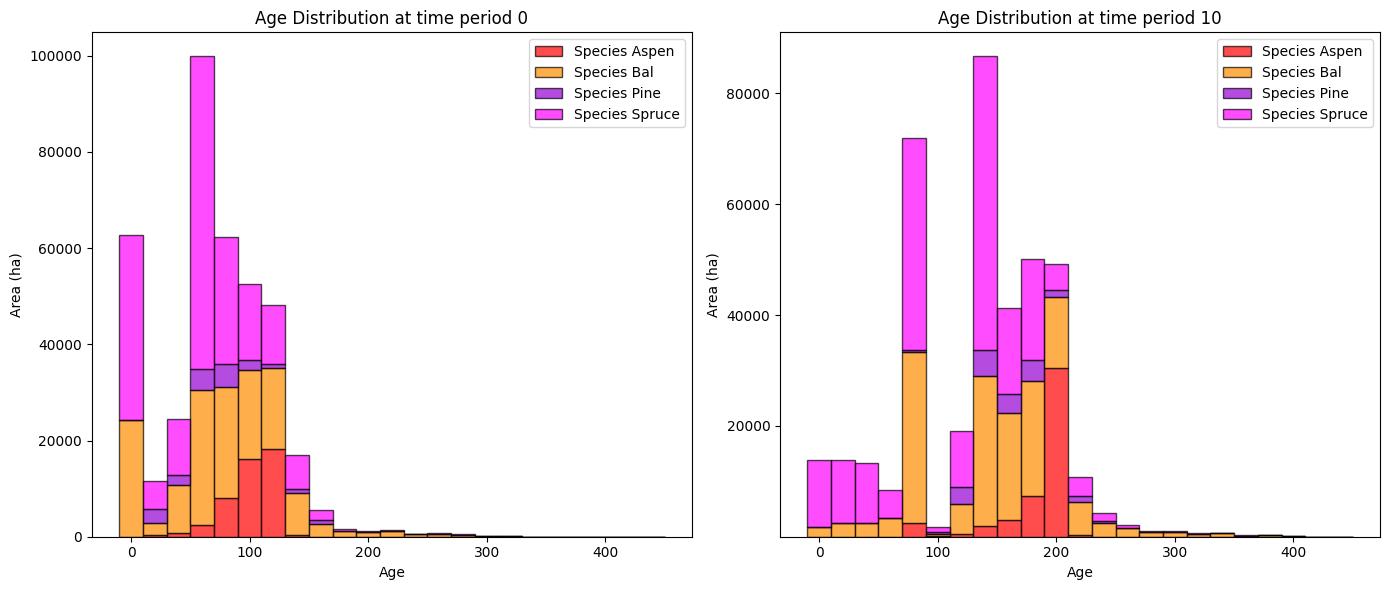

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


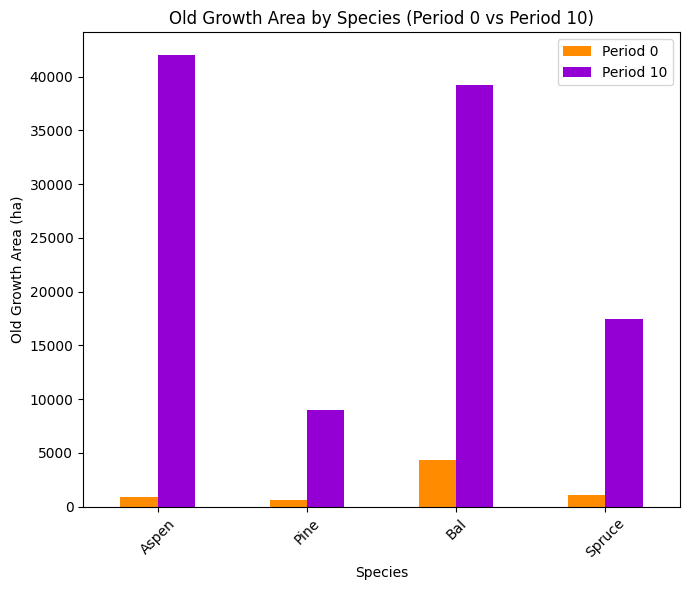

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


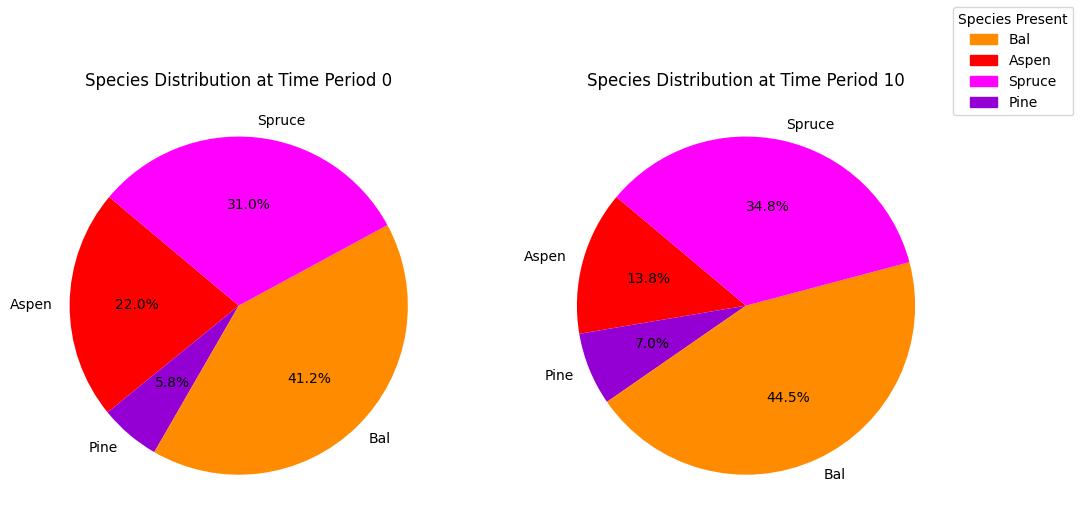

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.12s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.0

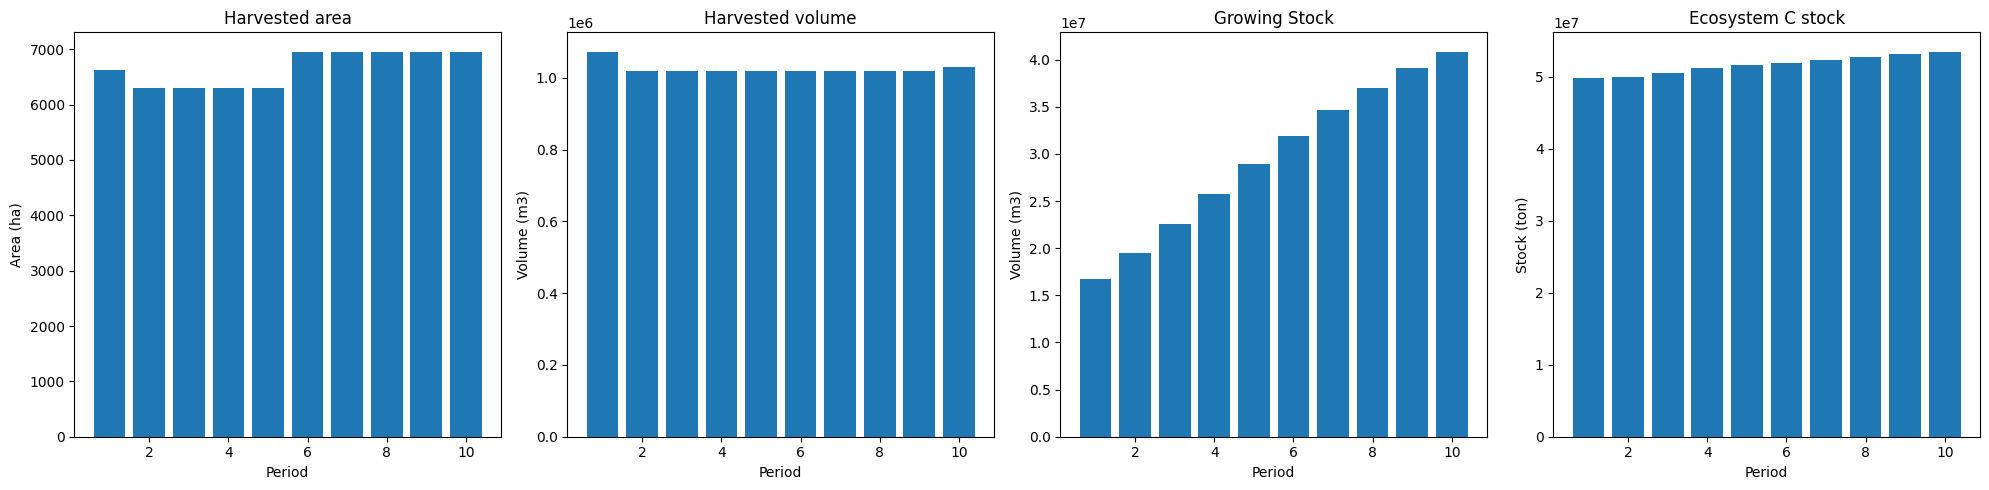

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


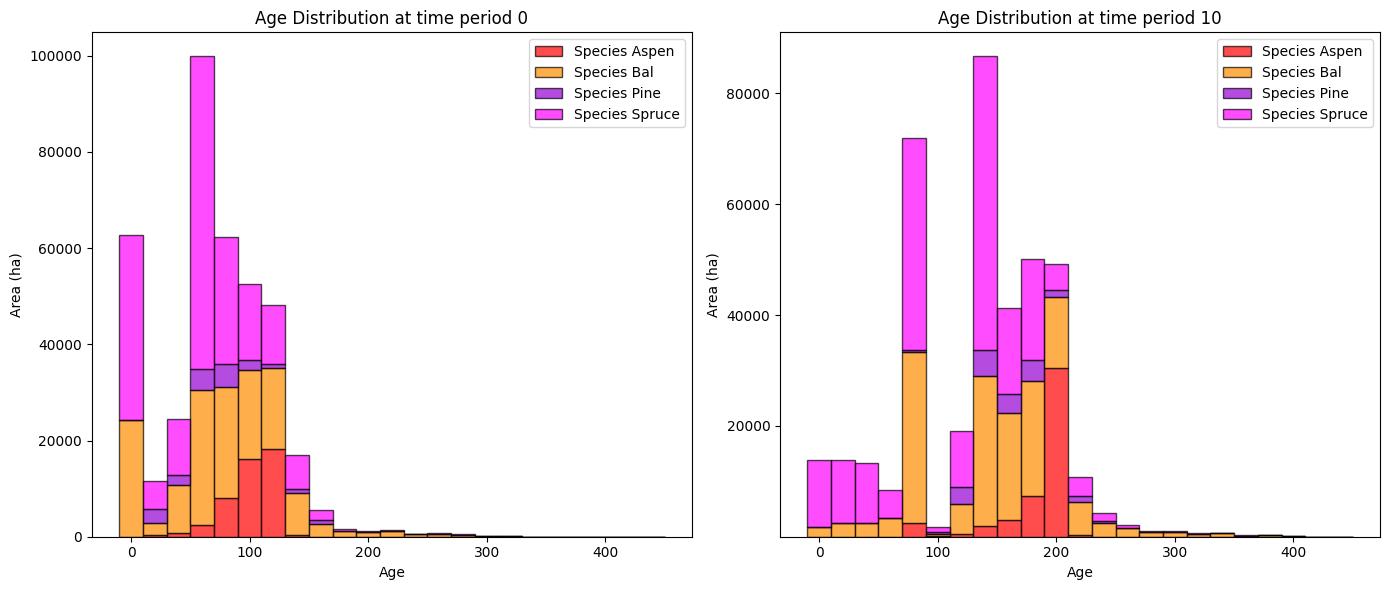

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


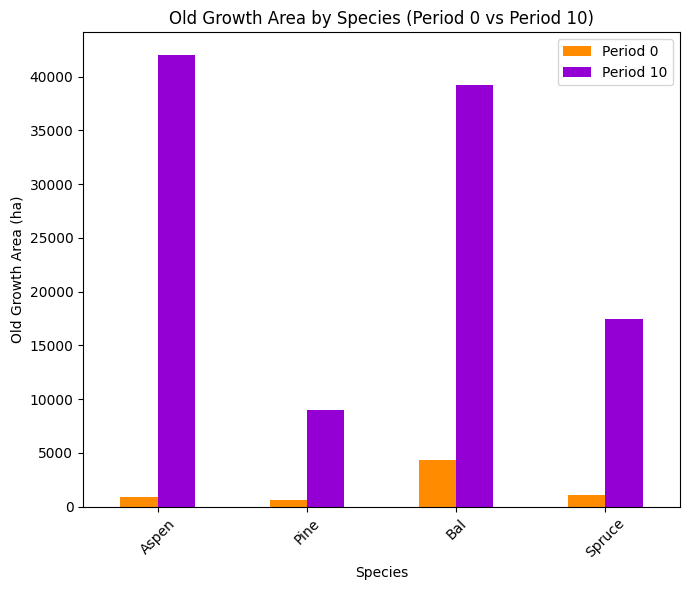

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


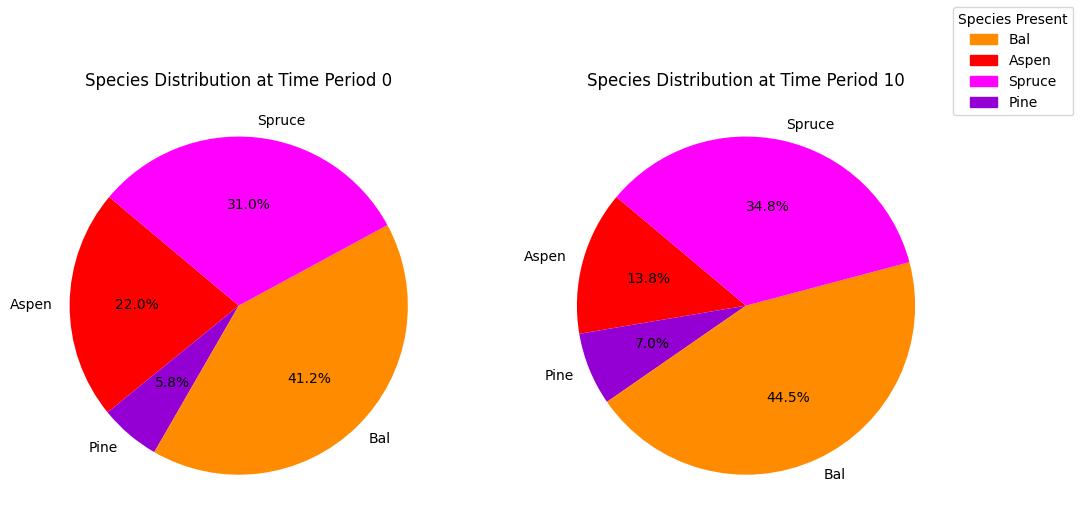

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


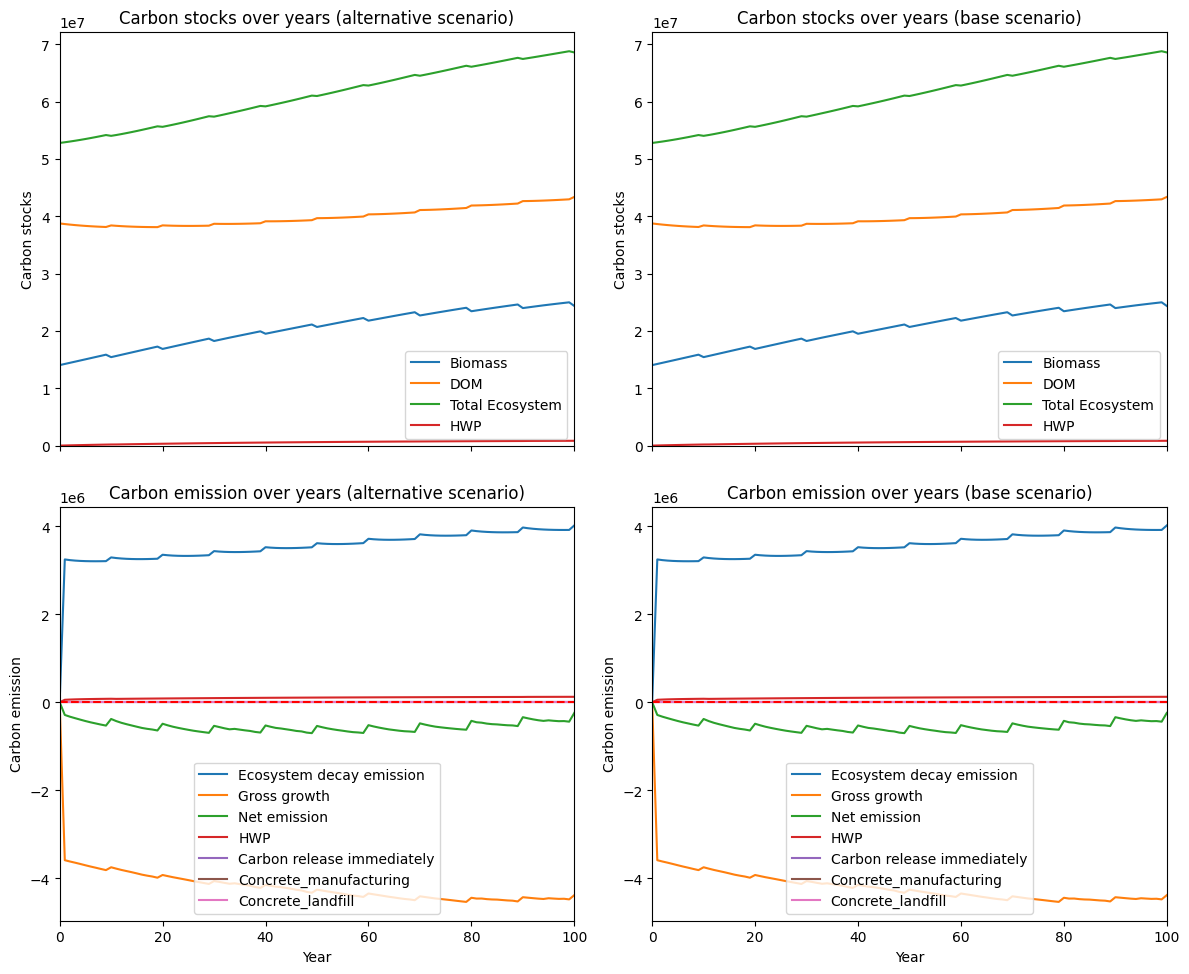

---------------------------------------------------------------------------------------
Net emission difference 0.0
Net emission base scenario -11846415.767580897
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  inf
Comparison of Old Growth Areas (Alternative - Base)
          0   10  Difference
Aspen   0.0  0.0         0.0
Pine    0.0  0.0         0.0
Bal     0.0  0.0         0.0
Spruce  0.0  0.0         0.0

Overall, the old growth area has **increased** by 0.00 hectares in the alternative scenario compared to the base scenario.


/media/data/project/eghasemi/nbds_mining/util_opt.py:1211: RuntimeWarning: divide by zero encountered in scalar divide
  dollar_per_ton = abs(budget_input / dif_scenario.iloc[:25]['Net emission'].sum())


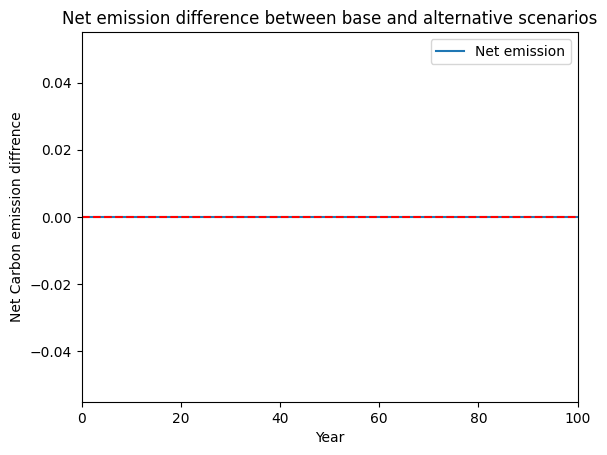

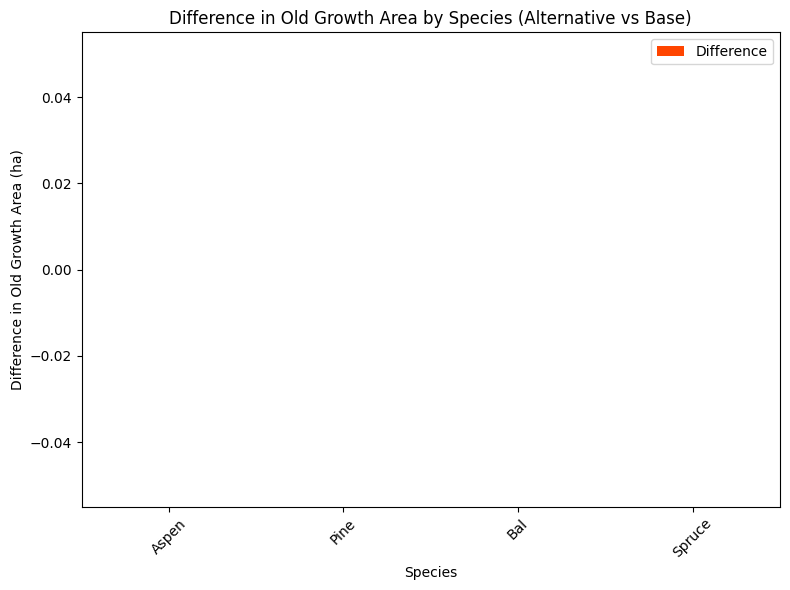

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


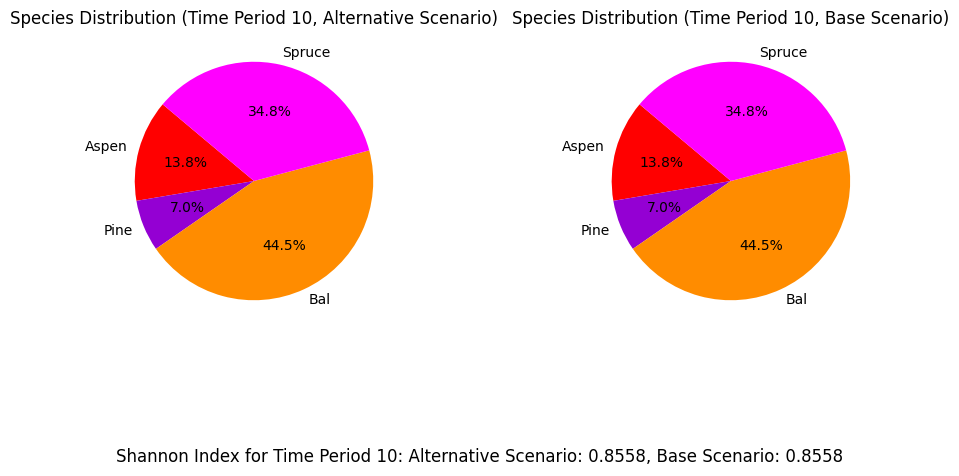

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_90%...
running the scenario for the Red Chris mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8bda468f
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32529 column

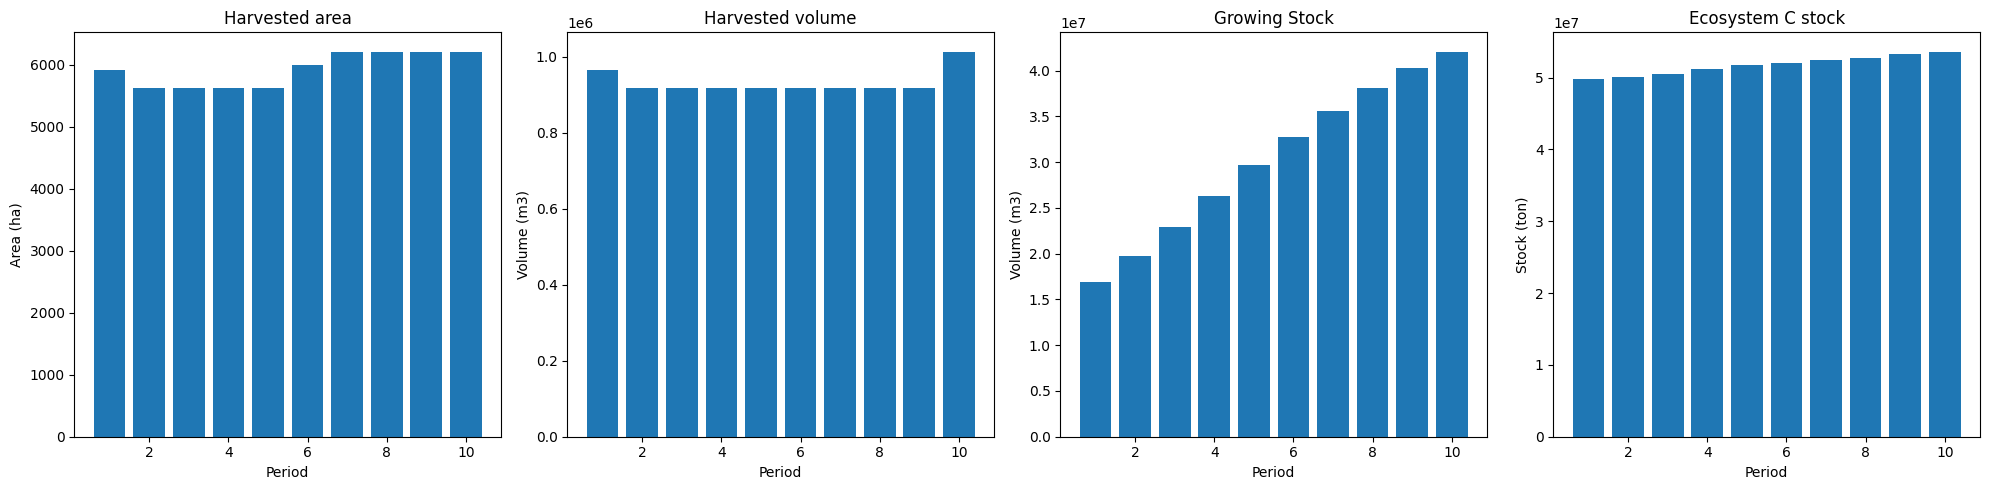

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_90%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  9850
The economic indicator (the provincial government revenues) is:  335935
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


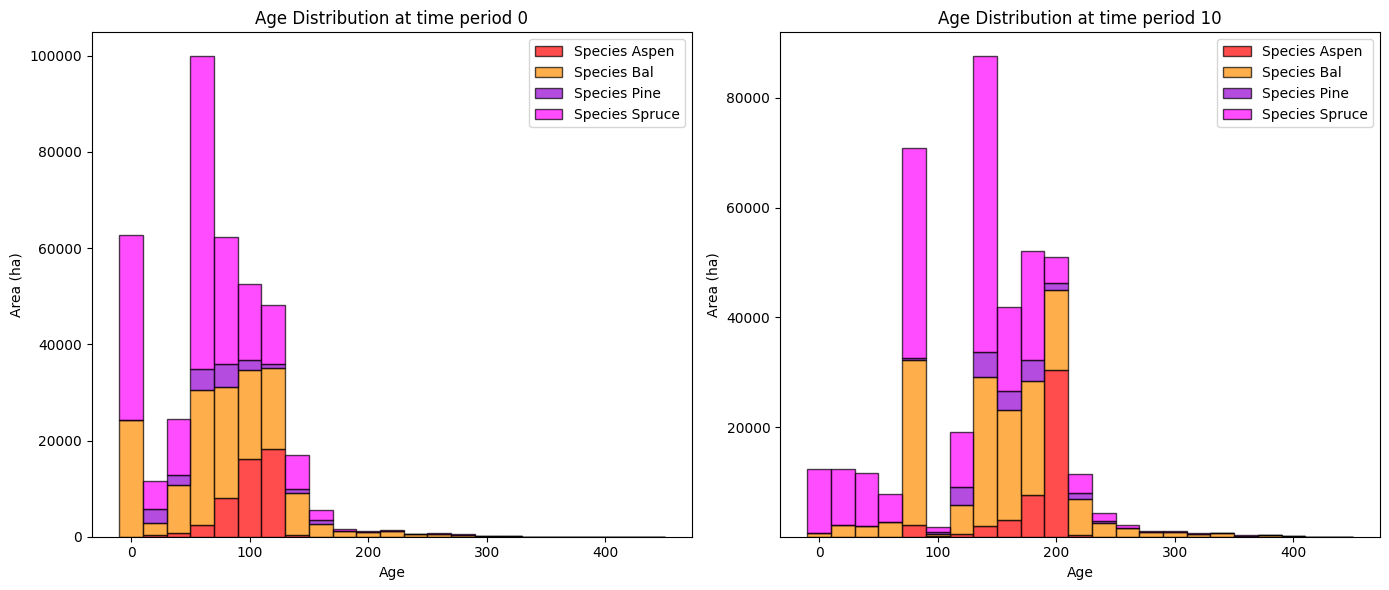

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42331.631807  41386.318120
Pine     602.782616   9036.790465   8434.007849
Bal     4315.588546  41835.748808  37520.160262
Spruce  1072.814408  18528.695437  17455.881029

Overall diversity has **increased** by 104796.37 hectares from time period 0 to time period 10.


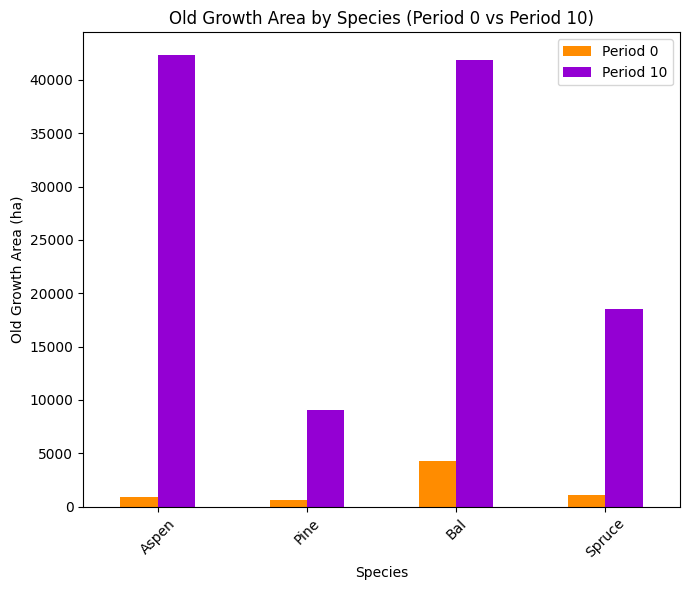

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8508

Diversity has **decreased** by 3.40% from time 0 to time 10.


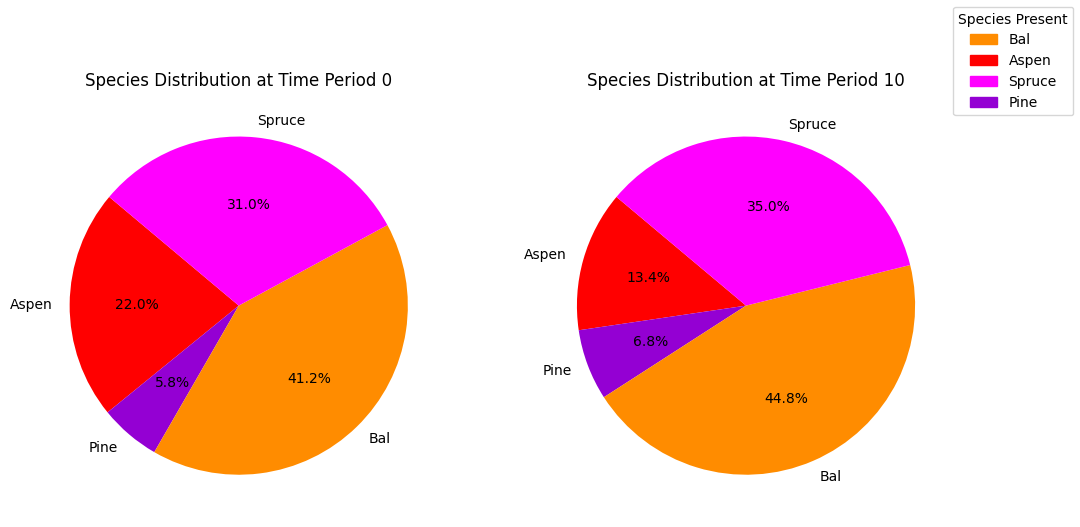

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_90%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.18s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

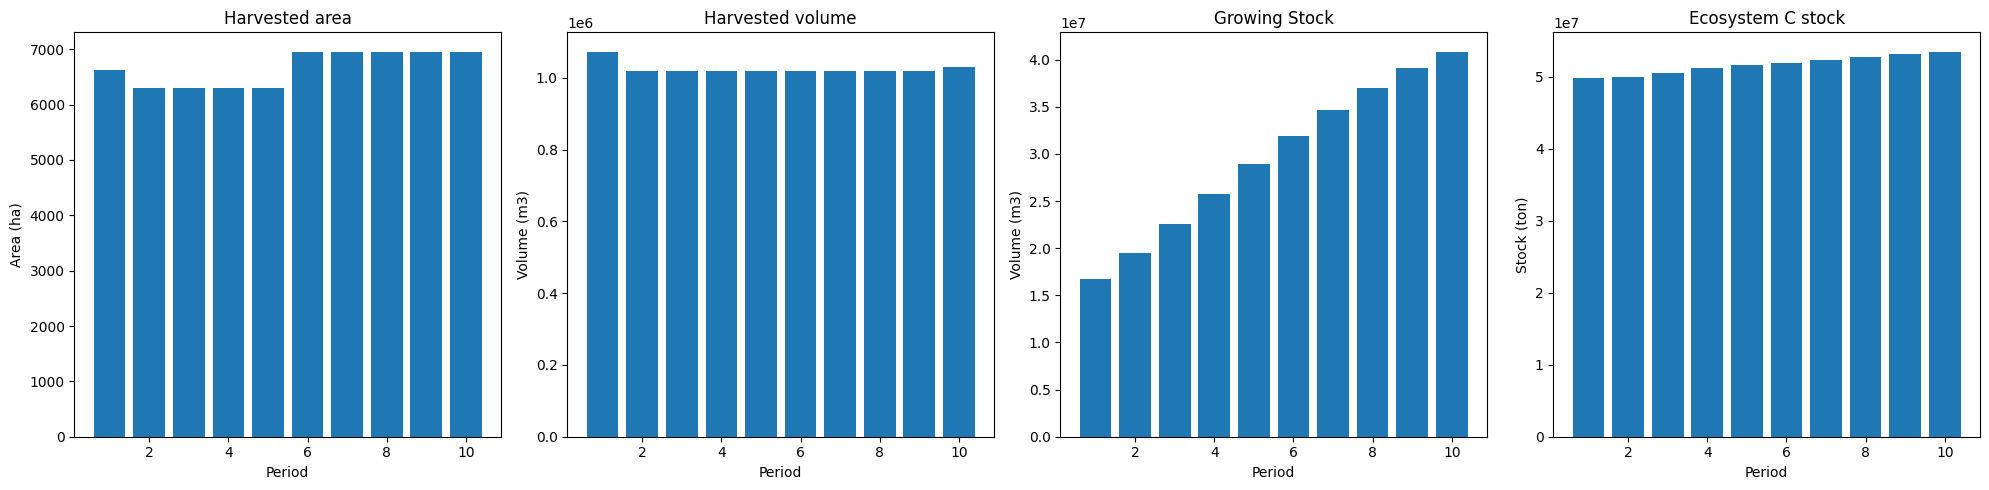

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


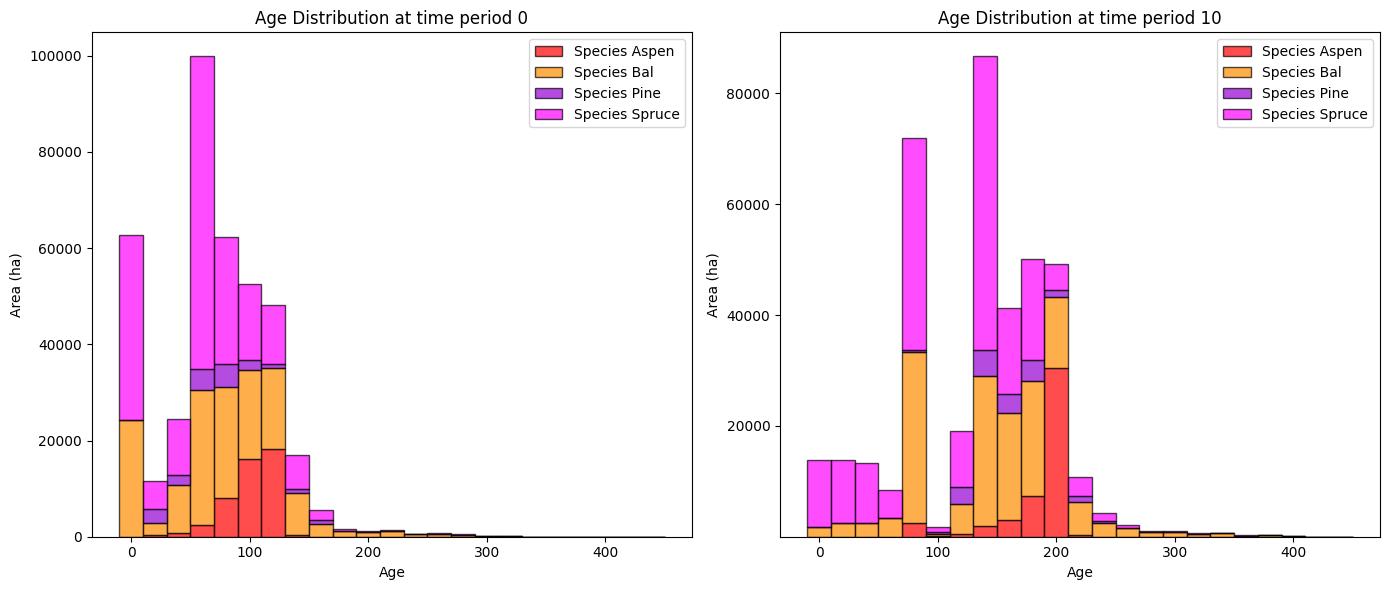

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


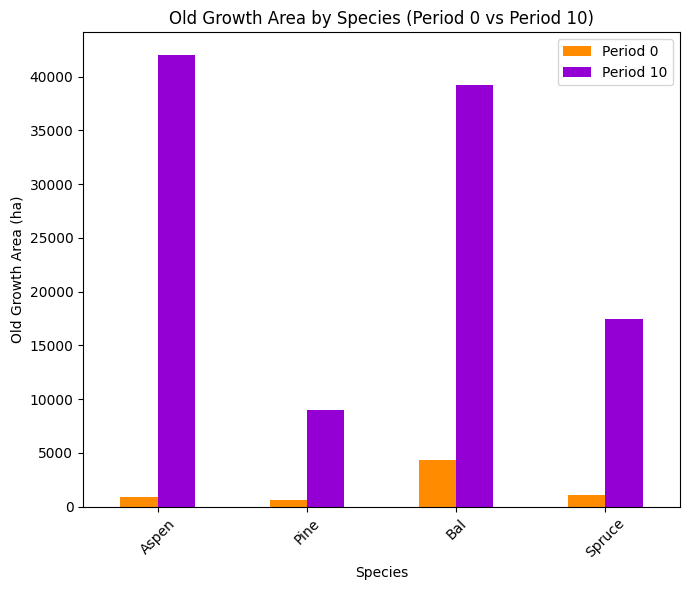

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


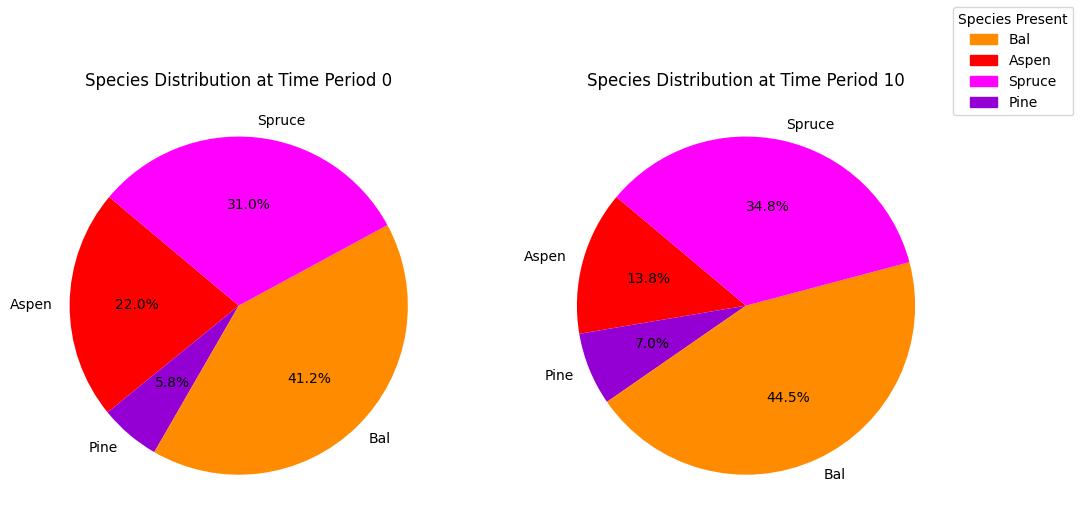

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


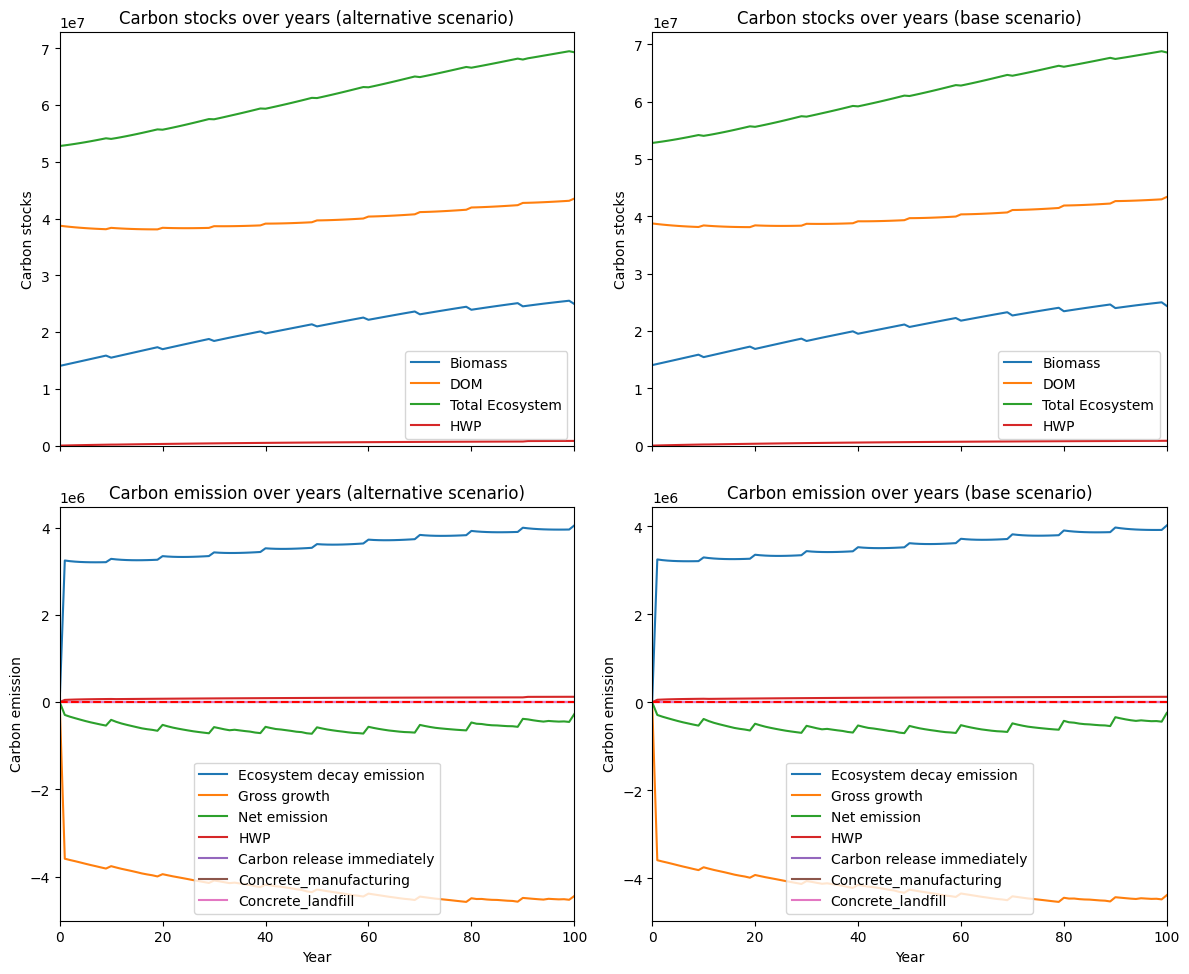

---------------------------------------------------------------------------------------
Net emission difference -406761.24325181096
Net emission base scenario -12253177.010832706
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  24.584446443461594
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0   320.994083   320.994083
Pine    0.0    63.309765    63.309765
Bal     0.0  2581.635213  2581.635213
Spruce  0.0  1028.237027  1028.237027

Overall, the old growth area has **increased** by 3994.18 hectares in the alternative scenario compared to the base scenario.


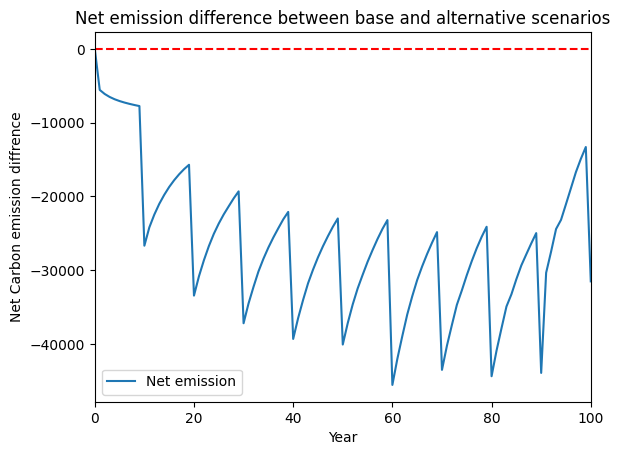

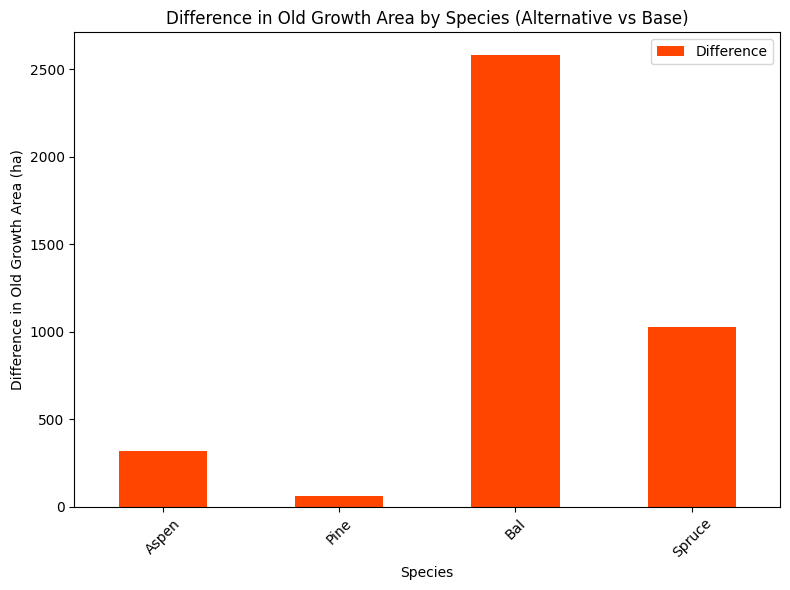

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


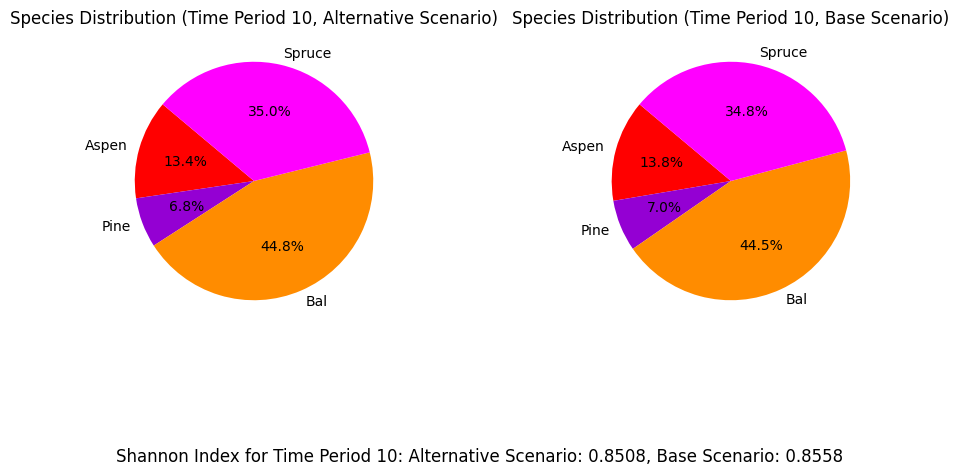

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_80%...
running the scenario for the Red Chris mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x730933d3
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.18s
Presolved: 1699 rows, 32529 column

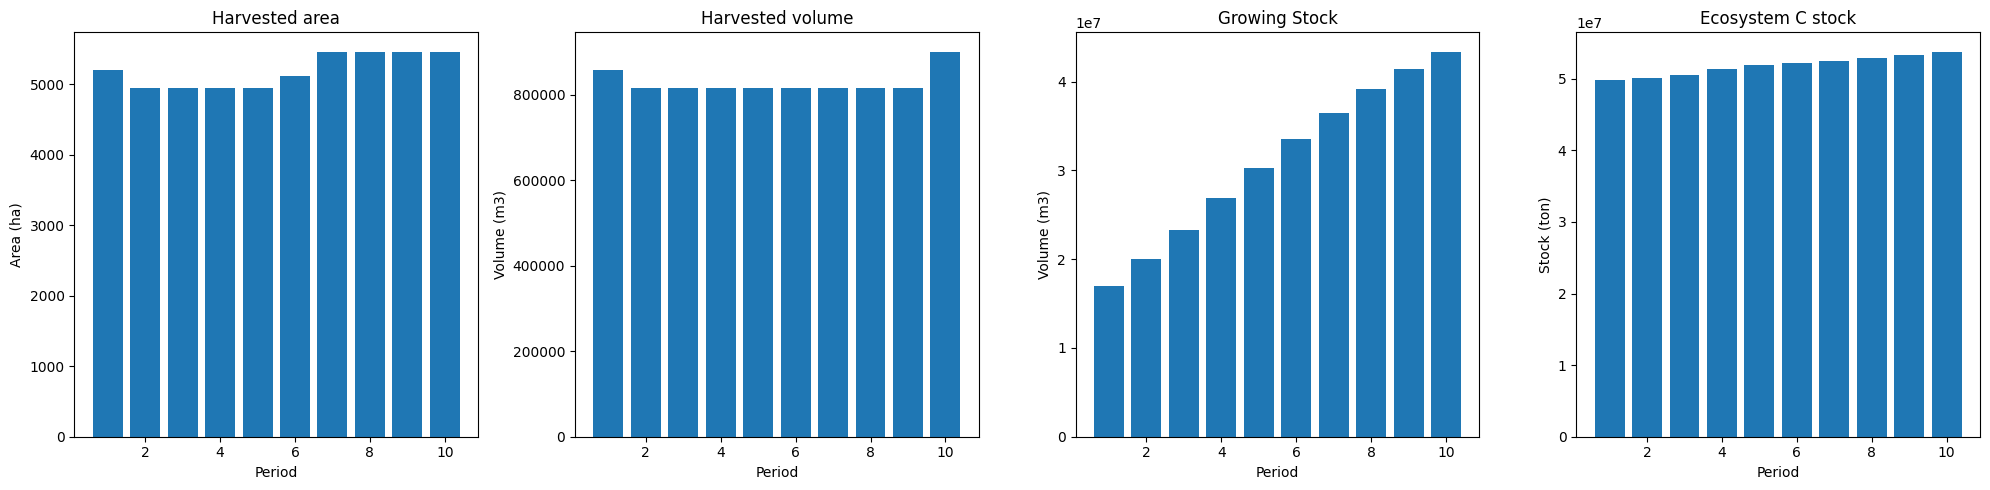

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_80%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  8756
The economic indicator (the provincial government revenues) is:  298609
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


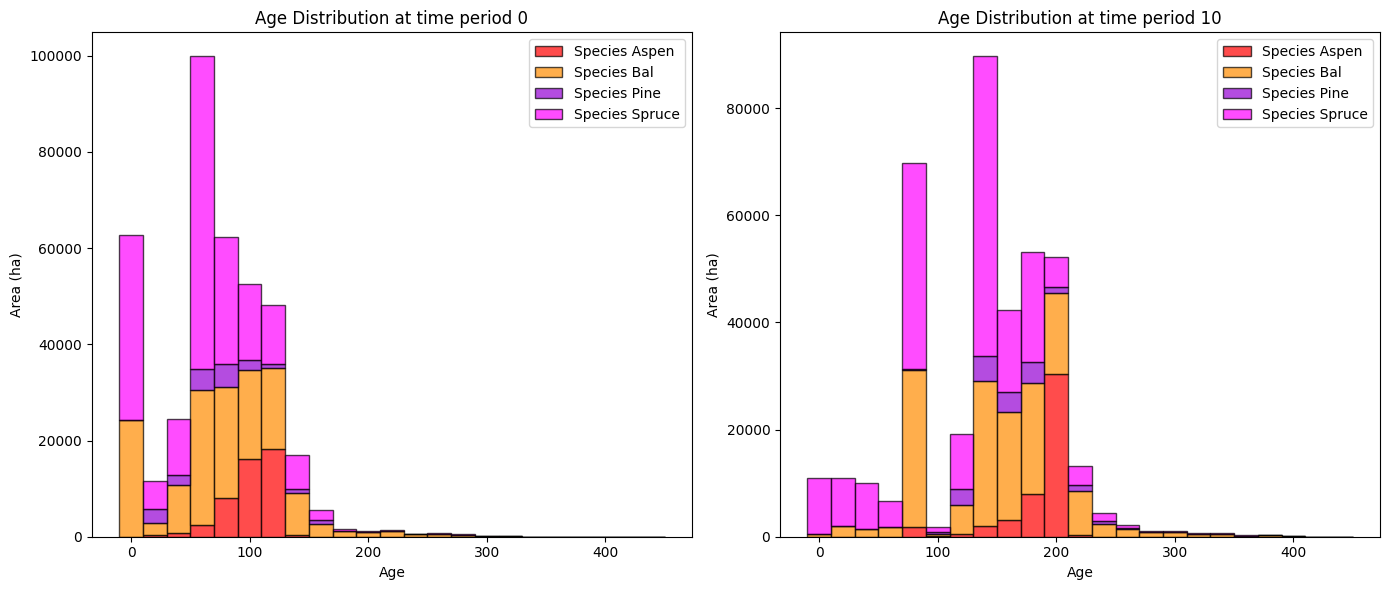

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42609.751247  41664.437559
Pine     602.782616   9164.252418   8561.469801
Bal     4315.588546  44232.882779  39917.294233
Spruce  1072.814408  19470.691145  18397.876737

Overall diversity has **increased** by 108541.08 hectares from time period 0 to time period 10.


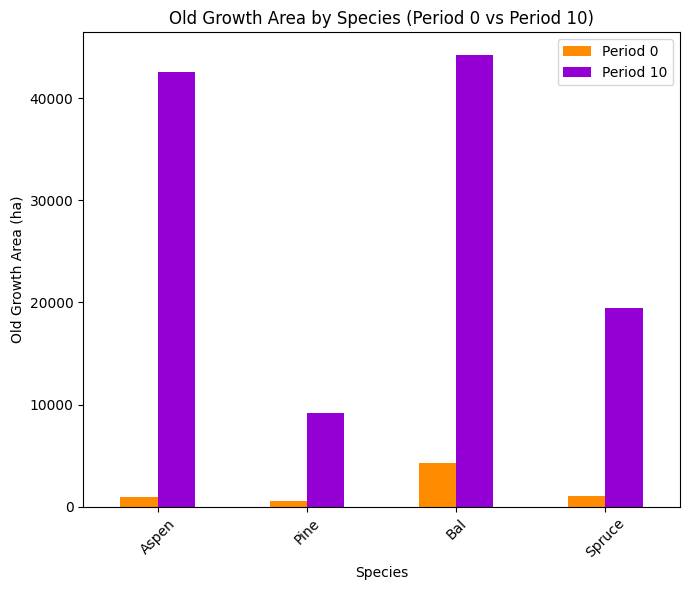

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8463

Diversity has **decreased** by 3.85% from time 0 to time 10.


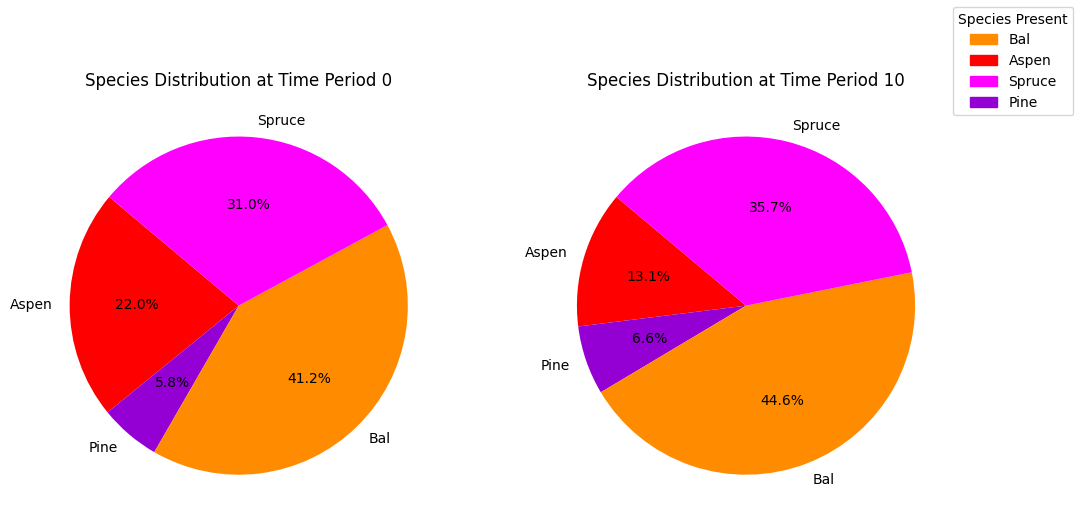

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_80%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

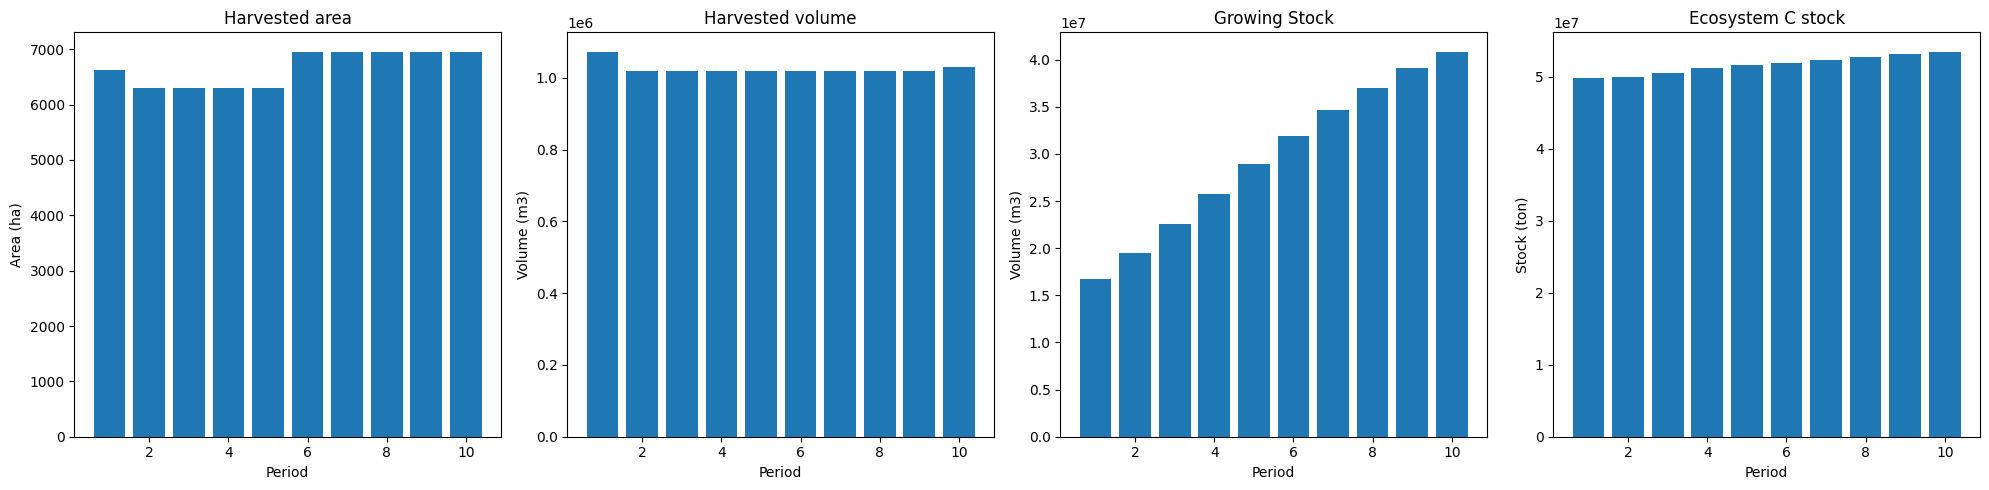

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


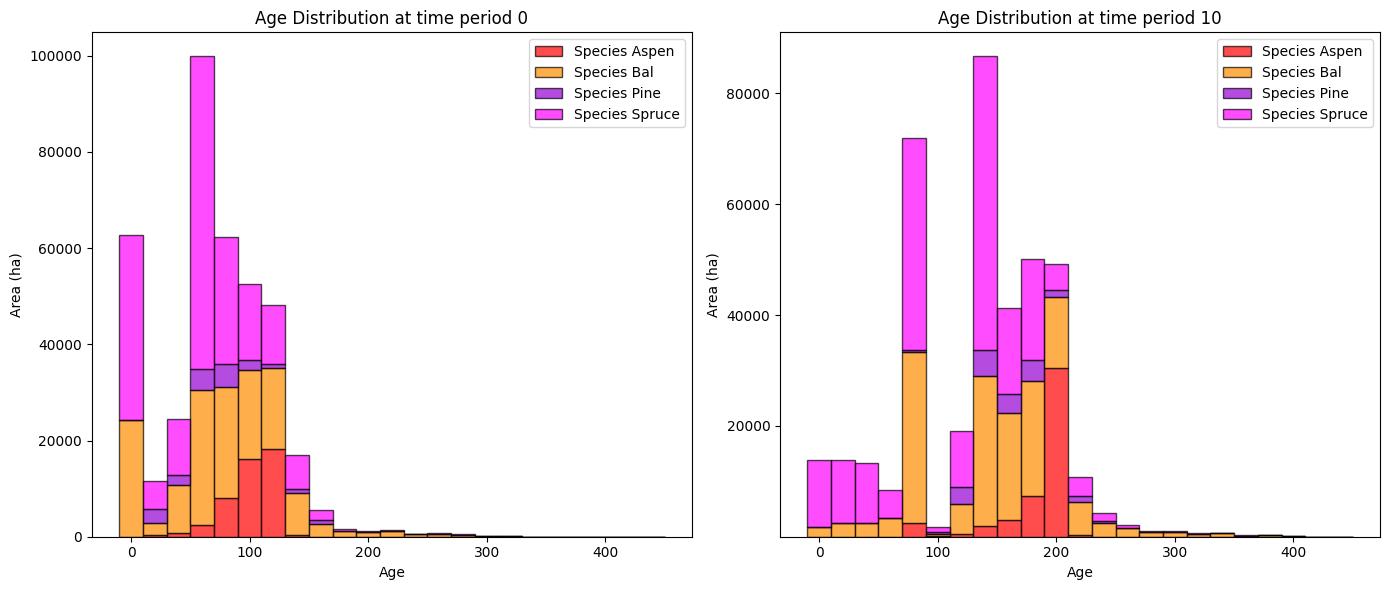

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


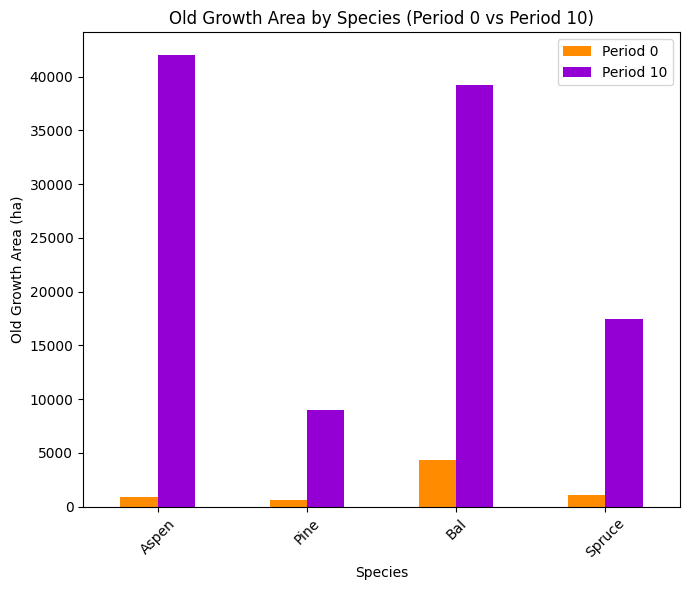

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


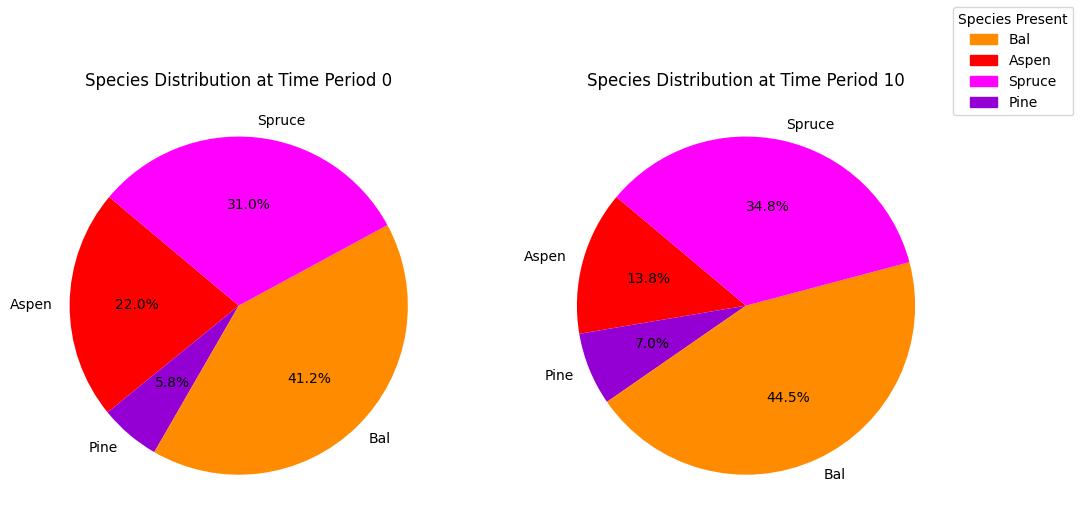

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


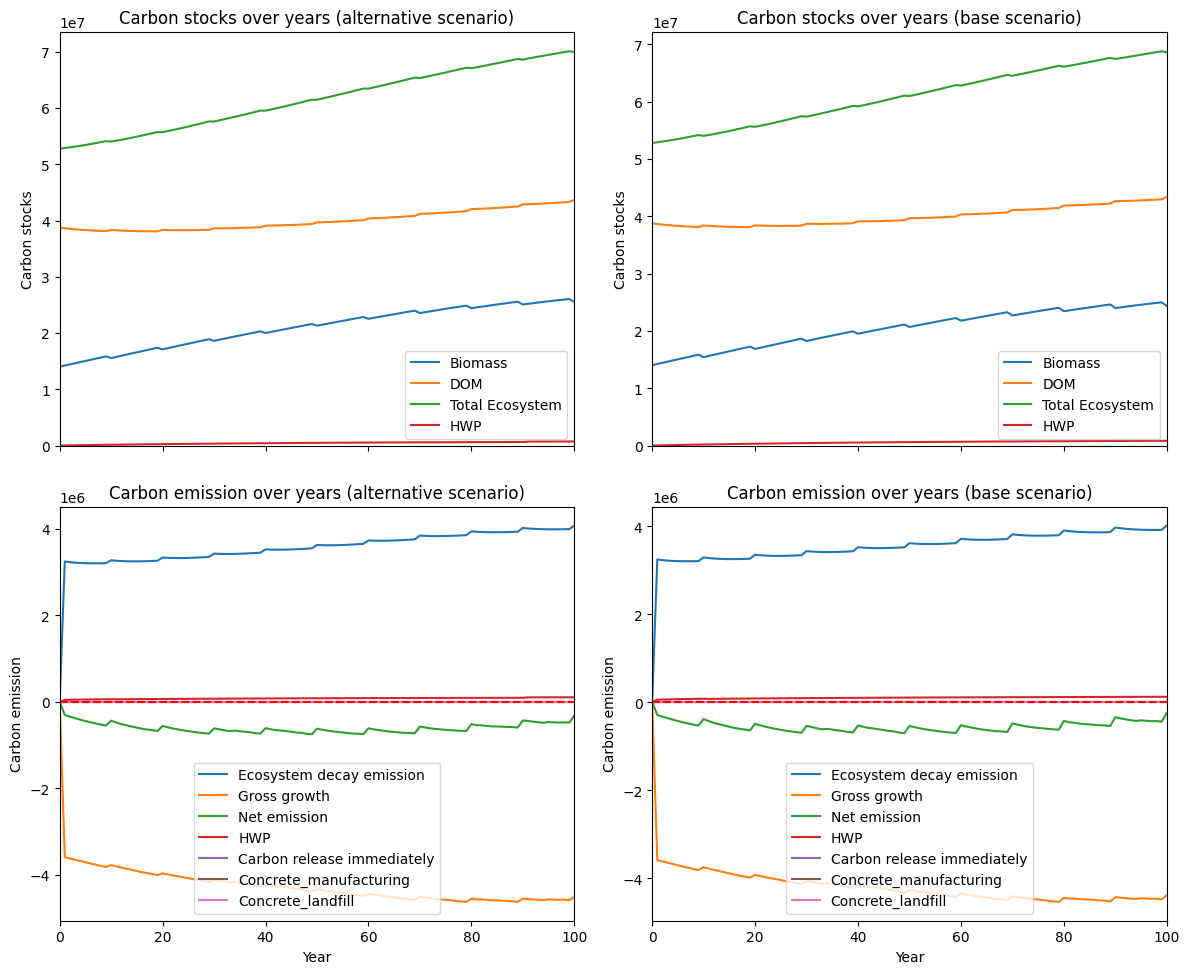

---------------------------------------------------------------------------------------
Net emission difference -808049.6690911816
Net emission base scenario -12654465.436672078
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  12.375476882809767
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0   599.113522   599.113522
Pine    0.0   190.771718   190.771718
Bal     0.0  4978.769183  4978.769183
Spruce  0.0  1970.232735  1970.232735

Overall, the old growth area has **increased** by 7738.89 hectares in the alternative scenario compared to the base scenario.


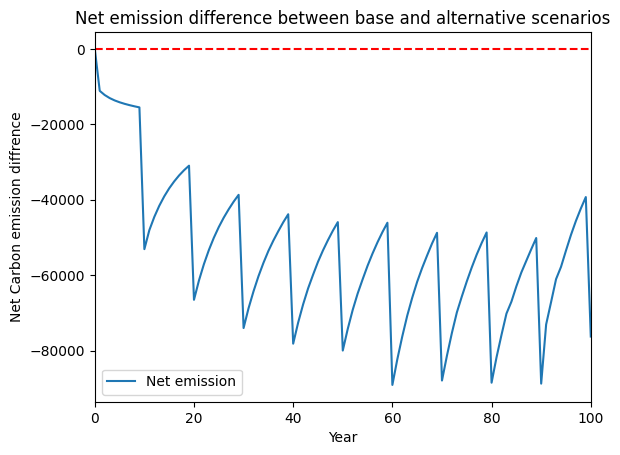

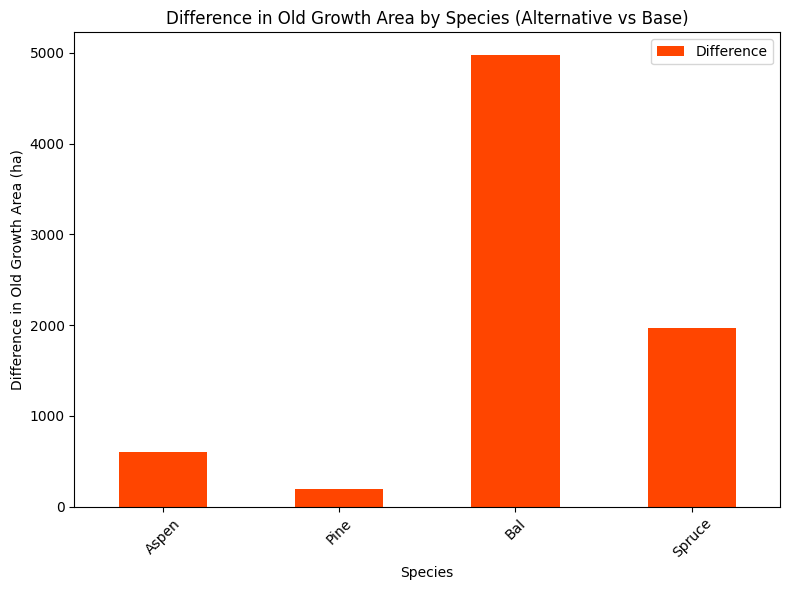

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


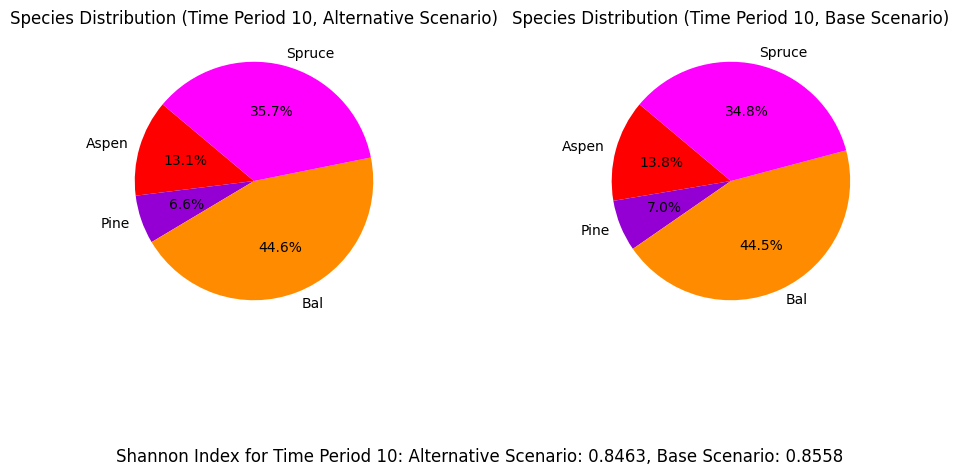

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_70%...
running the scenario for the Red Chris mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x663d80d0
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32529 column

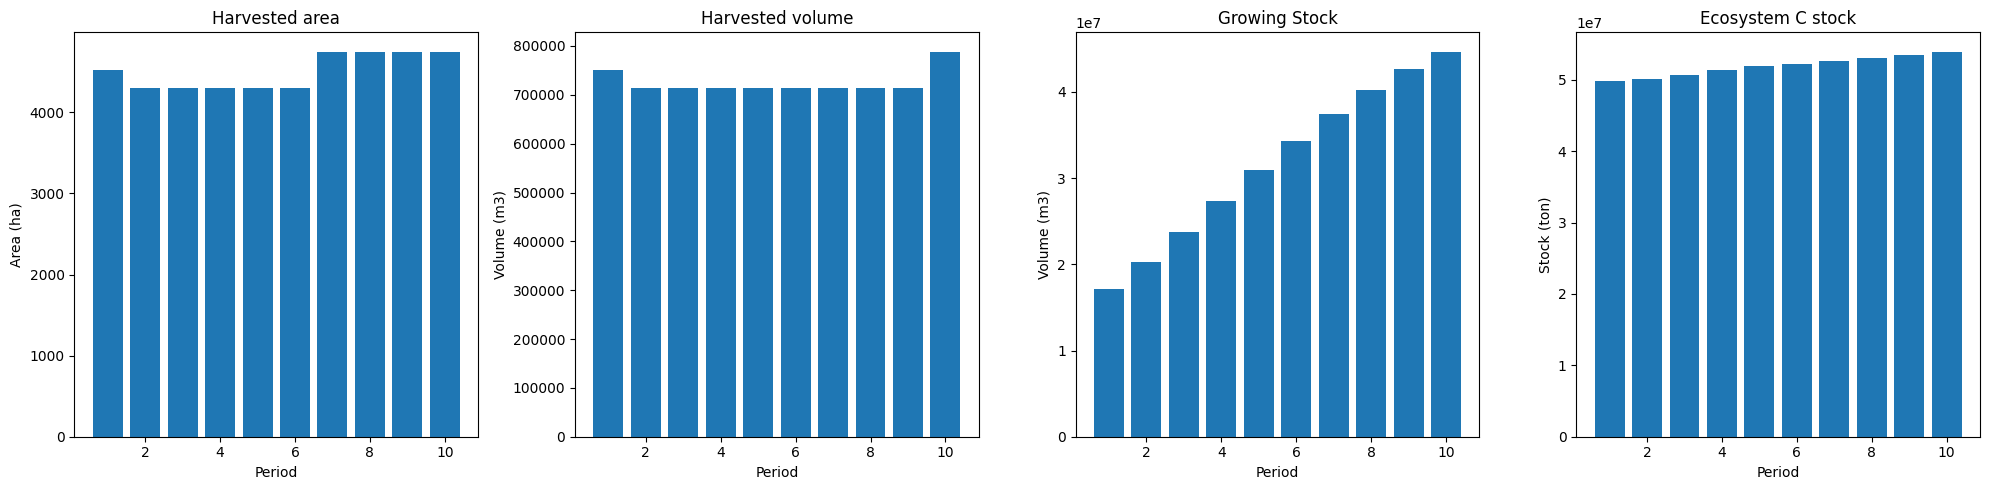

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_70%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7661
The economic indicator (the provincial government revenues) is:  261283
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


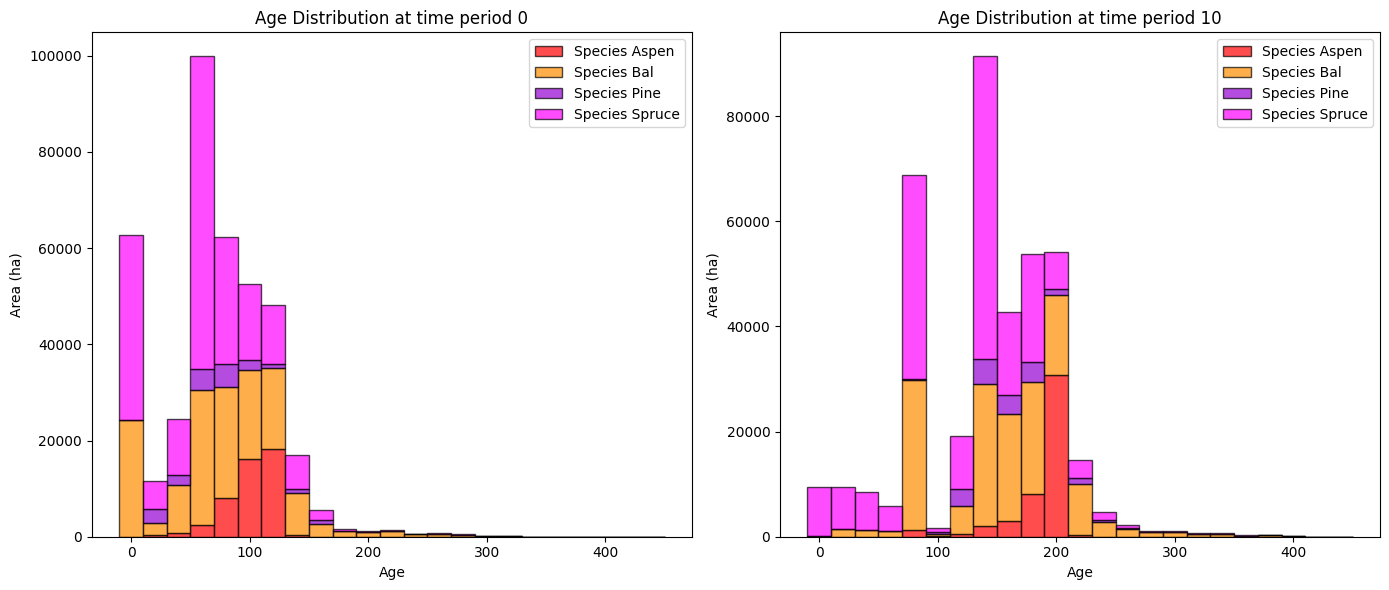

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  43166.013571  42220.699884
Pine     602.782616   9184.557788   8581.775172
Bal     4315.588546  46296.141552  41980.553006
Spruce  1072.814408  20577.280764  19504.466357

Overall diversity has **increased** by 112287.49 hectares from time period 0 to time period 10.


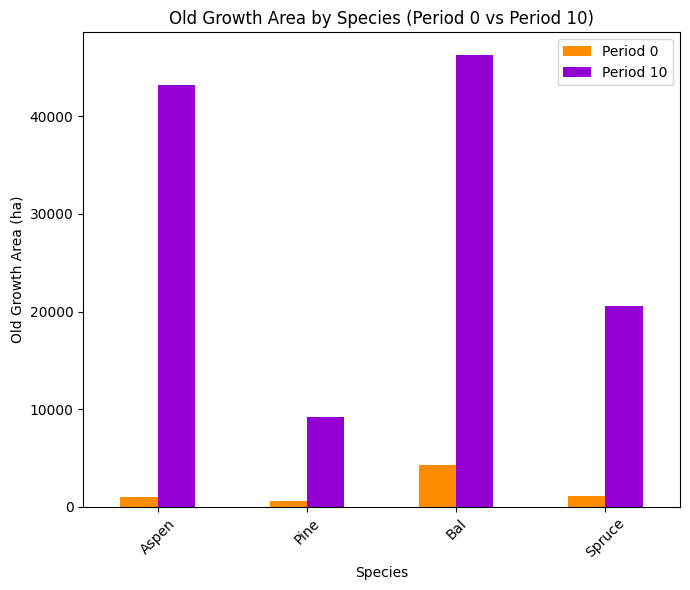

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8421

Diversity has **decreased** by 4.28% from time 0 to time 10.


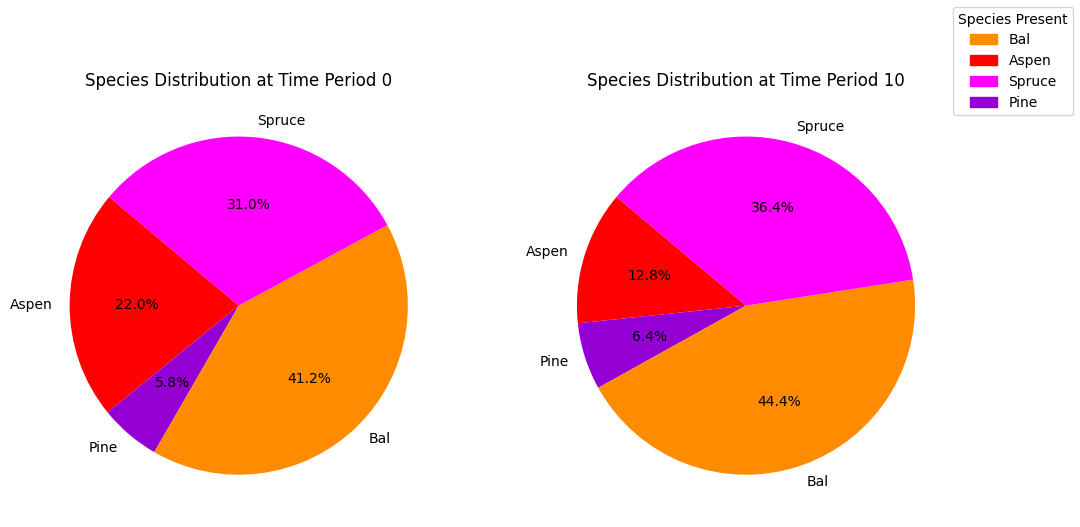

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_70%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

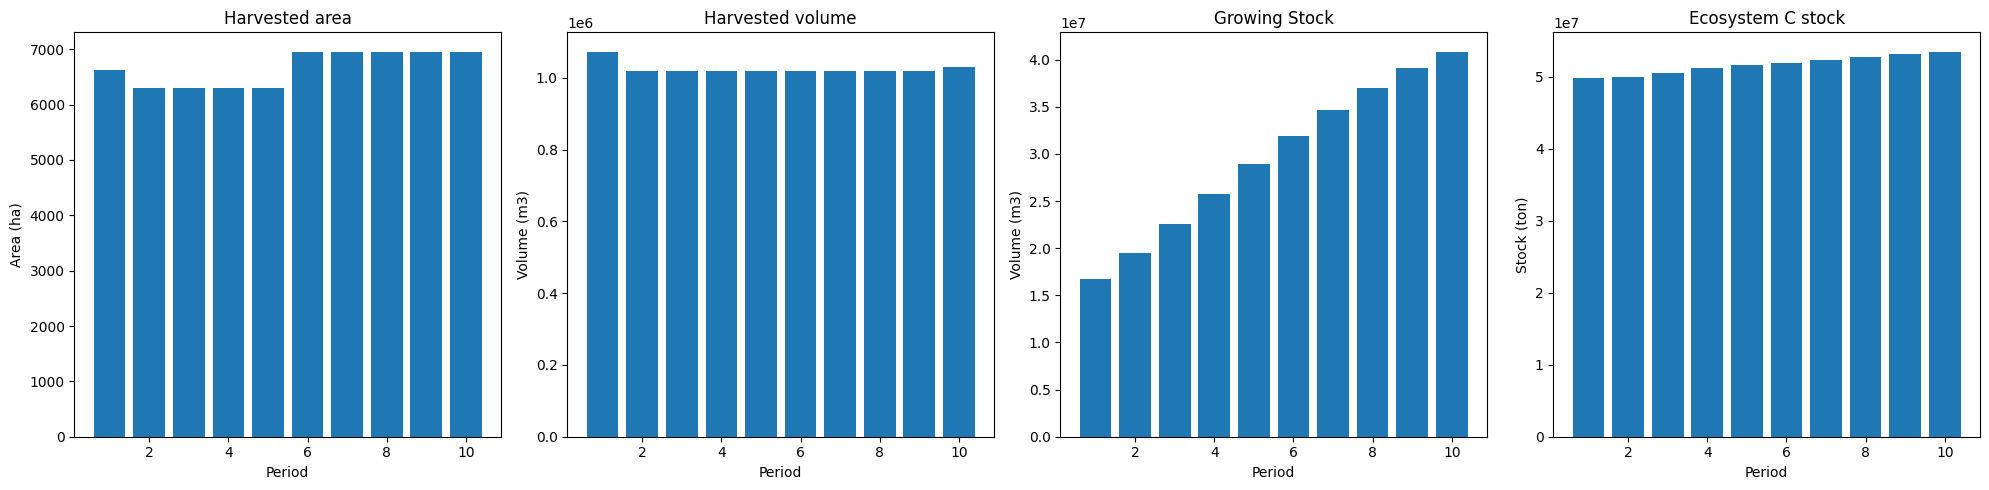

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


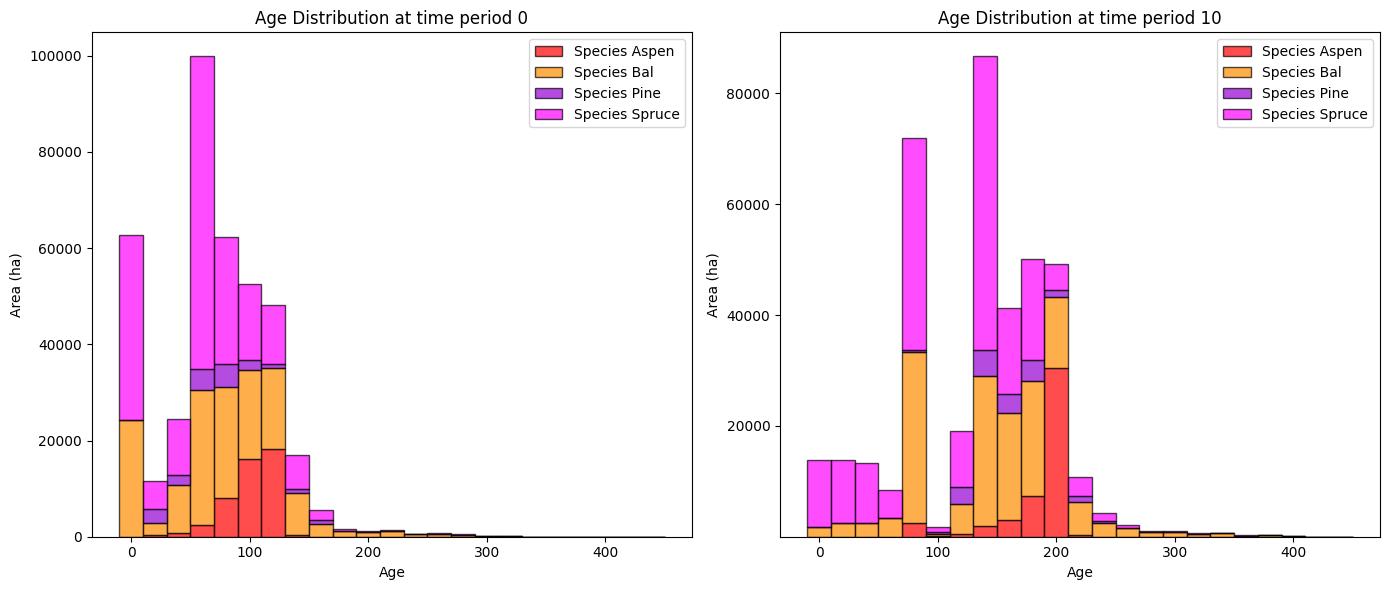

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


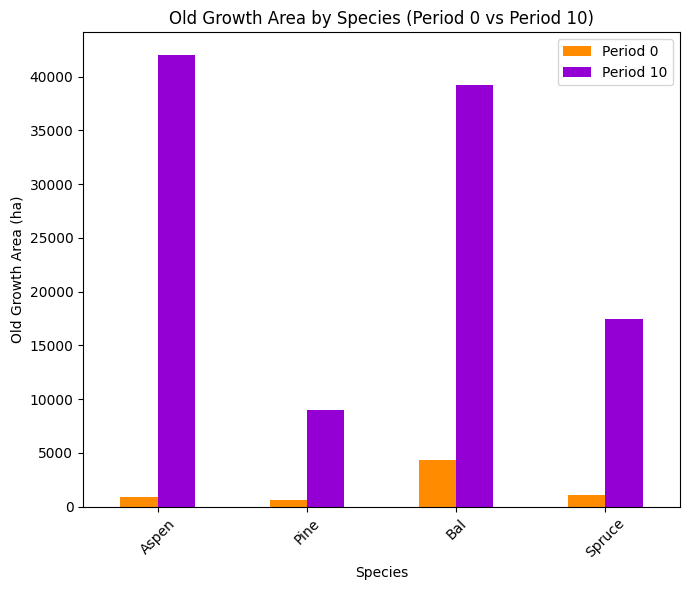

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


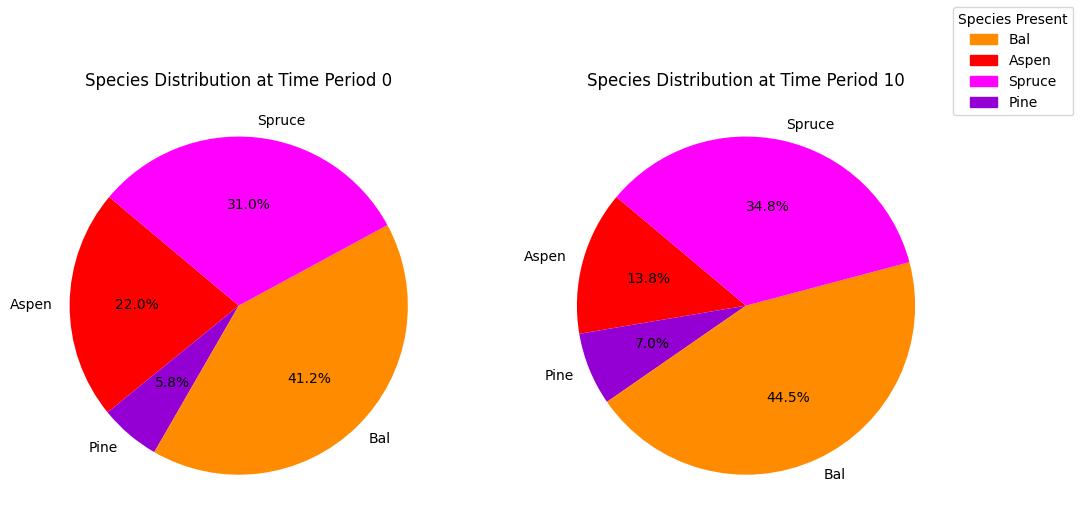

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


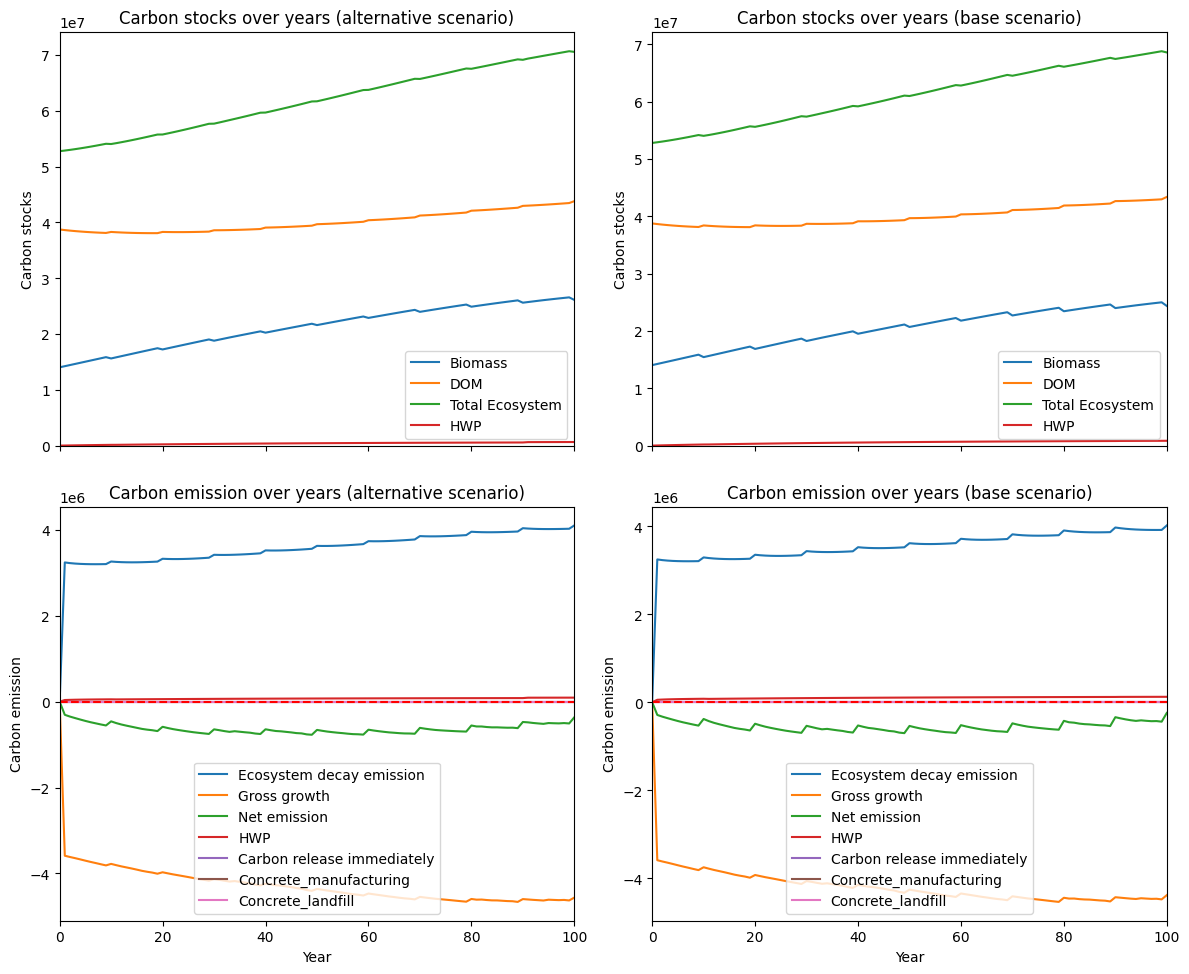

---------------------------------------------------------------------------------------
Net emission difference -1169639.7481396538
Net emission base scenario -13016055.515720552
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  8.549641046232647
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0  1155.375847  1155.375847
Pine    0.0   211.077088   211.077088
Bal     0.0  7042.027956  7042.027956
Spruce  0.0  3076.822354  3076.822354

Overall, the old growth area has **increased** by 11485.30 hectares in the alternative scenario compared to the base scenario.


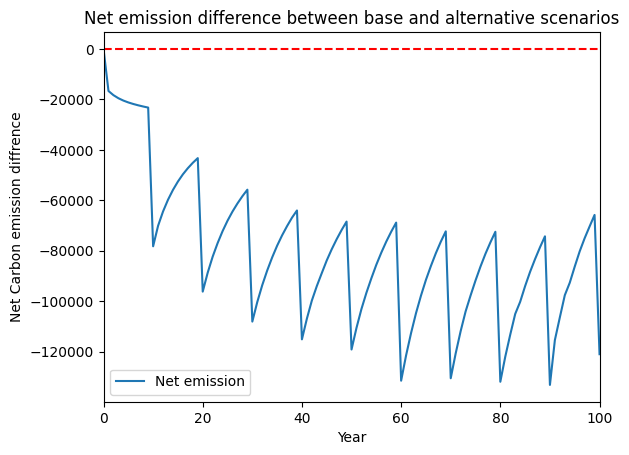

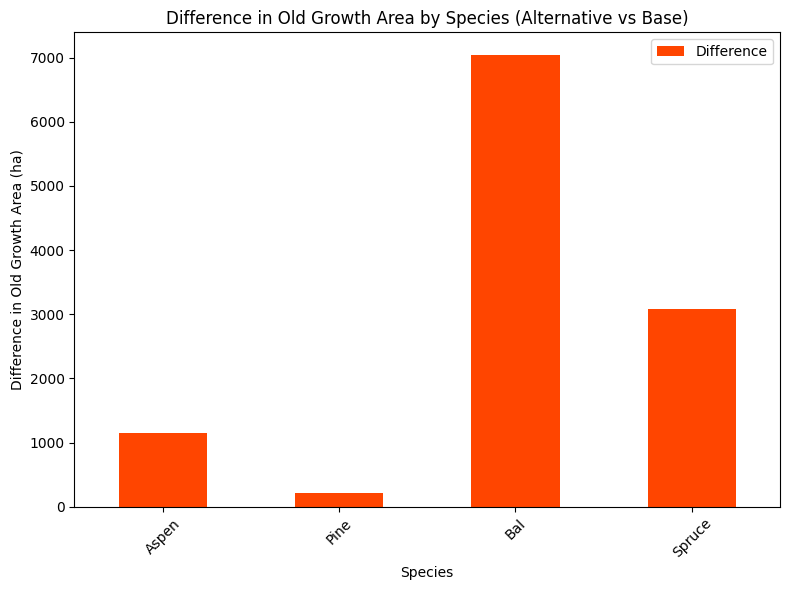

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


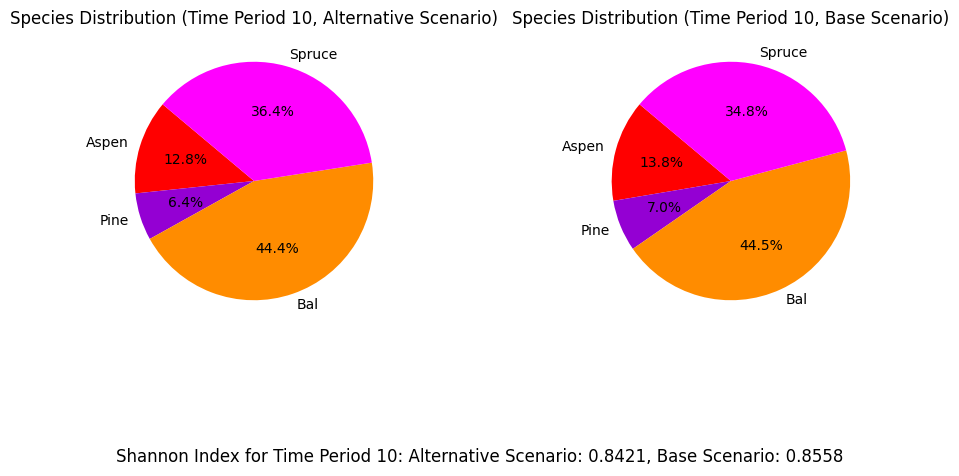

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_60%...
running the scenario for the Red Chris mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xb0ac005a
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32529 column

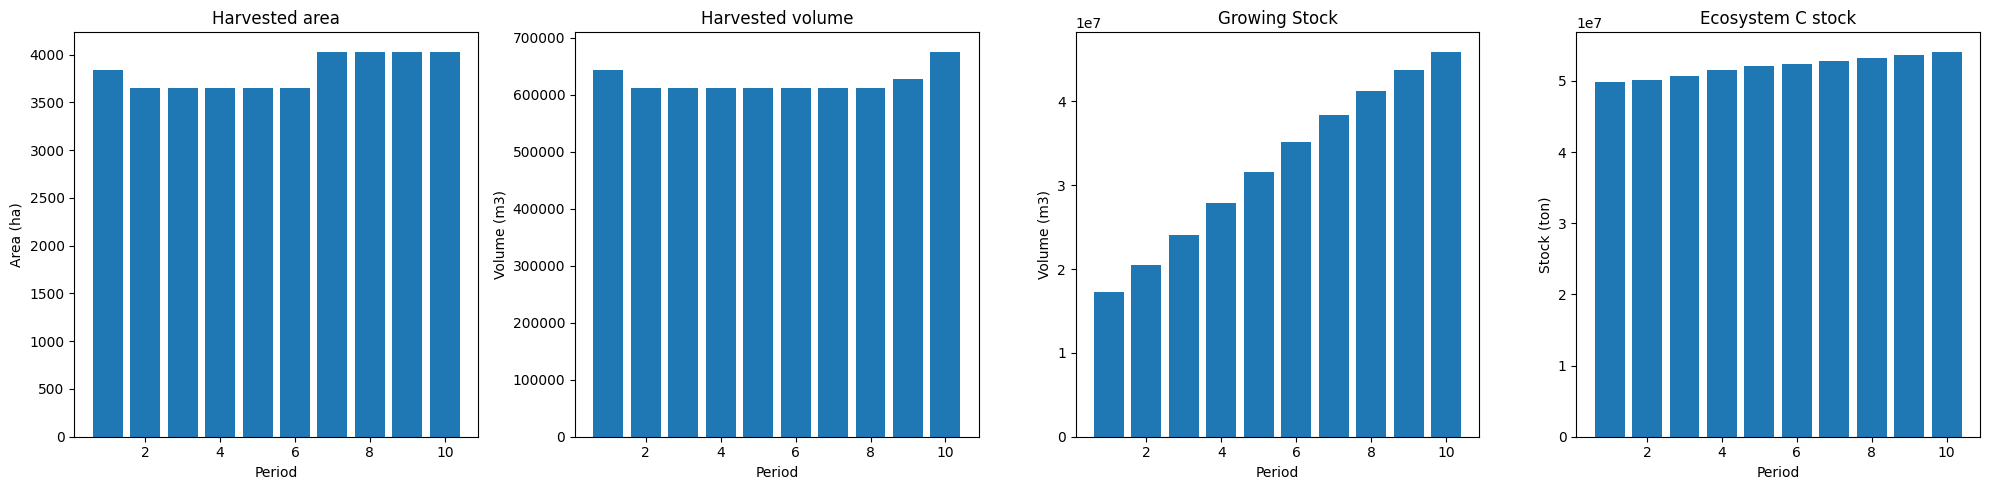

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_60%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6585
The economic indicator (the provincial government revenues) is:  224568
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


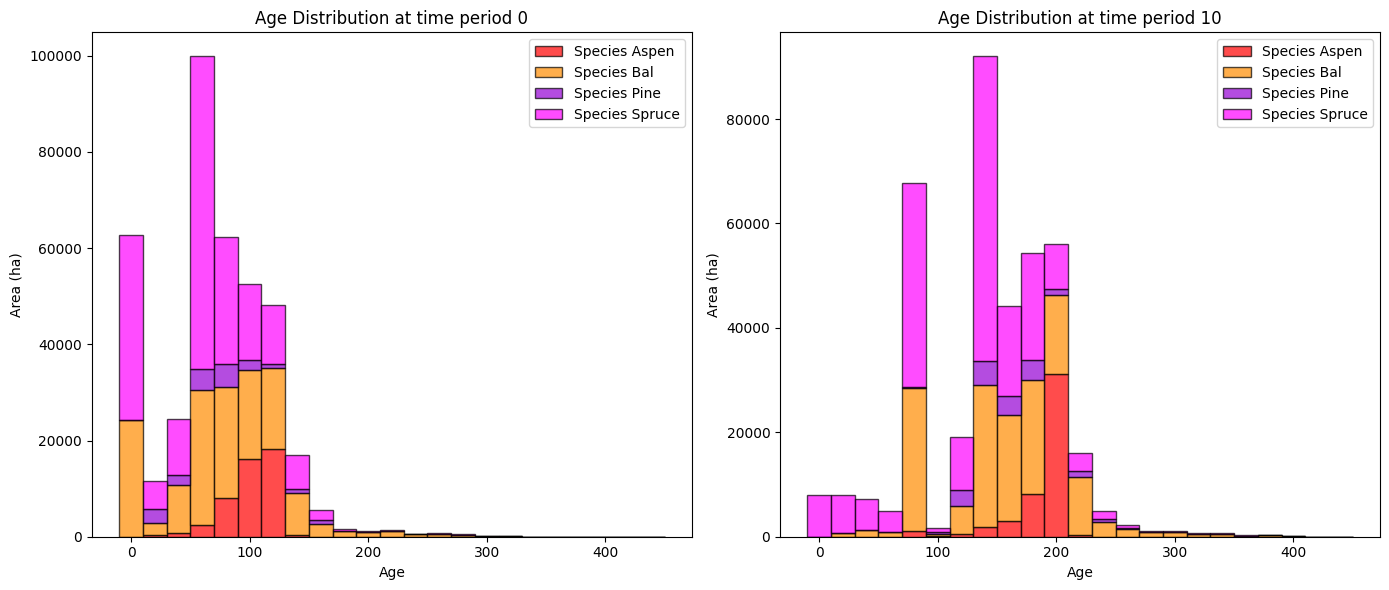

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  43492.634039  42547.320351
Pine     602.782616   9184.557788   8581.775172
Bal     4315.588546  48178.805733  43863.217186
Spruce  1072.814408  22123.195148  21050.380740

Overall diversity has **increased** by 116042.69 hectares from time period 0 to time period 10.


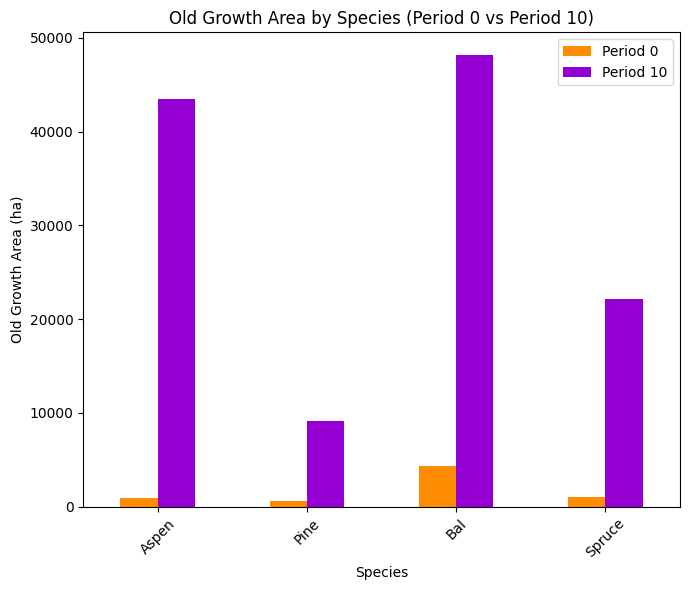

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8379

Diversity has **decreased** by 4.70% from time 0 to time 10.


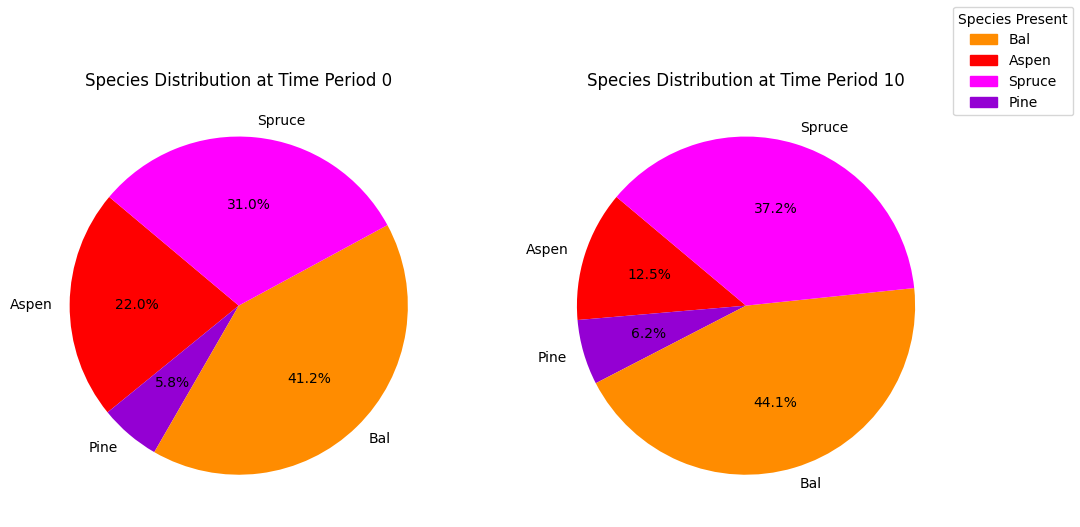

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_60%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.18s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

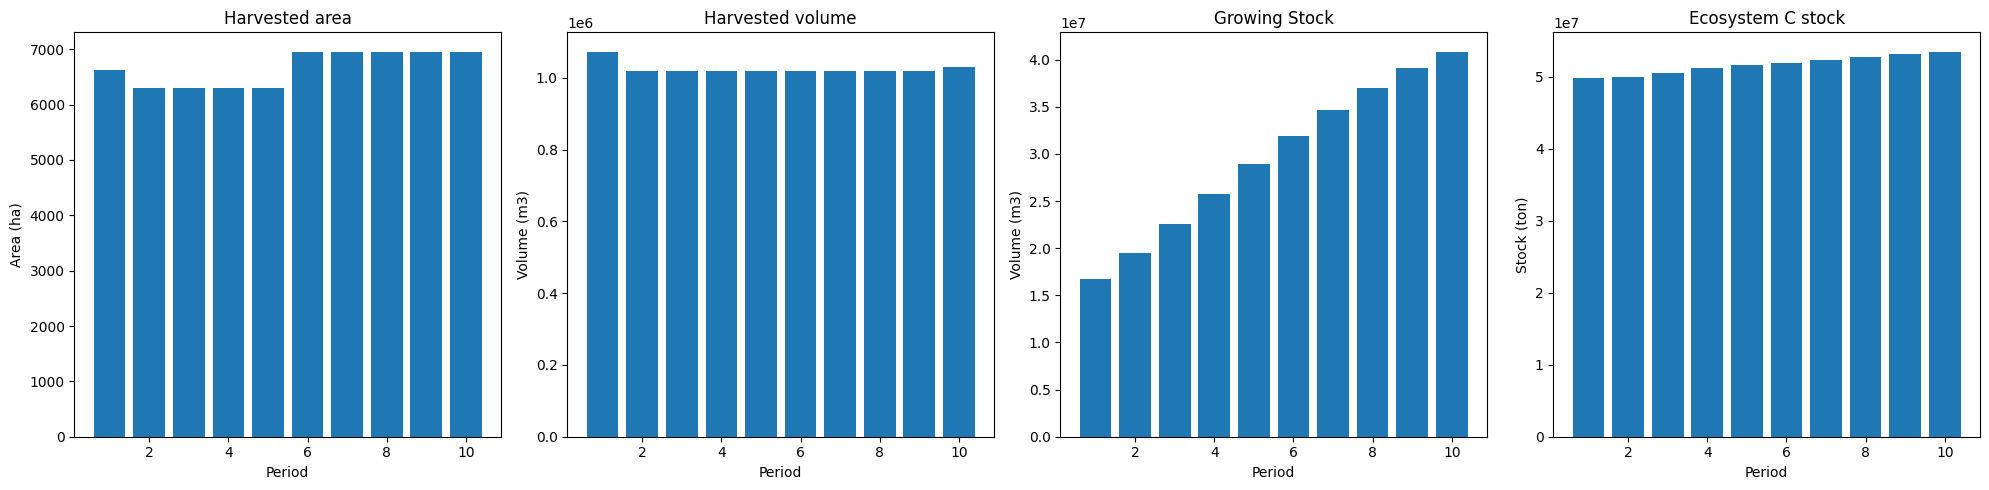

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


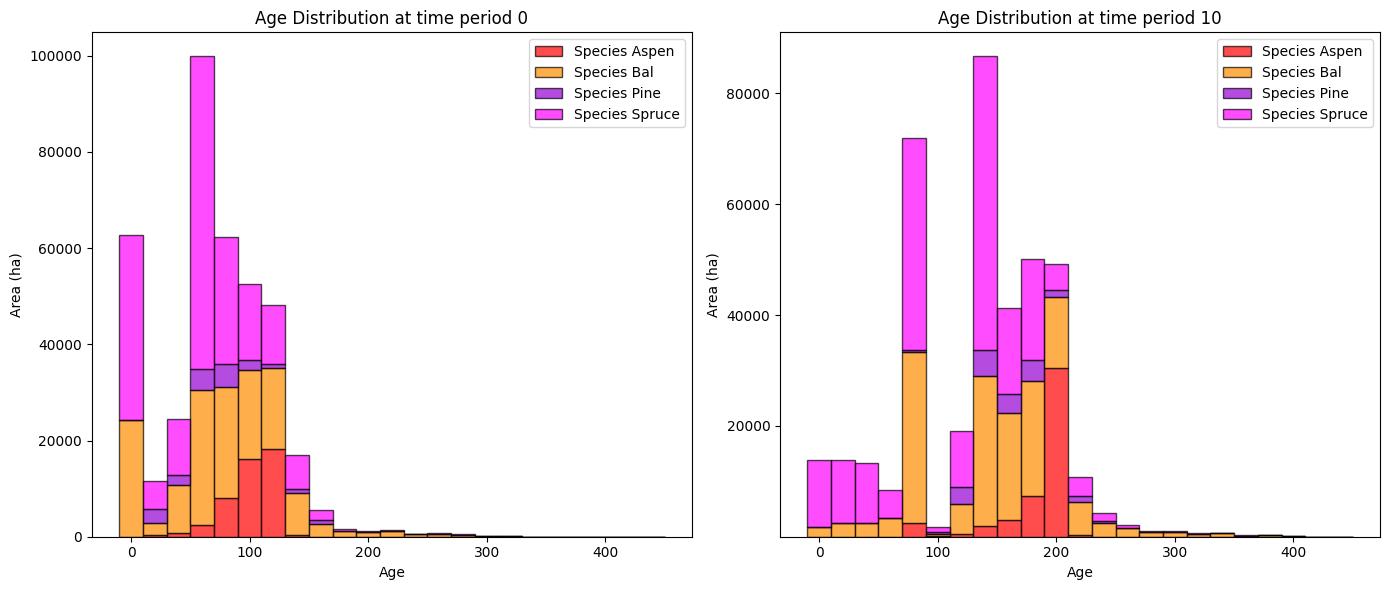

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


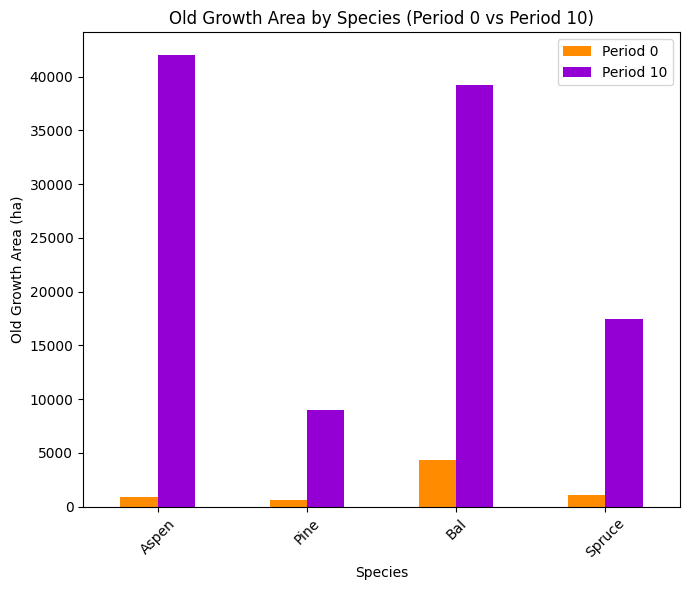

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


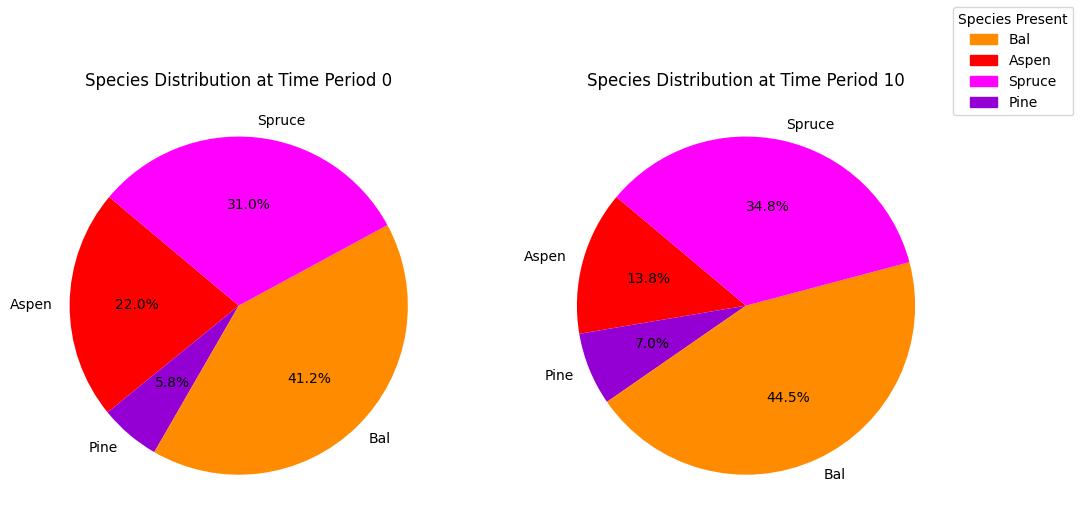

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


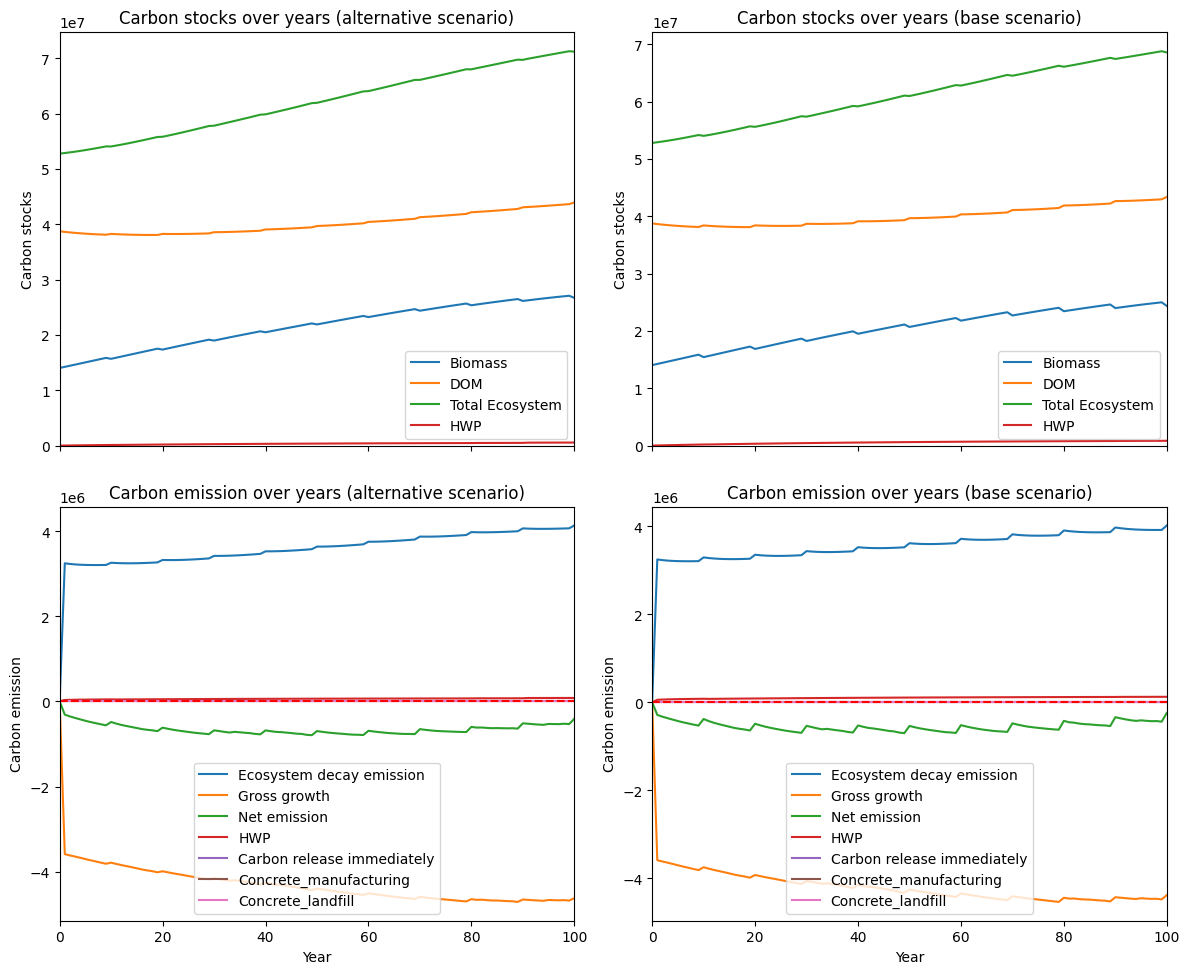

---------------------------------------------------------------------------------------
Net emission difference -1555017.7601004555
Net emission base scenario -13401433.527681353
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  6.430794719253877
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0  1481.996314  1481.996314
Pine    0.0   211.077088   211.077088
Bal     0.0  8924.692137  8924.692137
Spruce  0.0  4622.736738  4622.736738

Overall, the old growth area has **increased** by 15240.50 hectares in the alternative scenario compared to the base scenario.


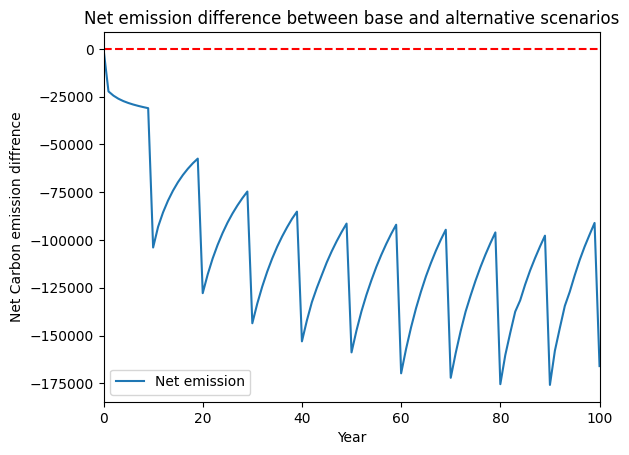

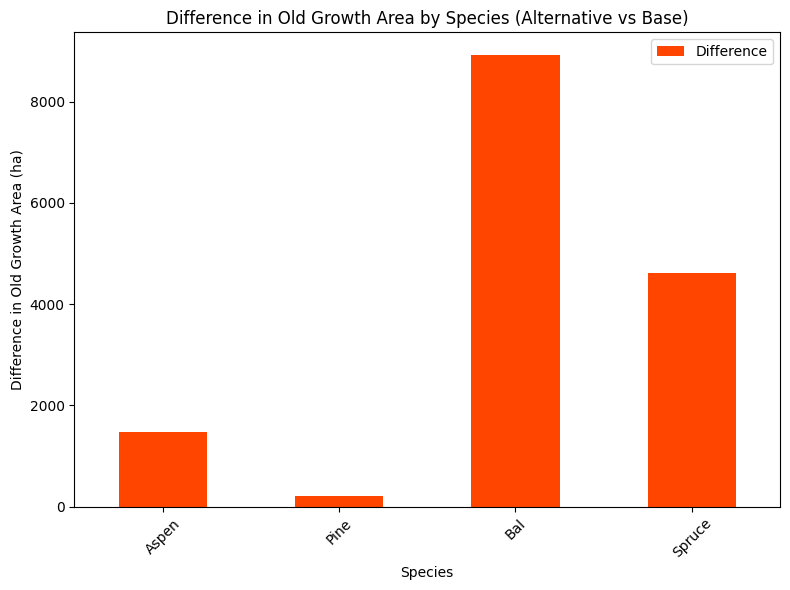

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


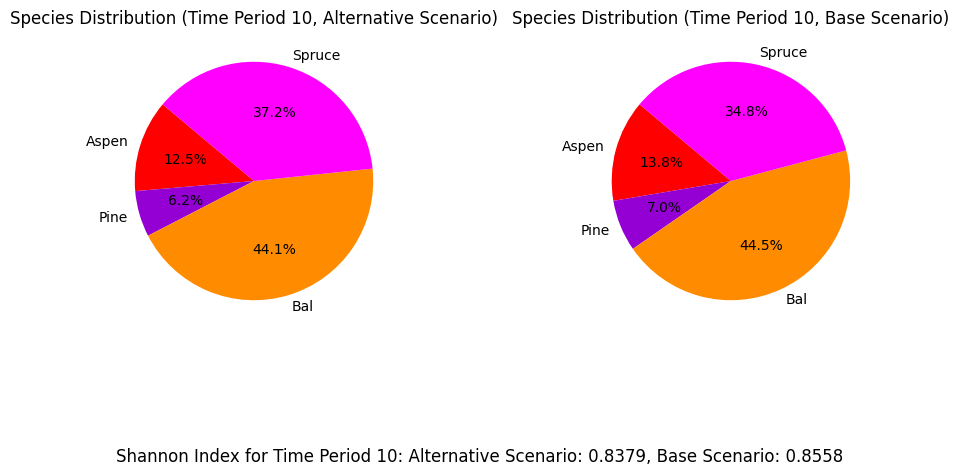

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_50%...
running the scenario for the Red Chris mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xff08b7a2
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32529 column

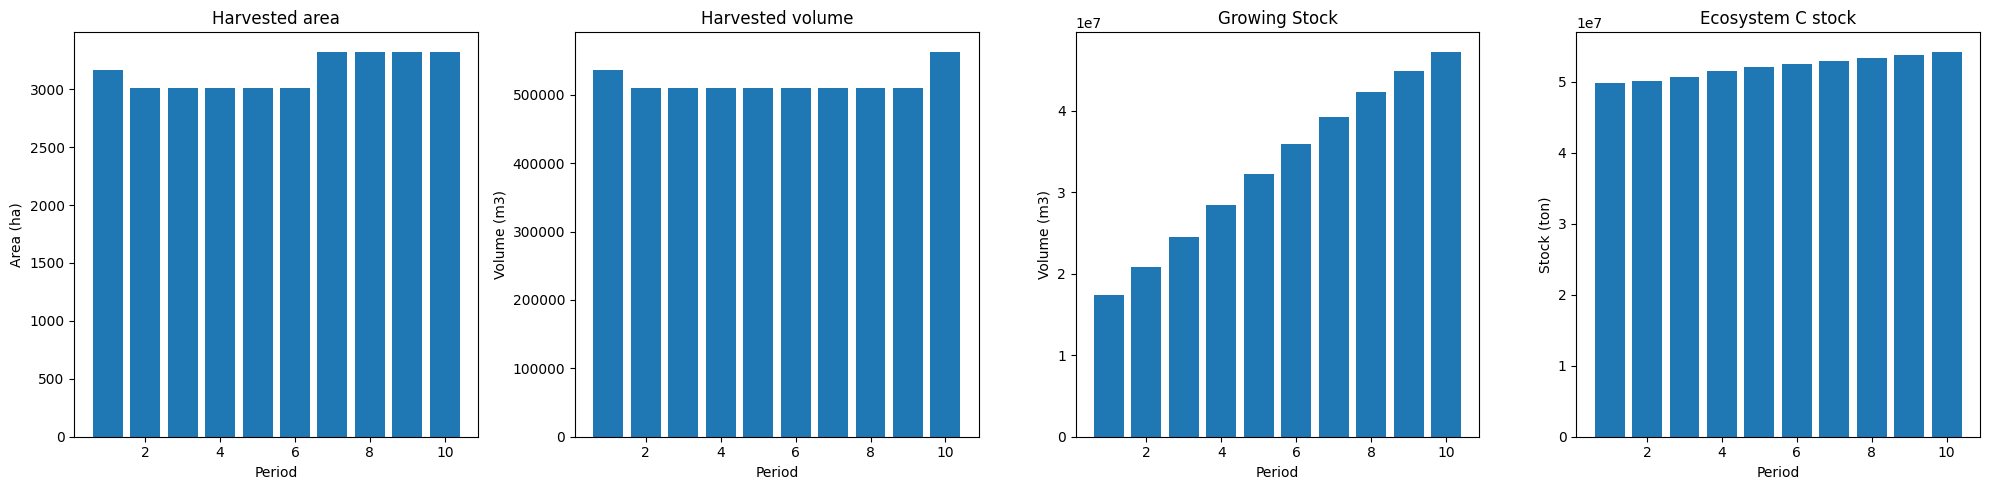

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_50%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  5472
The economic indicator (the provincial government revenues) is:  186630
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


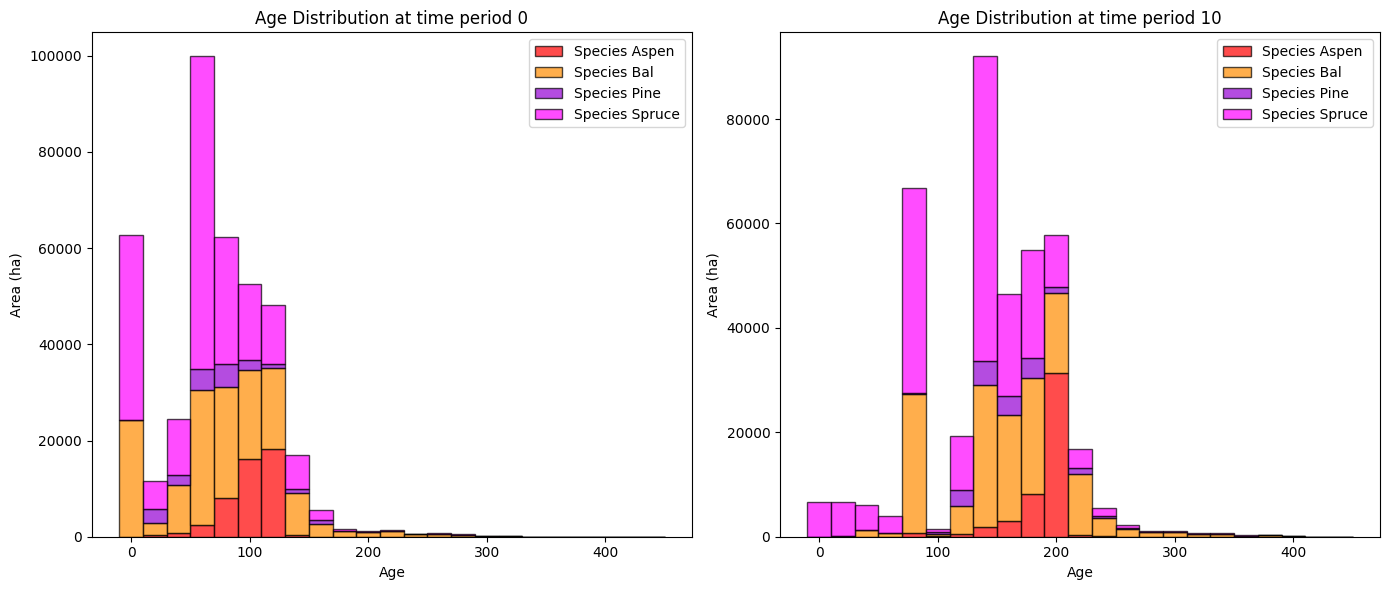

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  43818.285513  42872.971825
Pine     602.782616   9184.557788   8581.775172
Bal     4315.588546  49791.755746  45476.167200
Spruce  1072.814408  24205.710610  23132.896202

Overall diversity has **increased** by 120063.81 hectares from time period 0 to time period 10.


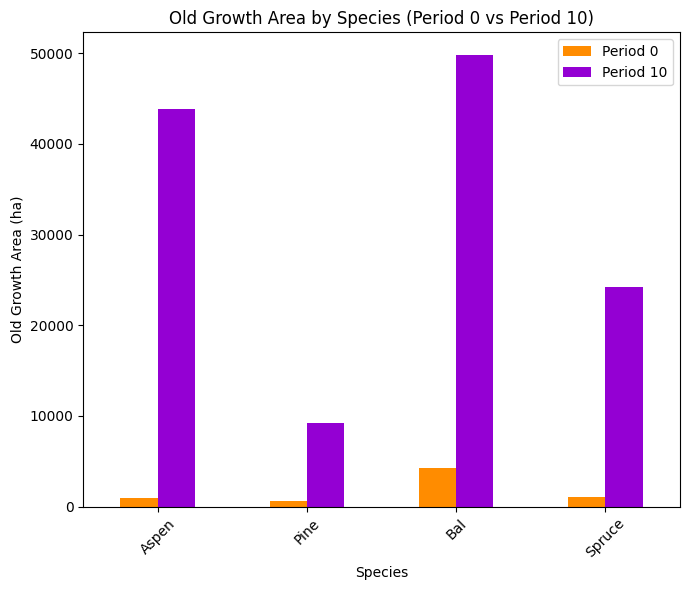

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8336

Diversity has **decreased** by 5.12% from time 0 to time 10.


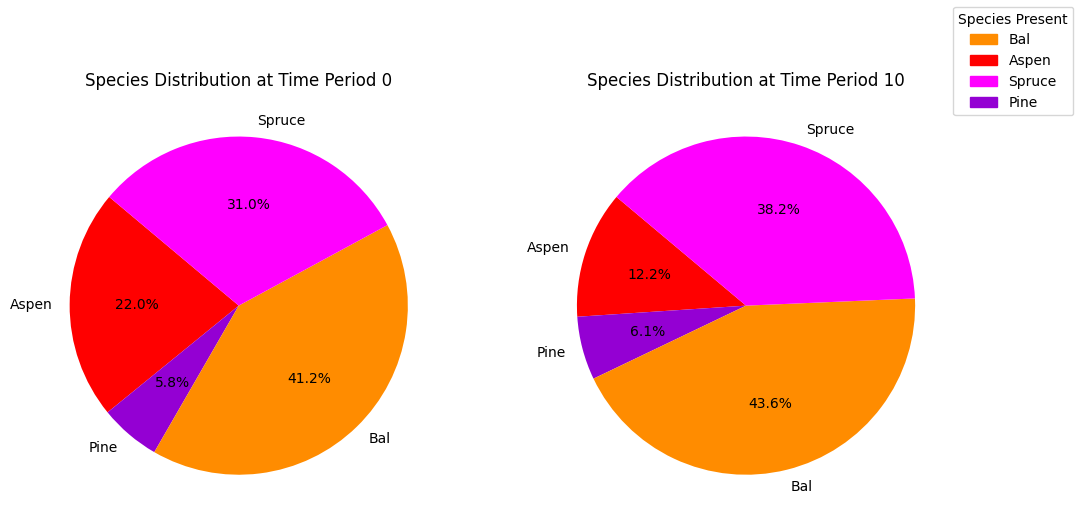

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_50%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

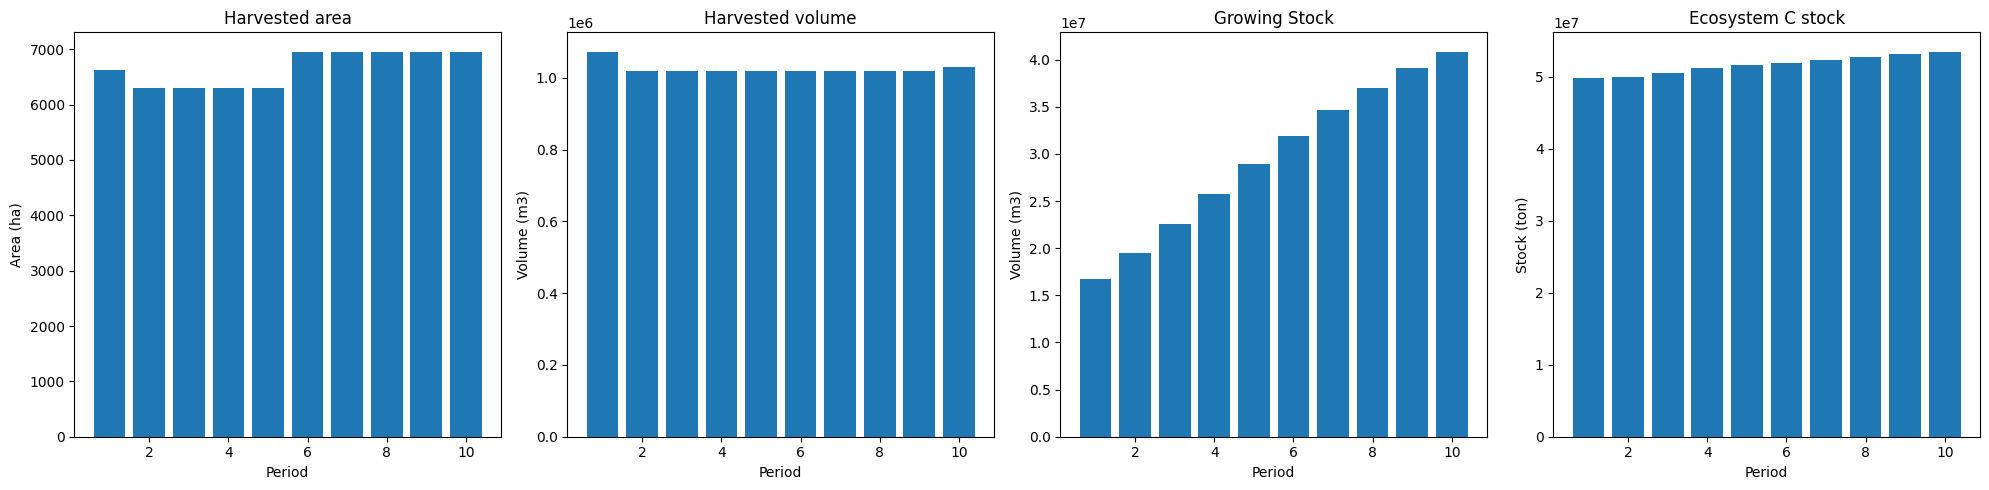

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


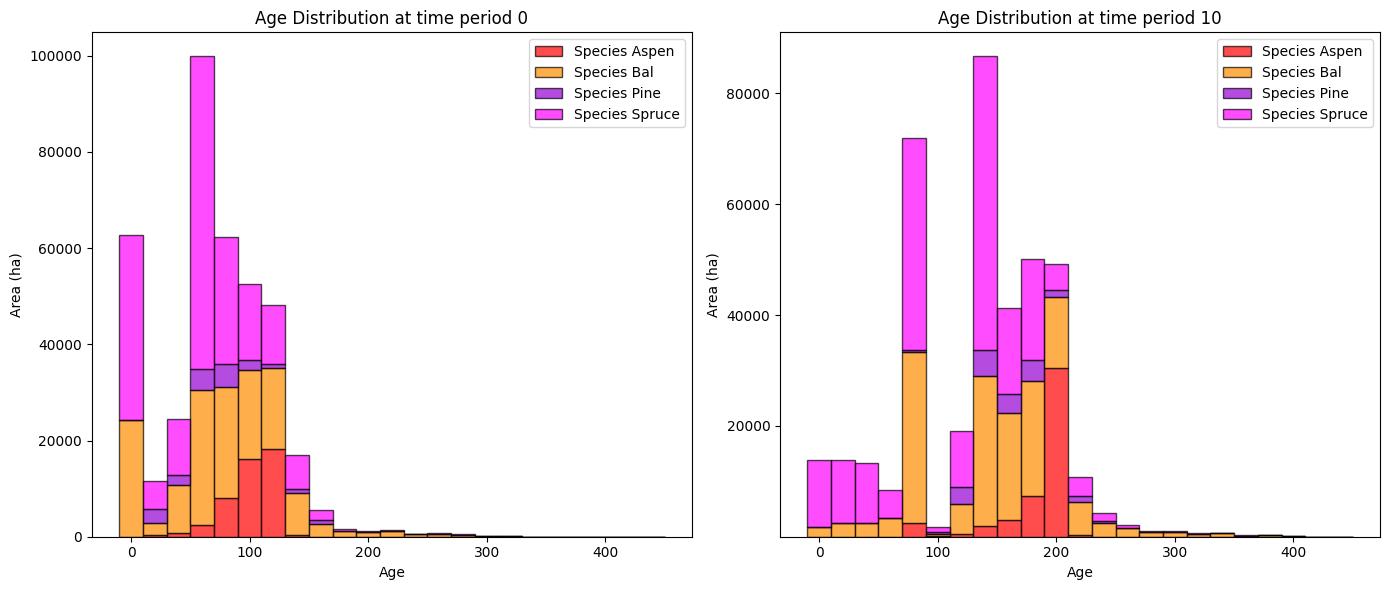

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


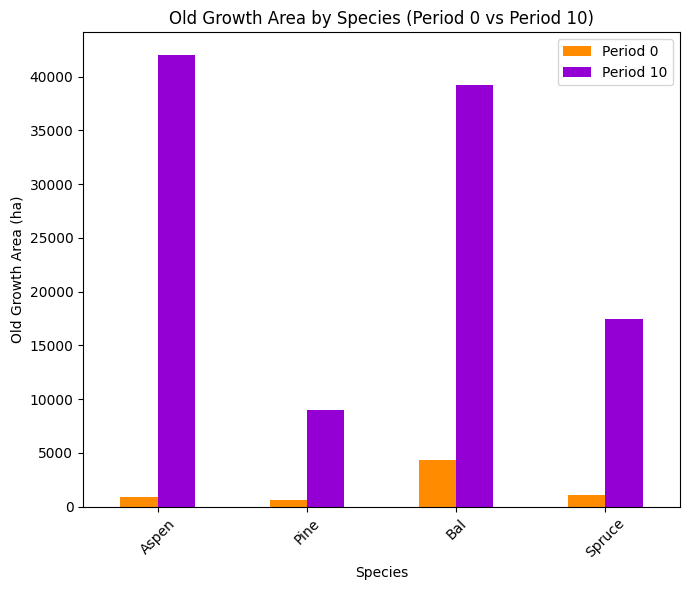

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


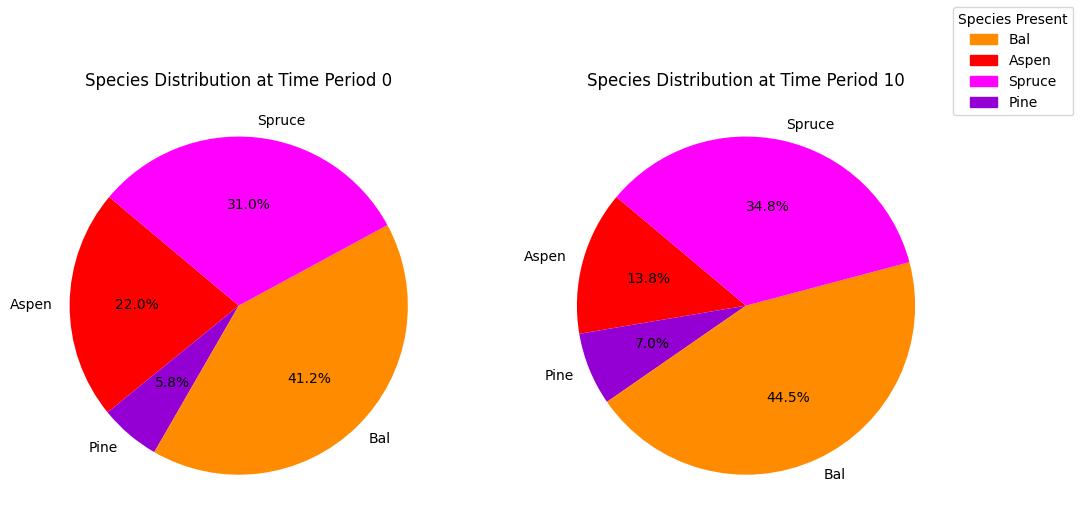

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


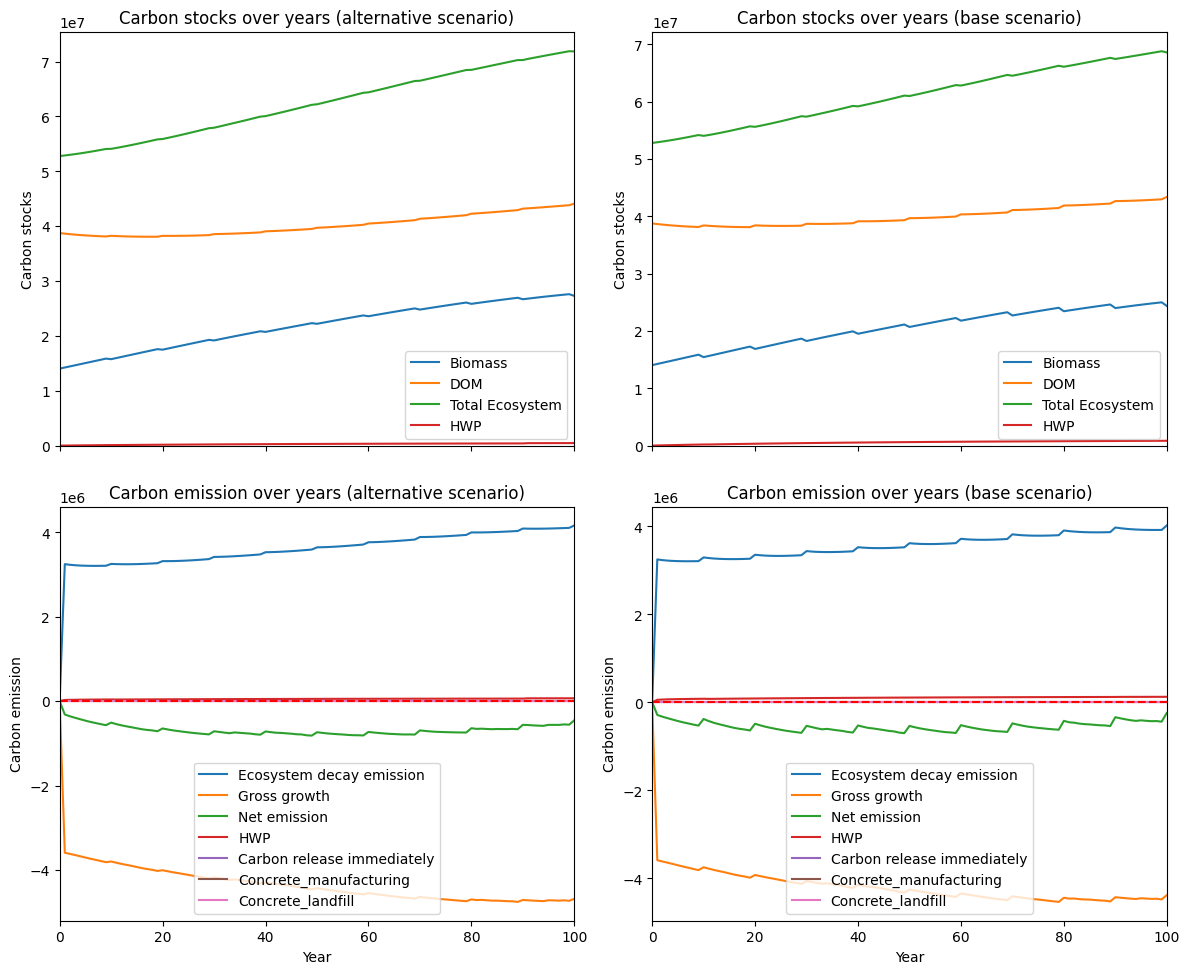

---------------------------------------------------------------------------------------
Net emission difference -1931629.0099293971
Net emission base scenario -13778044.777510293
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  5.176977539991237
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   1807.647788   1807.647788
Pine    0.0    211.077088    211.077088
Bal     0.0  10537.642150  10537.642150
Spruce  0.0   6705.252200   6705.252200

Overall, the old growth area has **increased** by 19261.62 hectares in the alternative scenario compared to the base scenario.


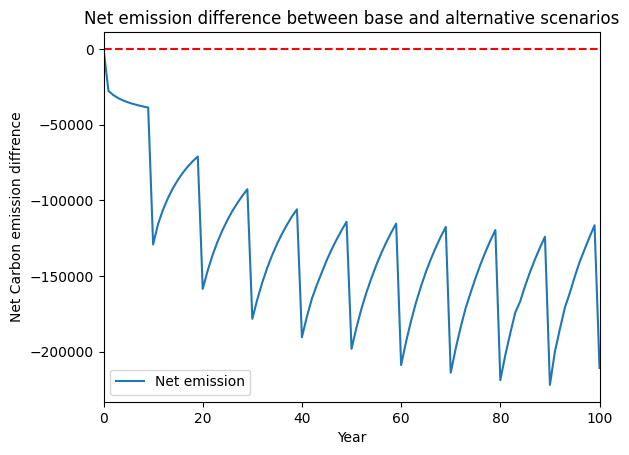

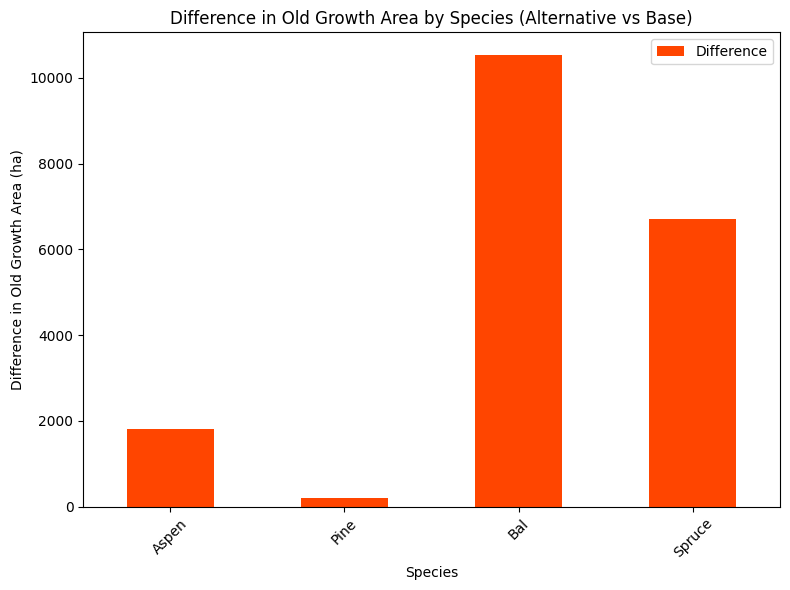

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


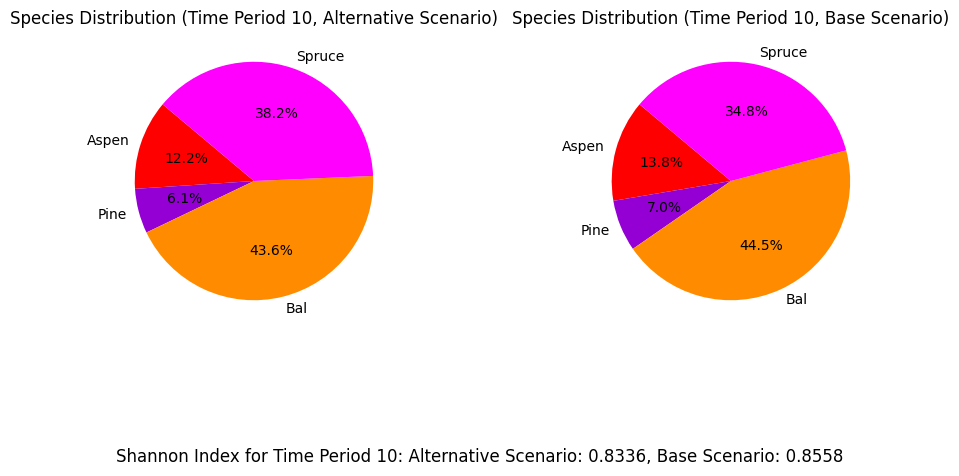

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_40%...
running the scenario for the Red Chris mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x9e532461
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32529 column

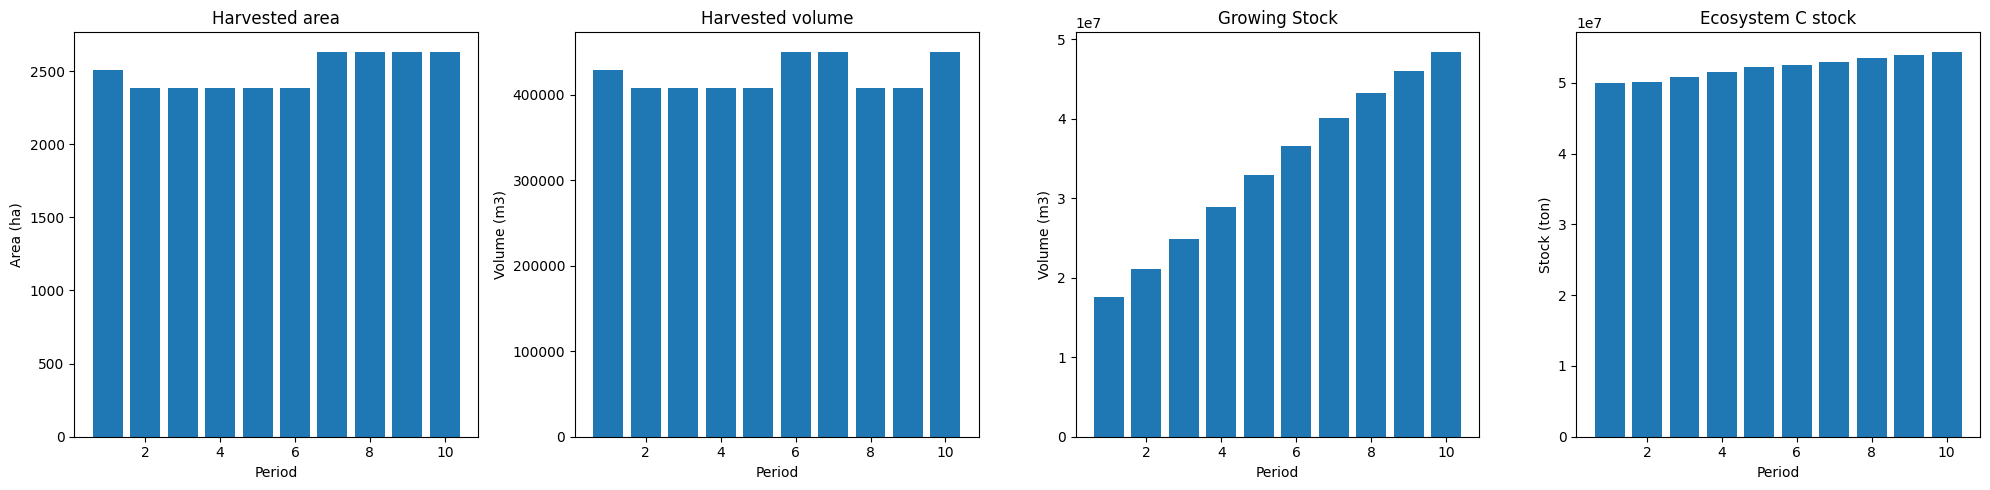

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_40%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  4468
The economic indicator (the provincial government revenues) is:  152399
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


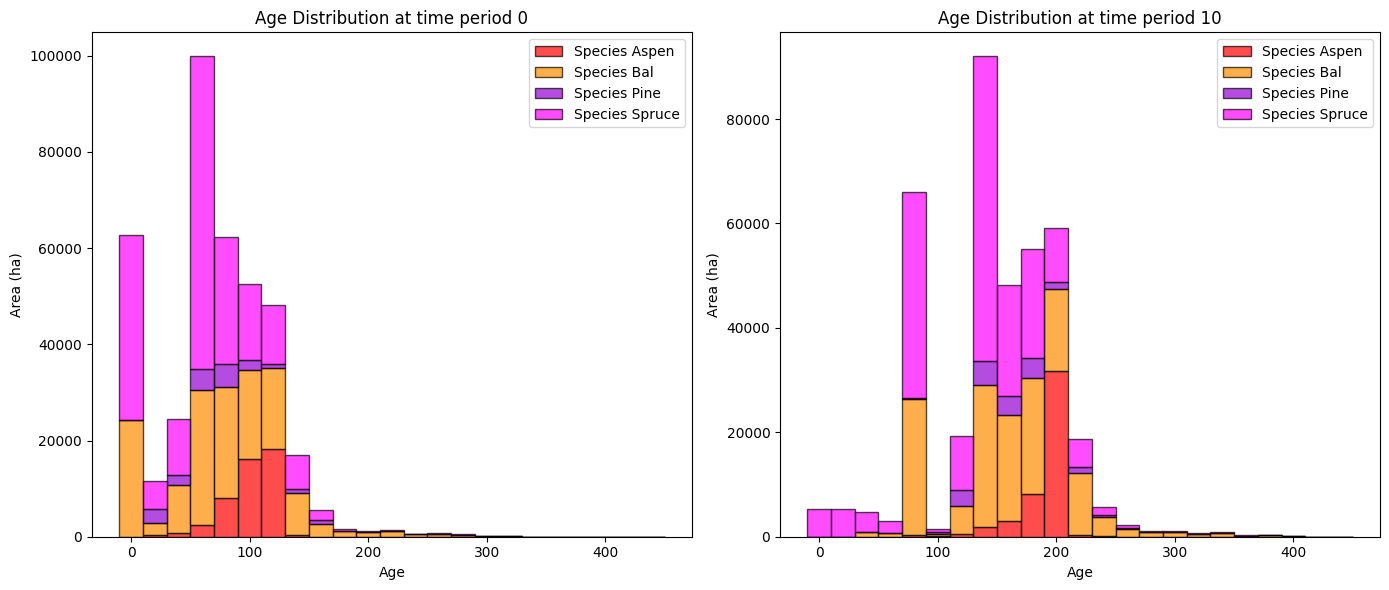

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  44227.196044  43281.882356
Pine     602.782616   9184.557788   8581.775172
Bal     4315.588546  50713.715389  46398.126843
Spruce  1072.814408  27178.619260  26105.804852

Overall diversity has **increased** by 124367.59 hectares from time period 0 to time period 10.


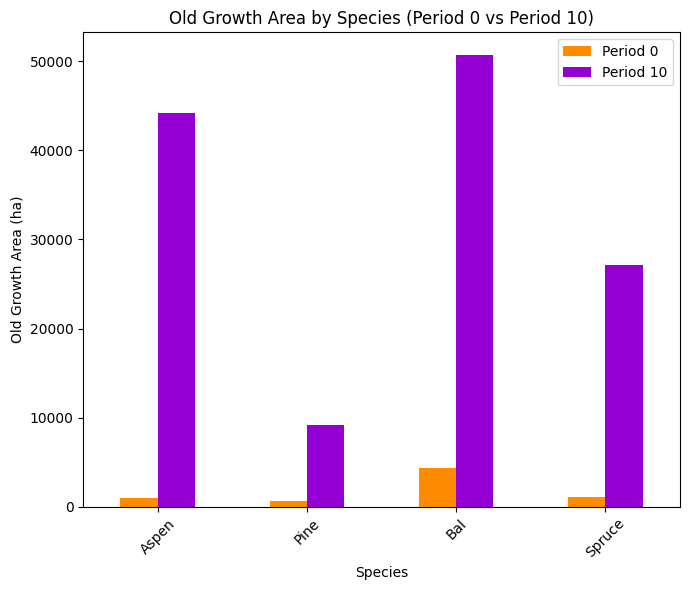

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8301

Diversity has **decreased** by 5.47% from time 0 to time 10.


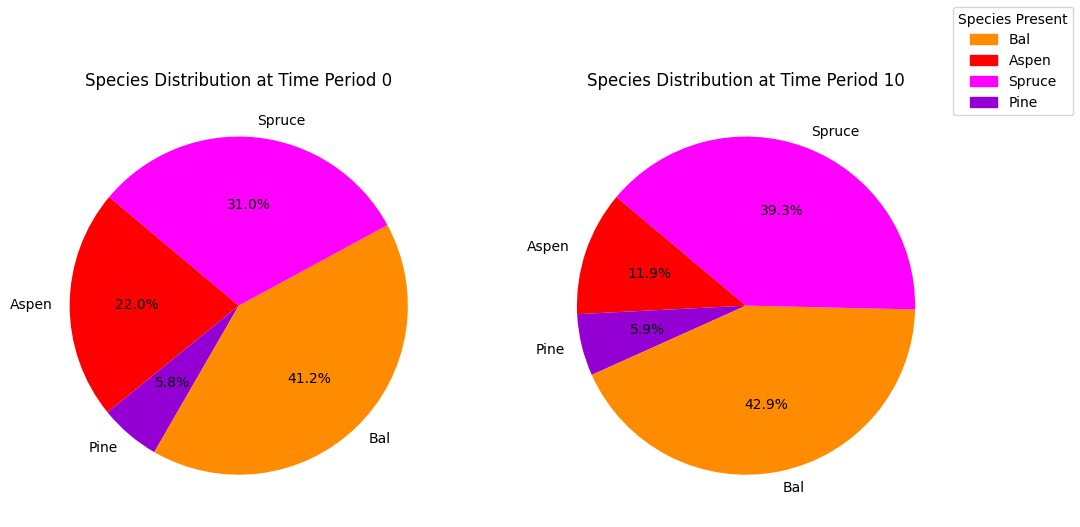

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_40%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

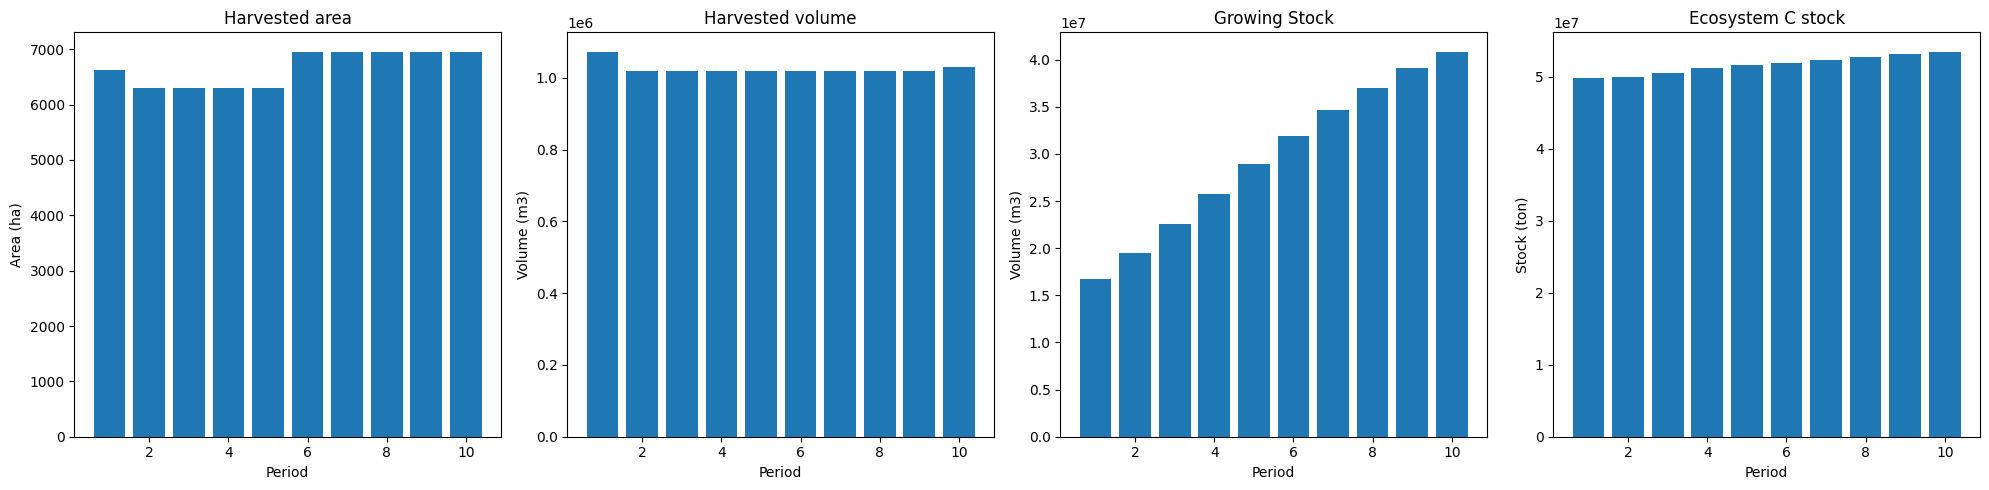

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


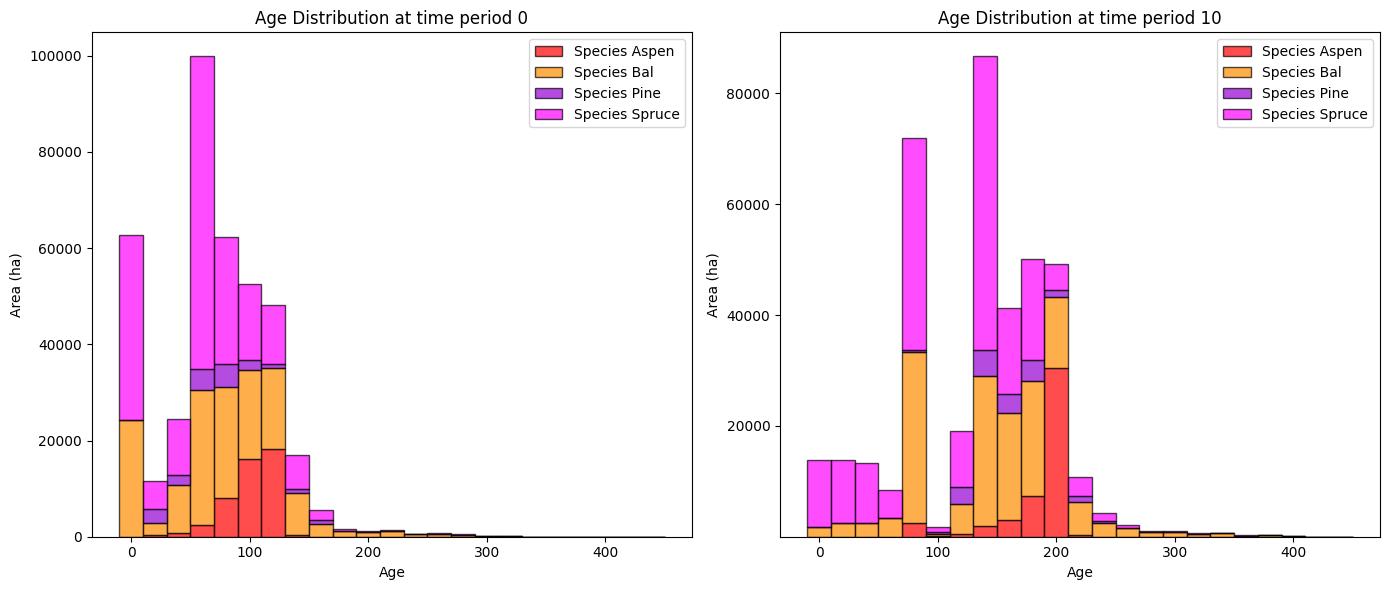

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


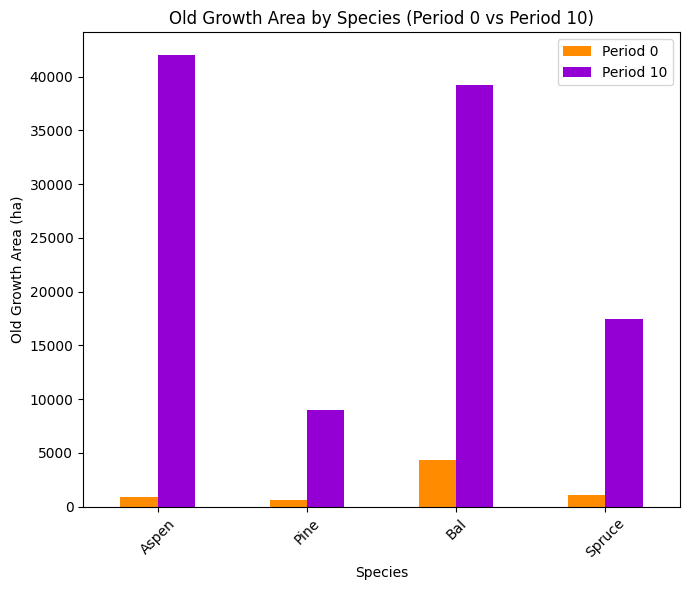

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


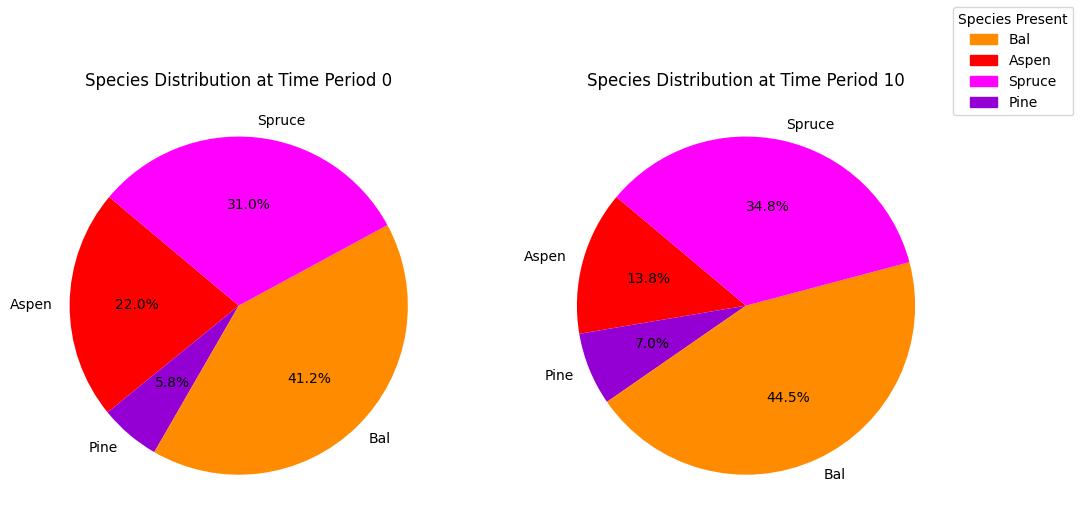

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


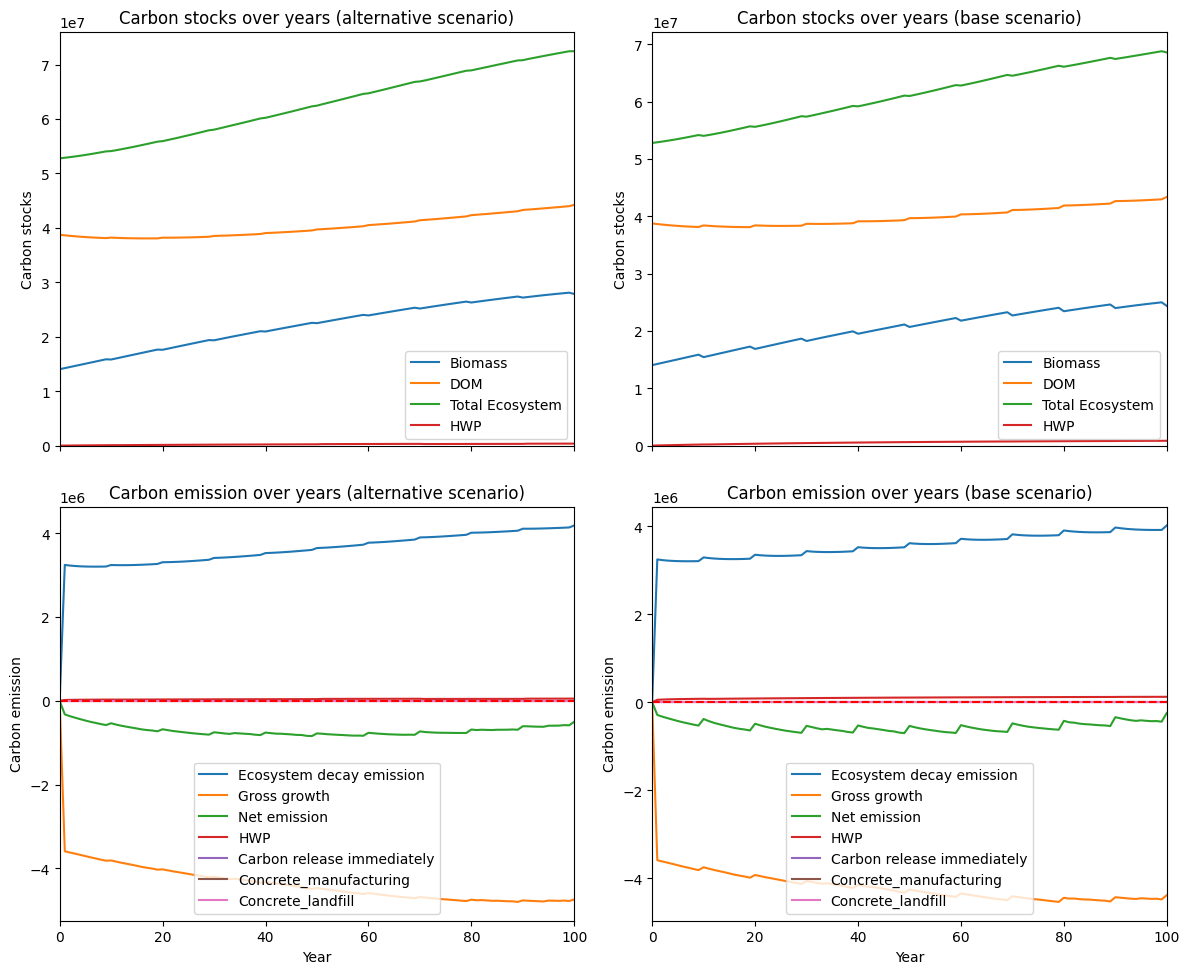

---------------------------------------------------------------------------------------
Net emission difference -2297518.7966137007
Net emission base scenario -14143934.564194597
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  4.352521517882222
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   2216.558319   2216.558319
Pine    0.0    211.077088    211.077088
Bal     0.0  11459.601794  11459.601794
Spruce  0.0   9678.160850   9678.160850

Overall, the old growth area has **increased** by 23565.40 hectares in the alternative scenario compared to the base scenario.


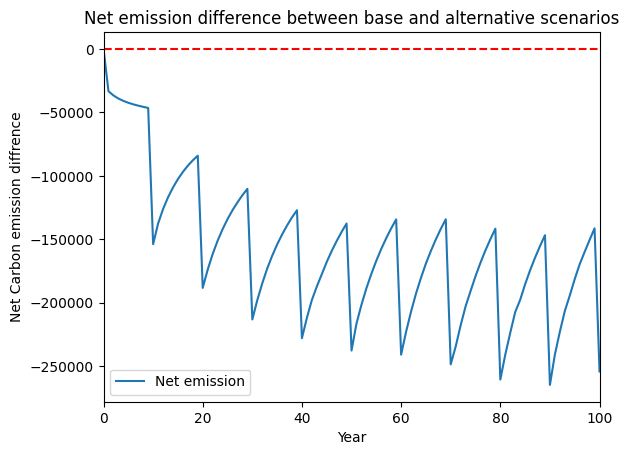

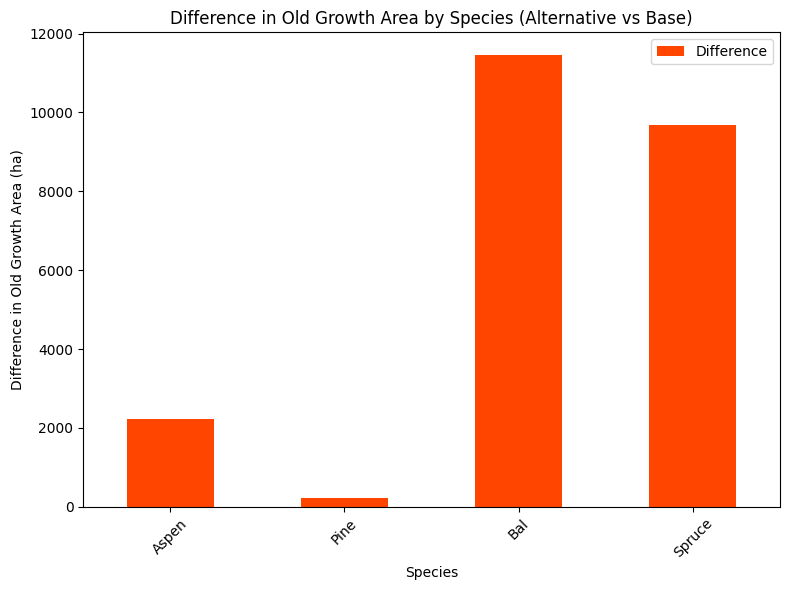

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


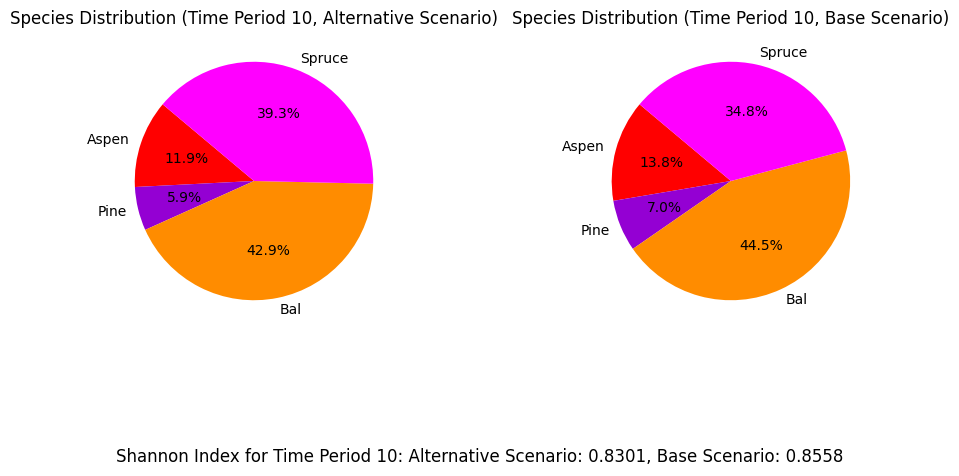

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_30%...
running the scenario for the Red Chris mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xc719a2cf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32529 column

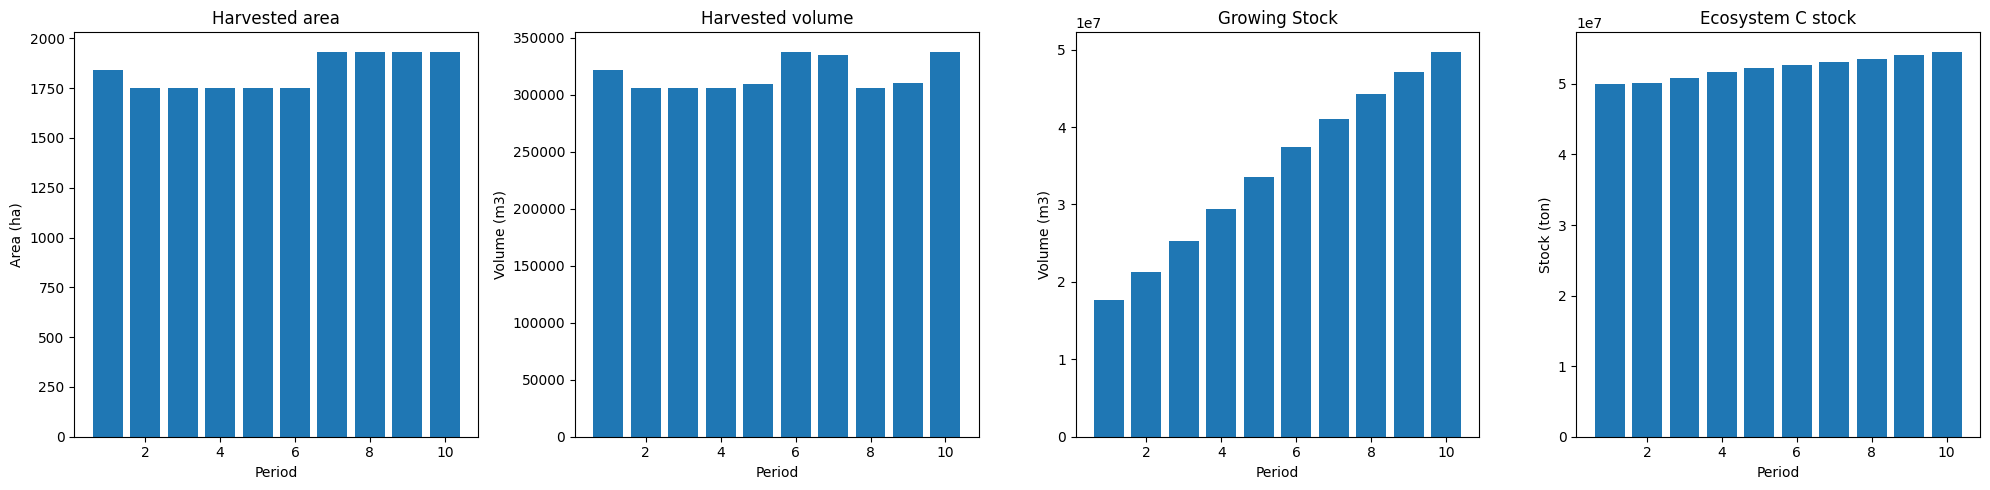

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_30%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3357
The economic indicator (the provincial government revenues) is:  114500
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


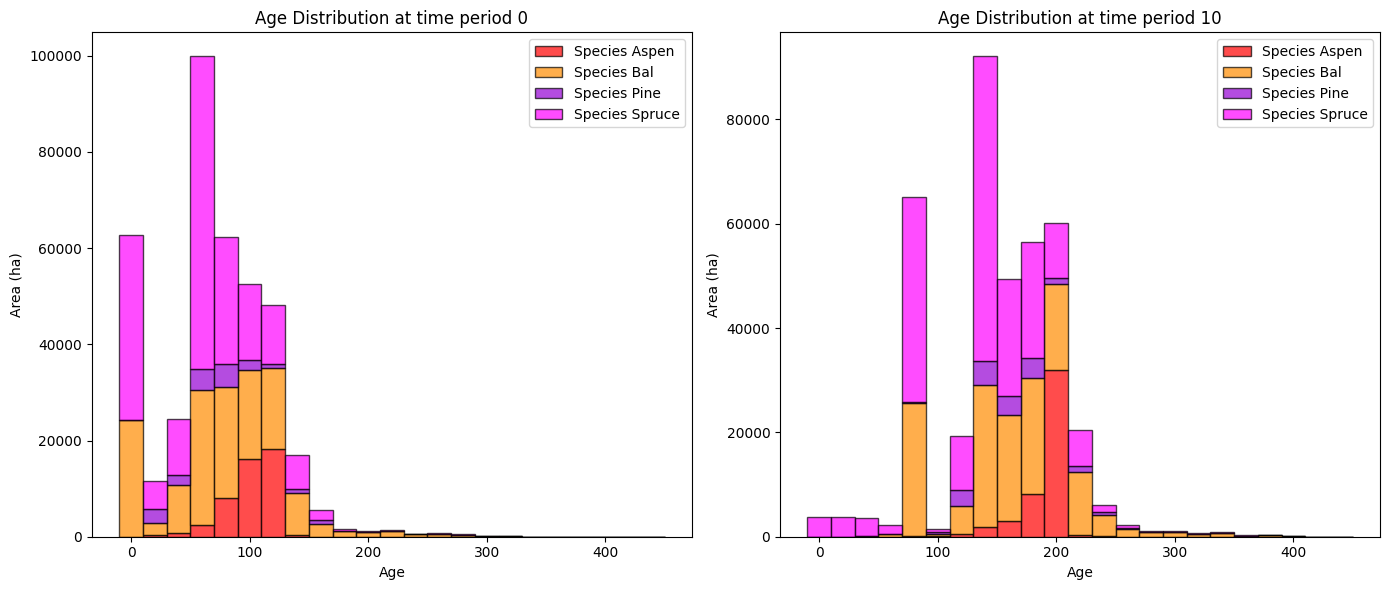

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  44354.015077  43408.701389
Pine     602.782616   9184.557788   8581.775172
Bal     4315.588546  52261.427793  47945.839247
Spruce  1072.814408  30049.718724  28976.904317

Overall diversity has **increased** by 128913.22 hectares from time period 0 to time period 10.


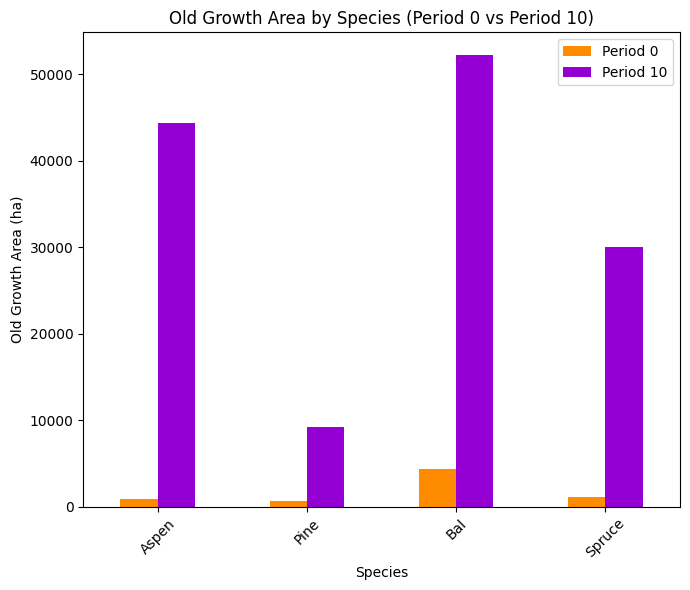

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8256

Diversity has **decreased** by 5.93% from time 0 to time 10.


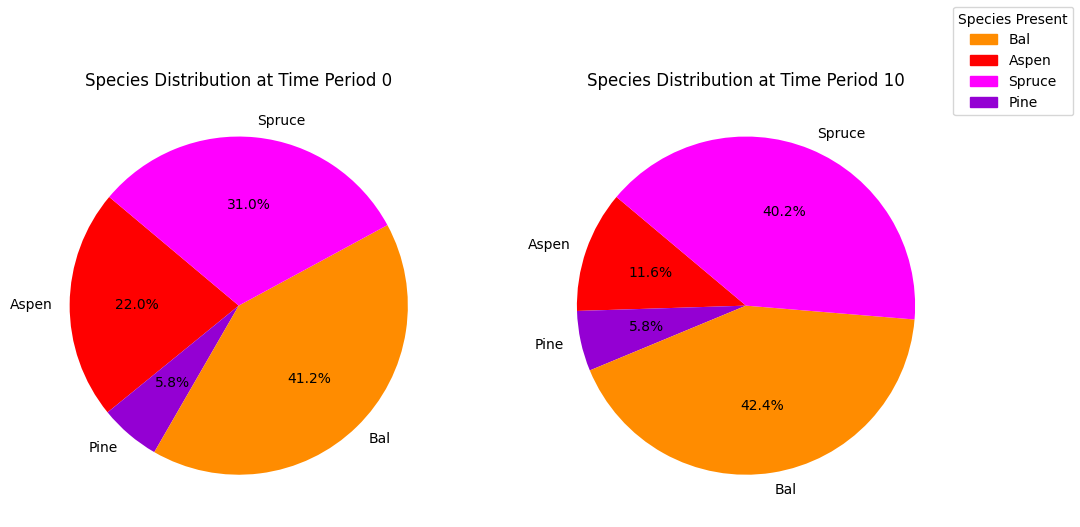

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_30%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

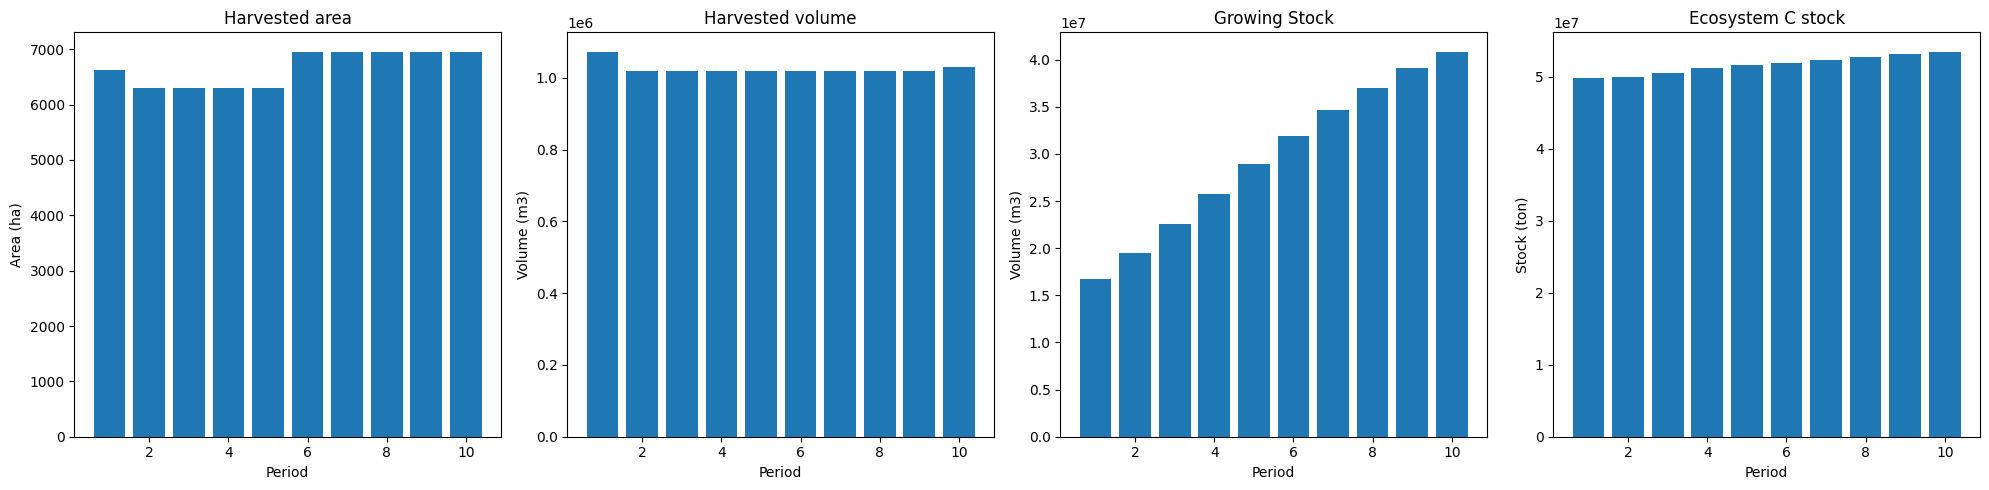

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


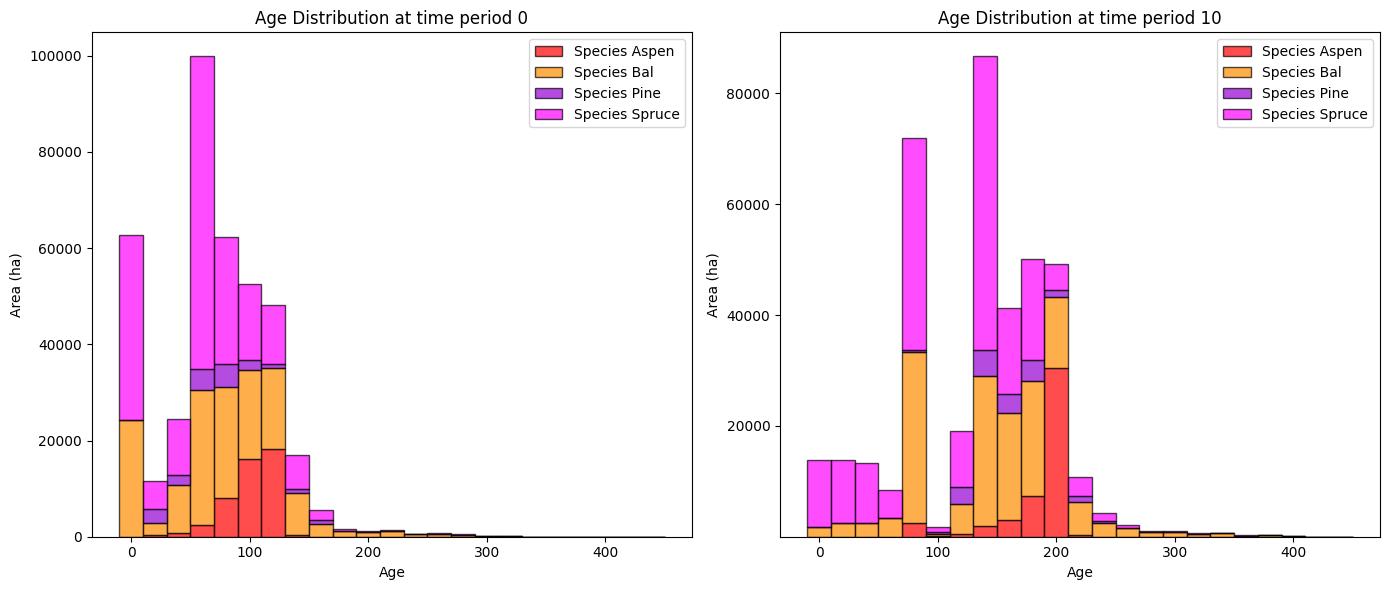

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


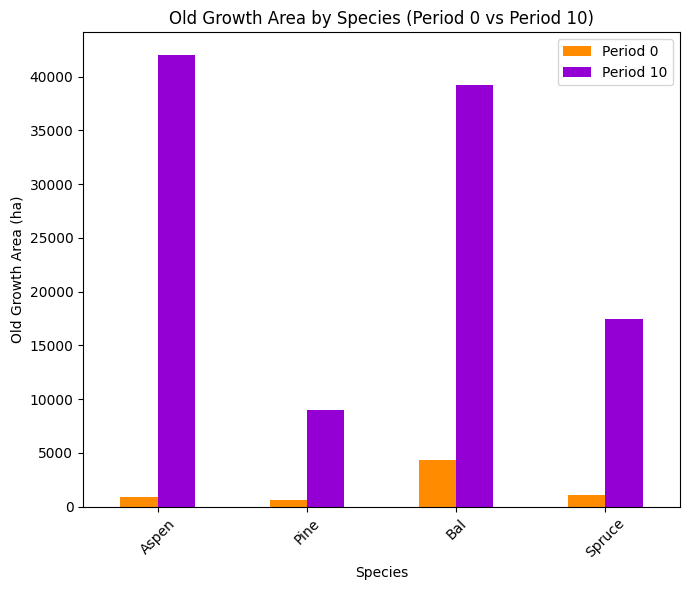

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


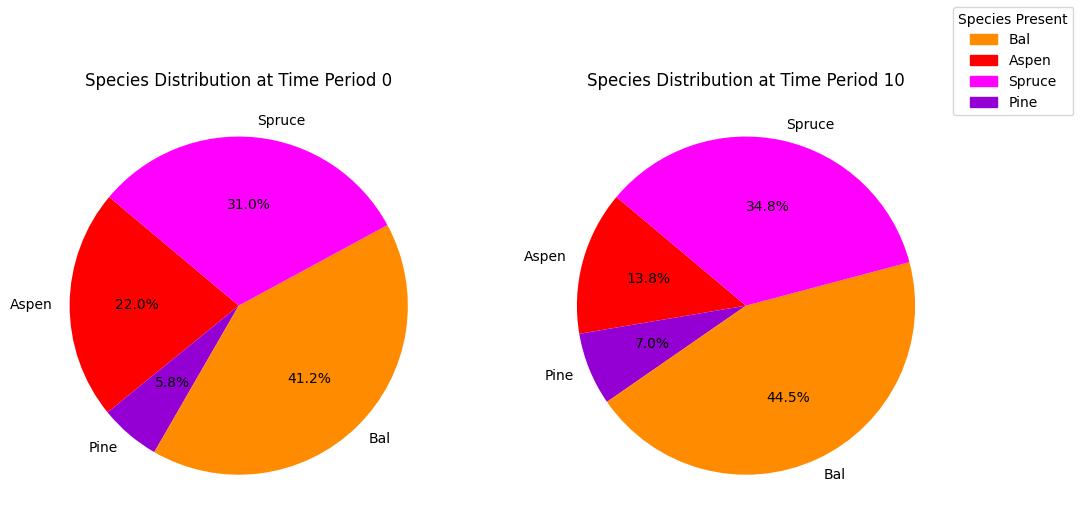

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


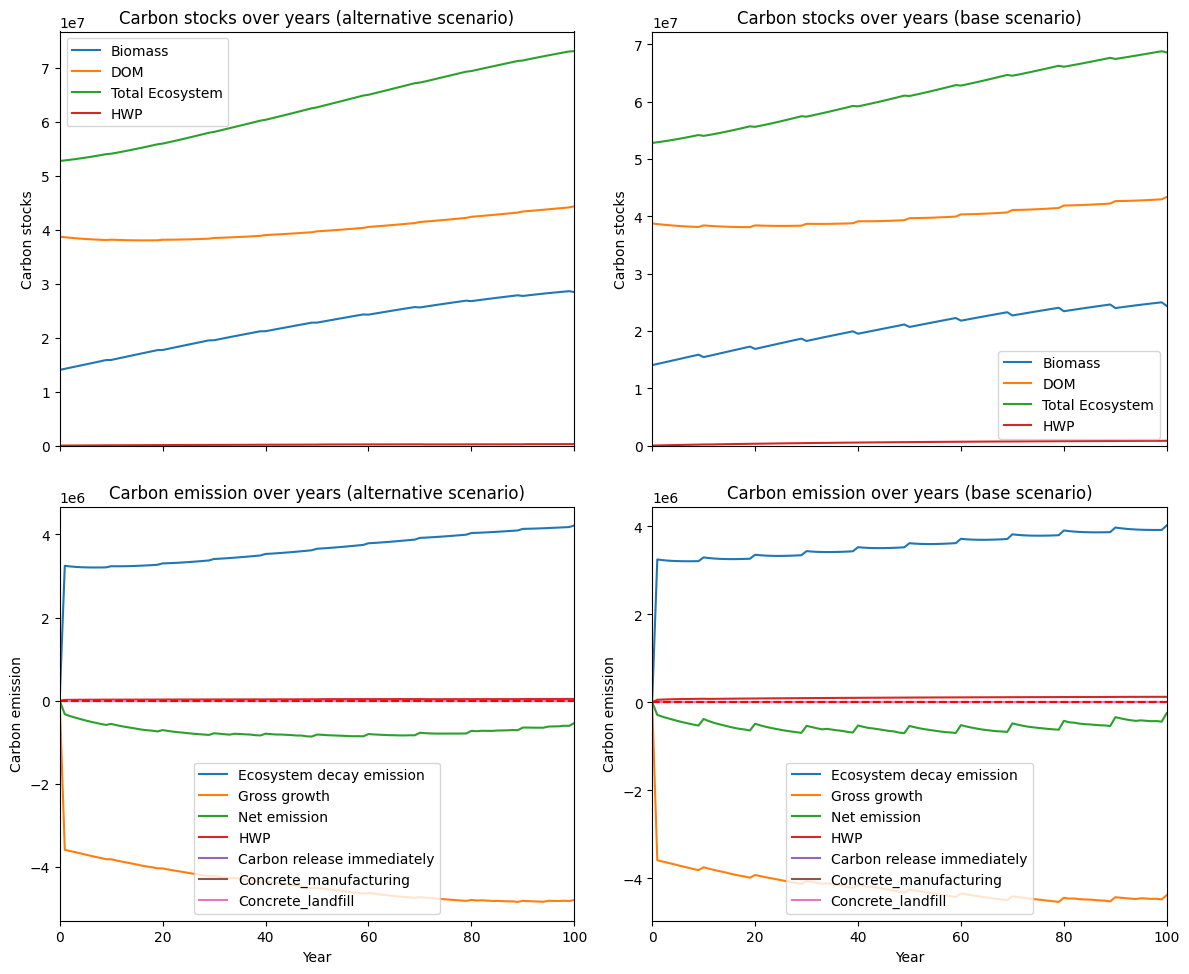

---------------------------------------------------------------------------------------
Net emission difference -2692776.1263535973
Net emission base scenario -14539191.893934494
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  3.7136395789208905
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   2343.377353   2343.377353
Pine    0.0    211.077088    211.077088
Bal     0.0  13007.314197  13007.314197
Spruce  0.0  12549.260314  12549.260314

Overall, the old growth area has **increased** by 28111.03 hectares in the alternative scenario compared to the base scenario.


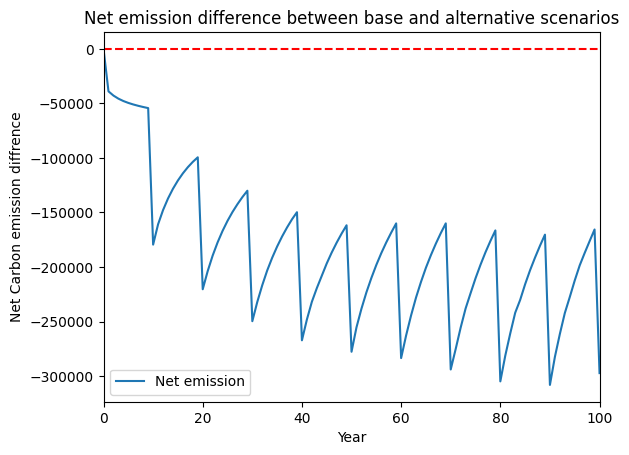

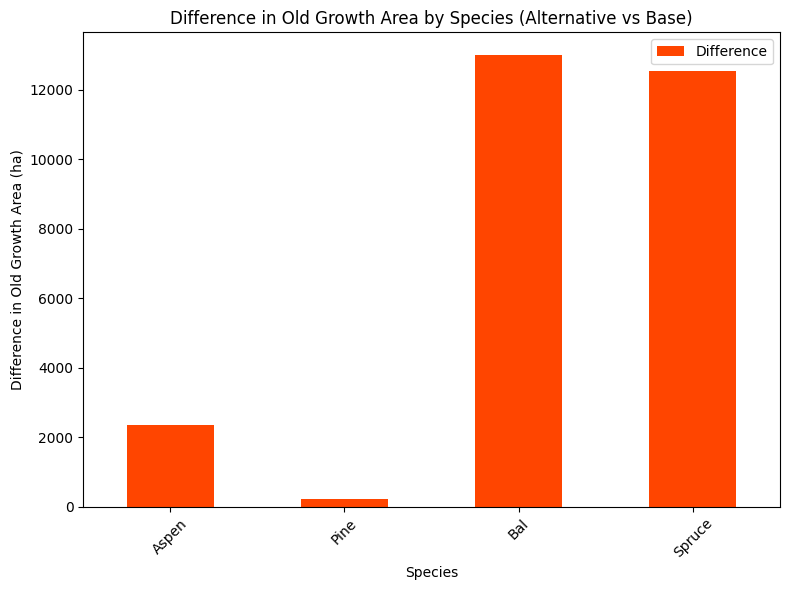

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


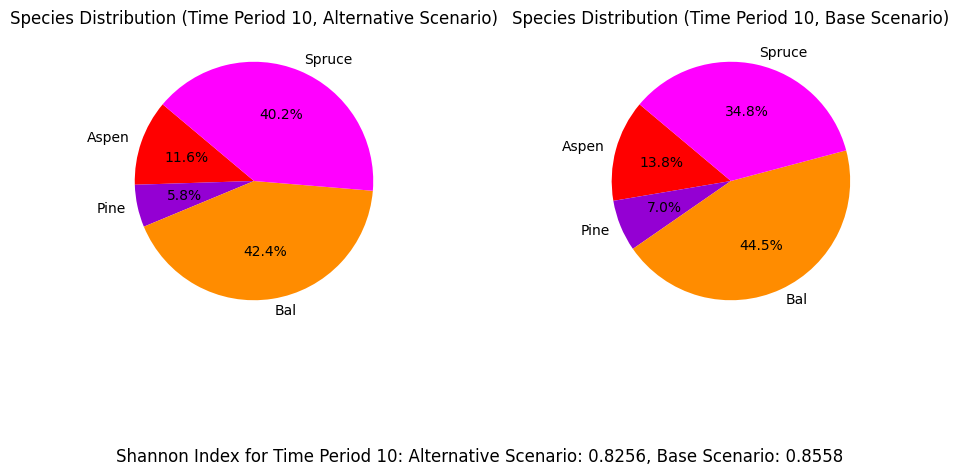

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_20%...
running the scenario for the Red Chris mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x49d22358
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32529 column

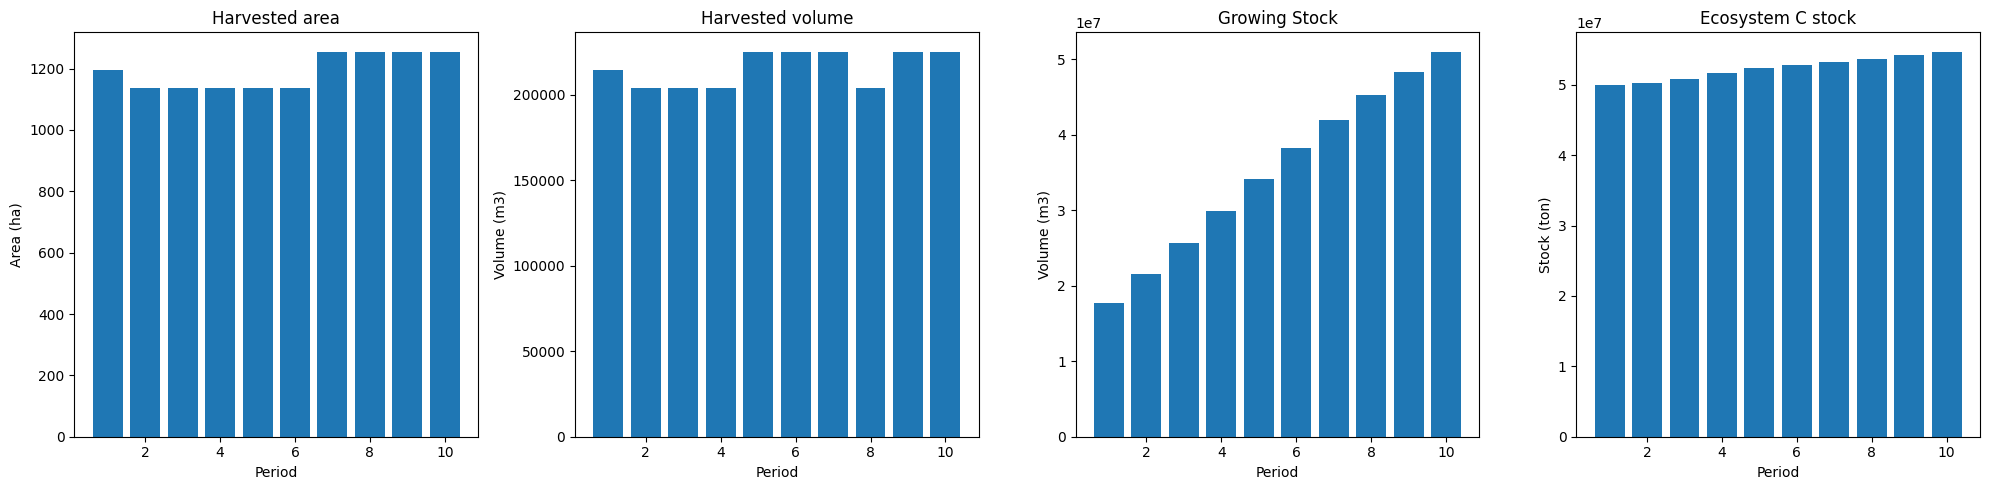

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_20%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  2279
The economic indicator (the provincial government revenues) is:  77746
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


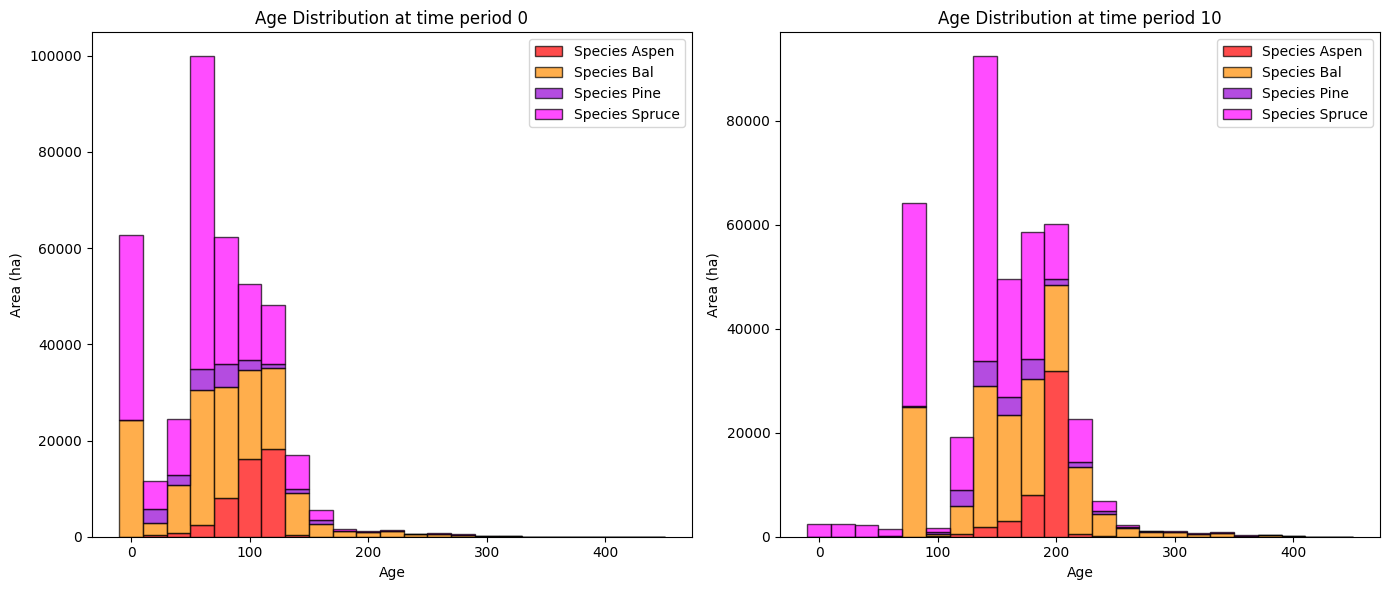

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  44508.623748  43563.310060
Pine     602.782616   9197.785905   8595.003288
Bal     4315.588546  53387.099451  49071.510905
Spruce  1072.814408  33341.177361  32268.362953

Overall diversity has **increased** by 133498.19 hectares from time period 0 to time period 10.


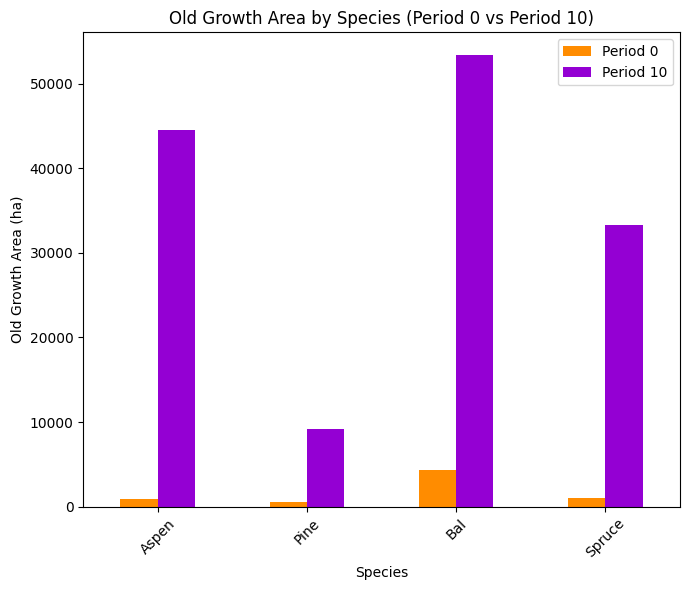

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8213

Diversity has **decreased** by 6.35% from time 0 to time 10.


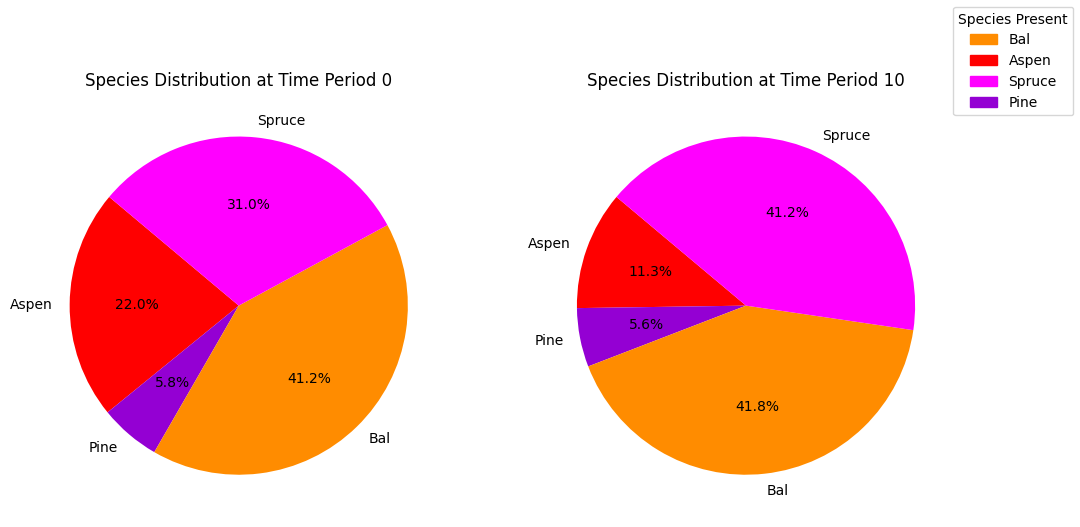

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_20%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

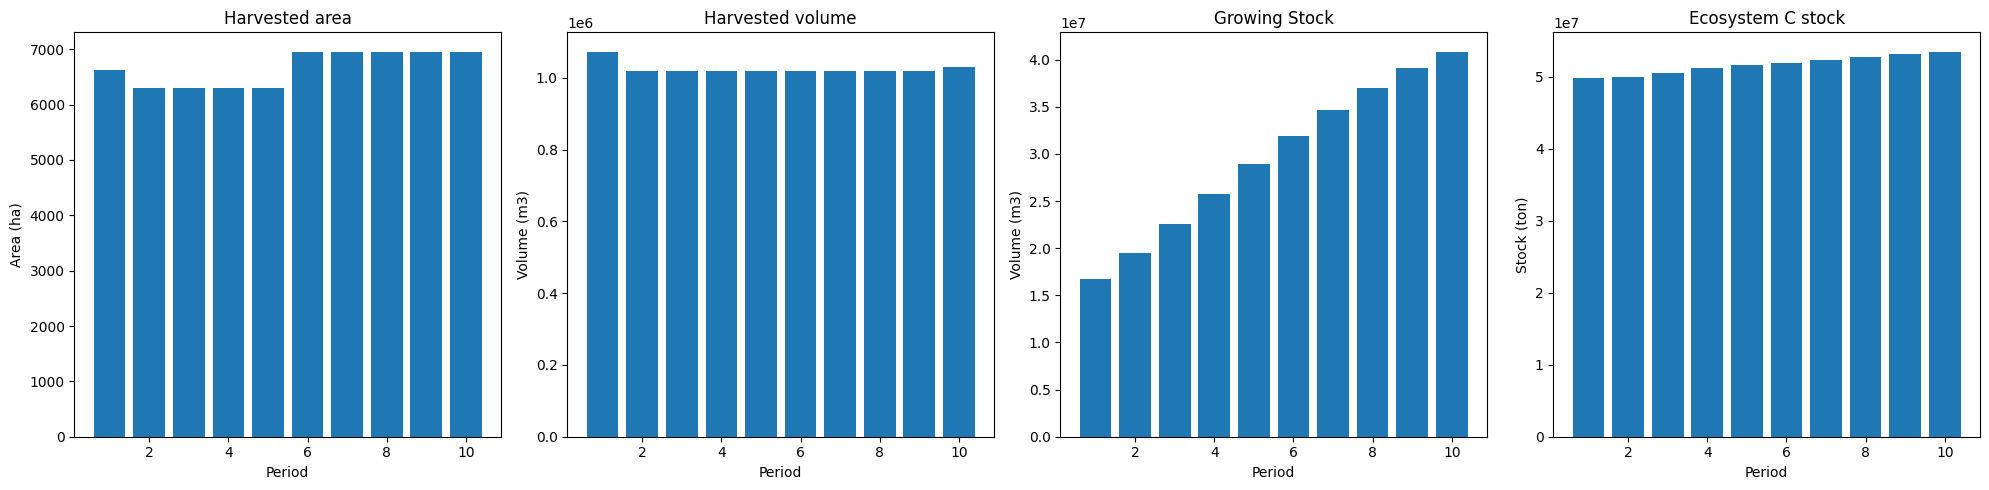

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


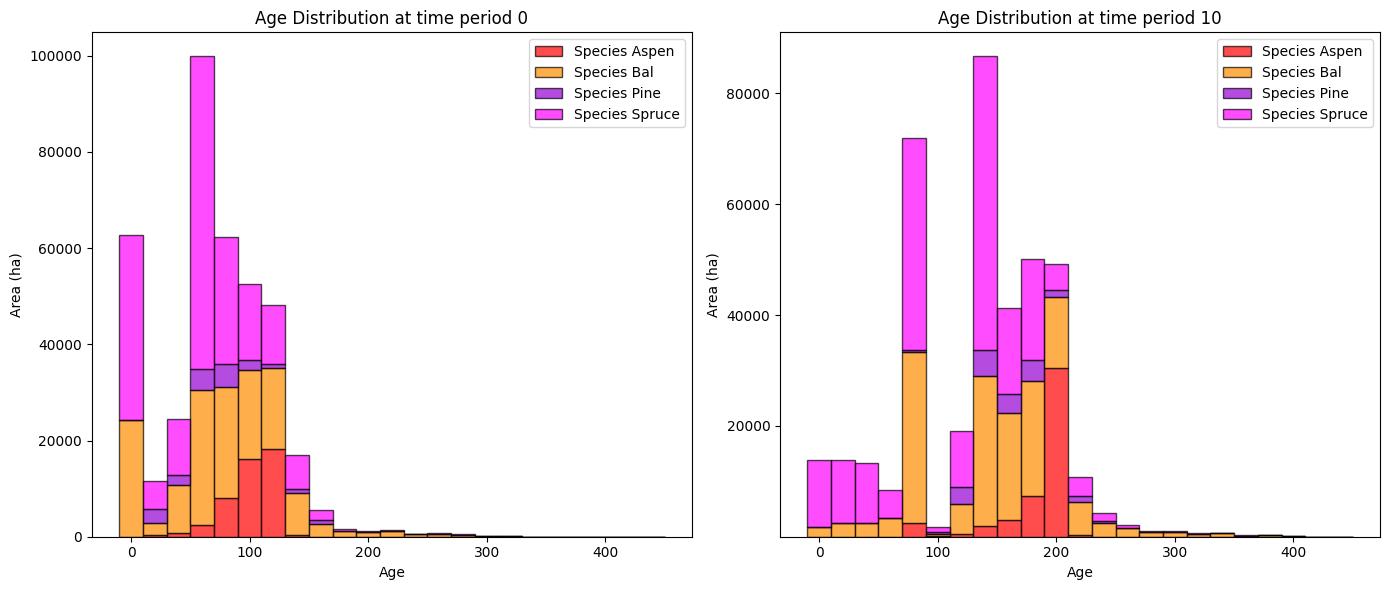

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


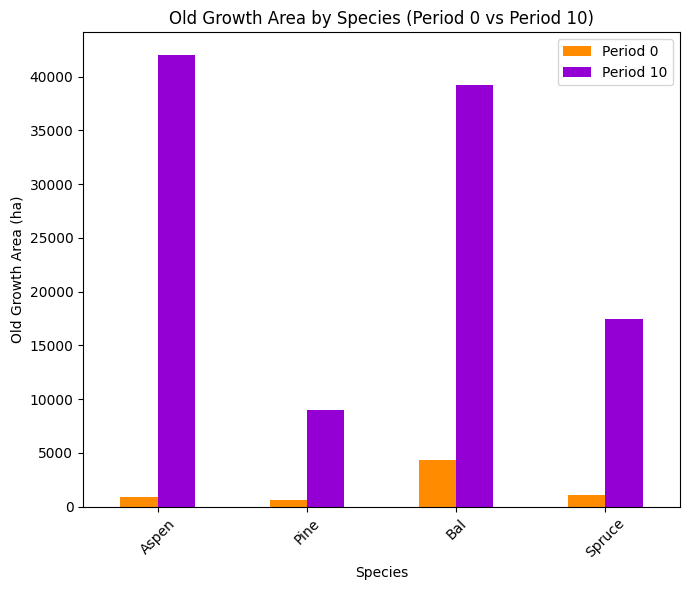

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


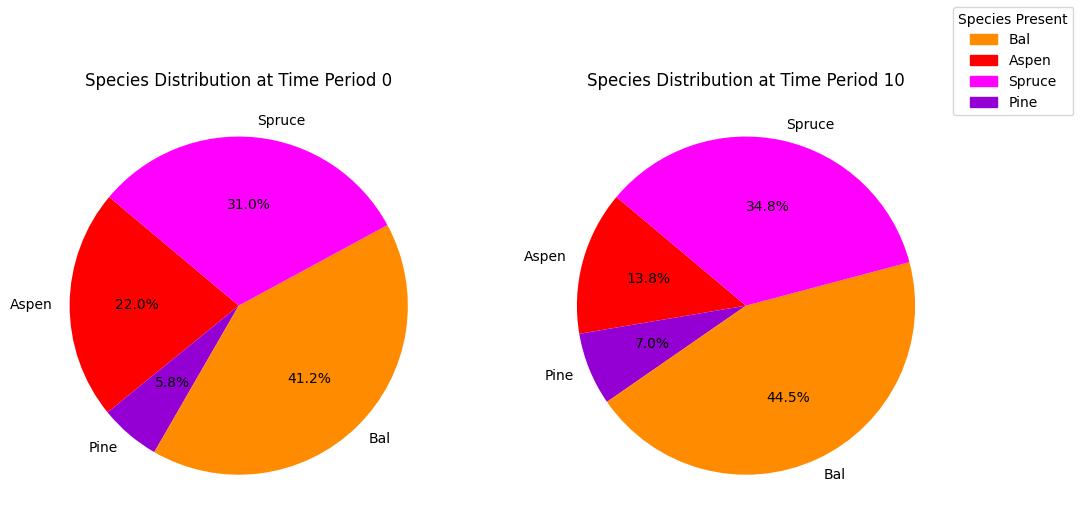

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


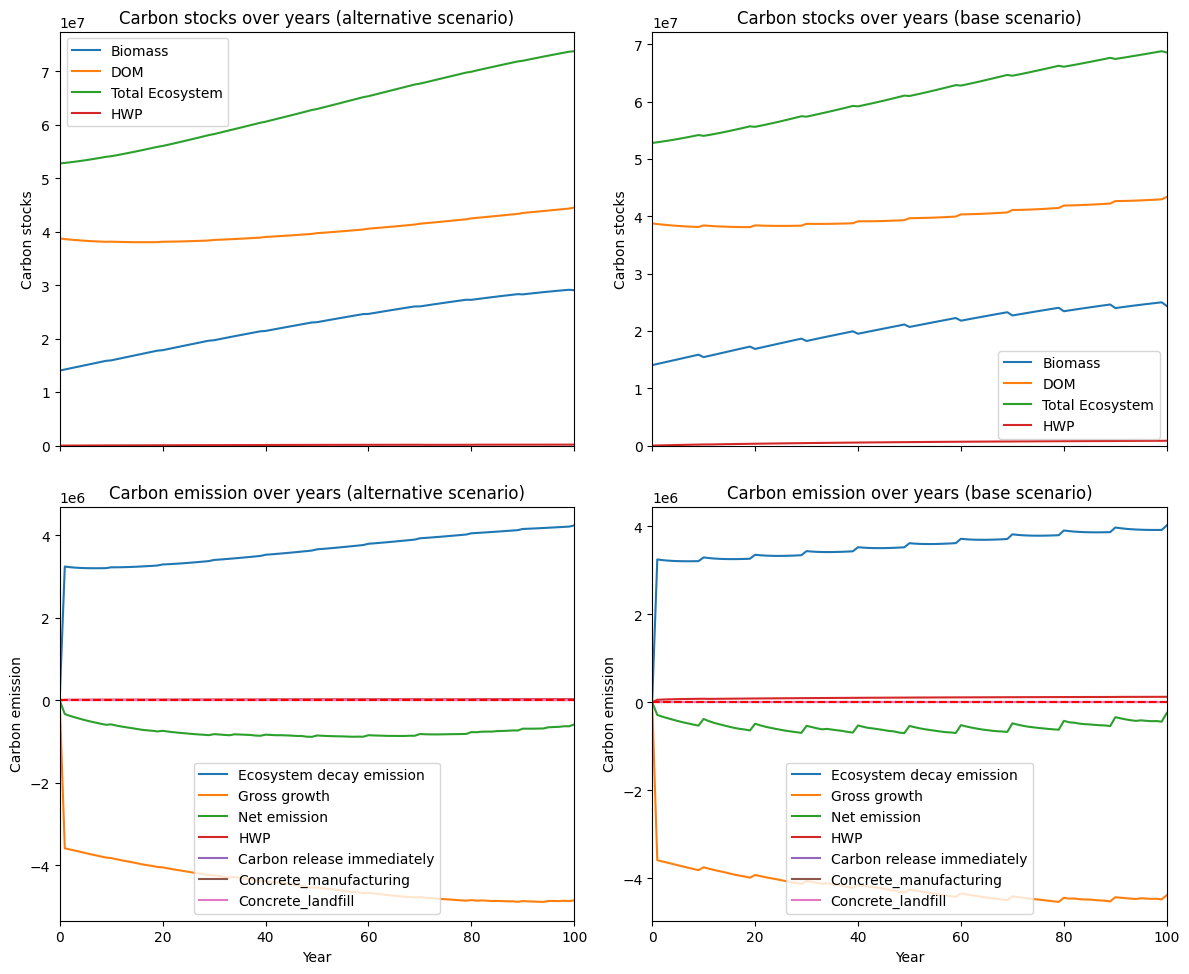

---------------------------------------------------------------------------------------
Net emission difference -3074621.6310611856
Net emission base scenario -14921037.398642082
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  3.2524327217943125
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   2497.986024   2497.986024
Pine    0.0    224.305205    224.305205
Bal     0.0  14132.985855  14132.985855
Spruce  0.0  15840.718951  15840.718951

Overall, the old growth area has **increased** by 32696.00 hectares in the alternative scenario compared to the base scenario.


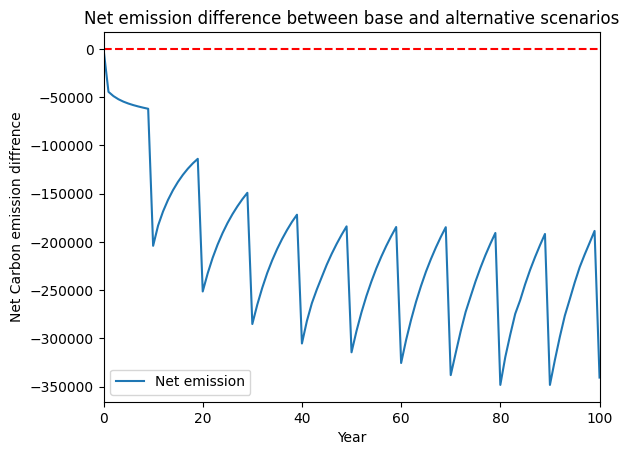

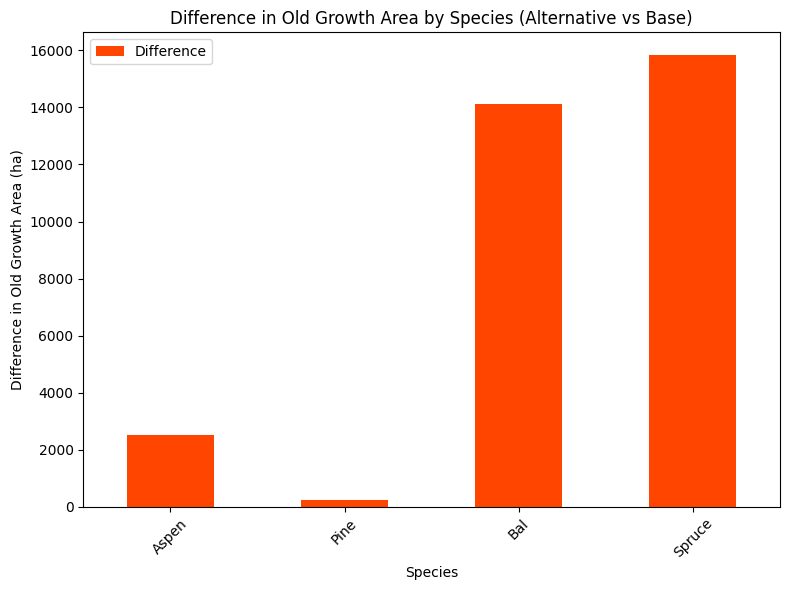

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


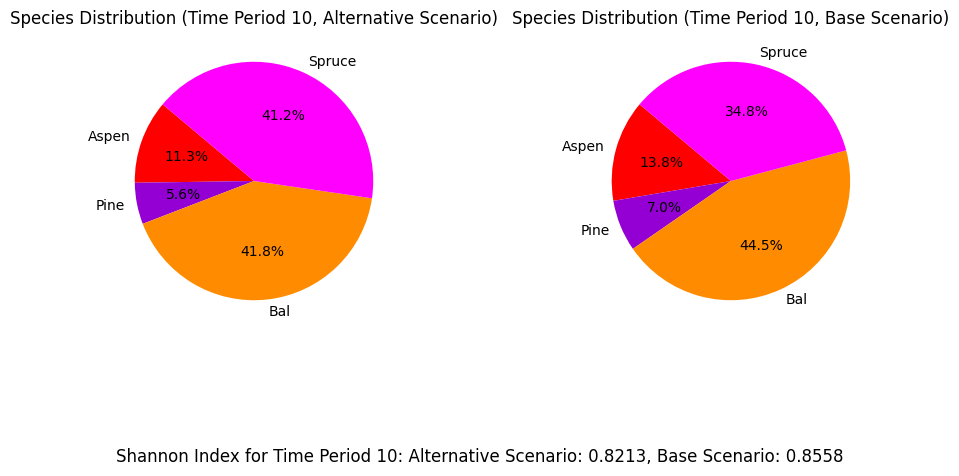

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_max_st_redchrs_AAC_10%...
running the scenario for the Red Chris mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xdb5d211c
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.18s
Presolved: 1699 rows, 32529 column

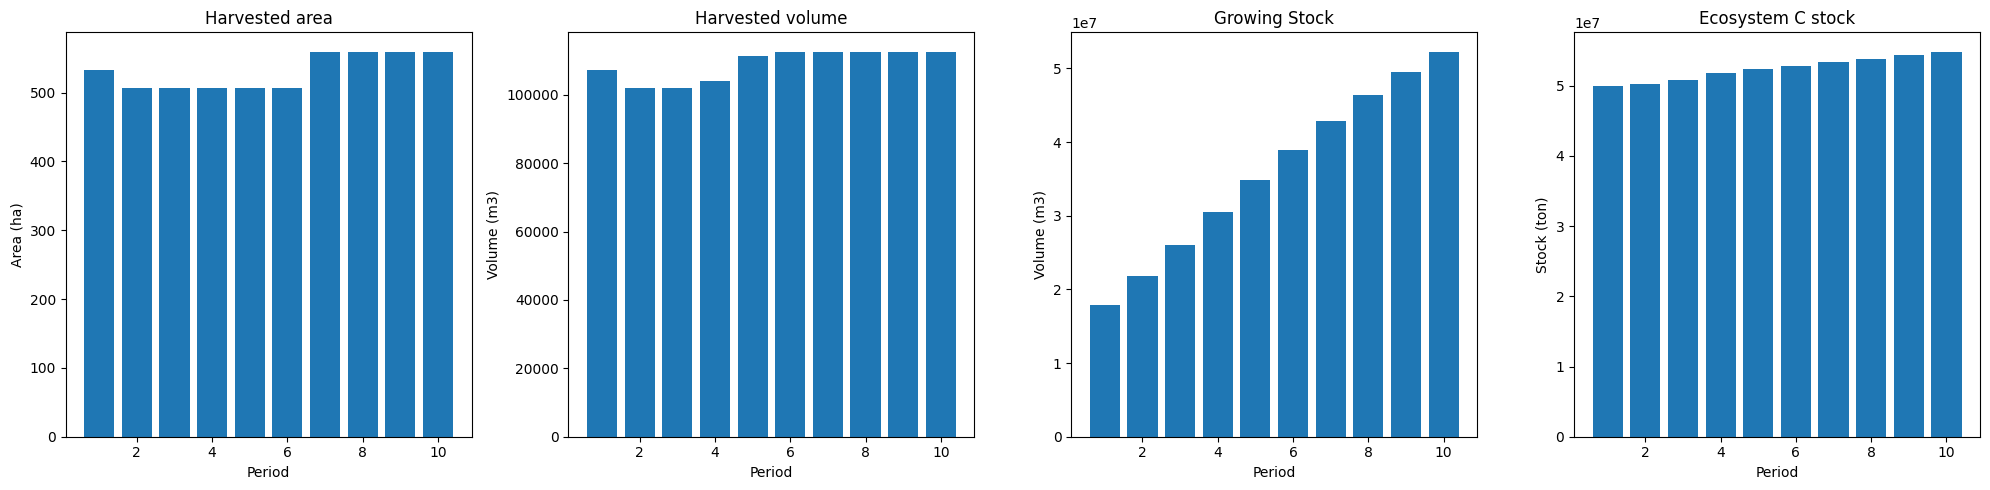

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_10%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  1152
The economic indicator (the provincial government revenues) is:  39291
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


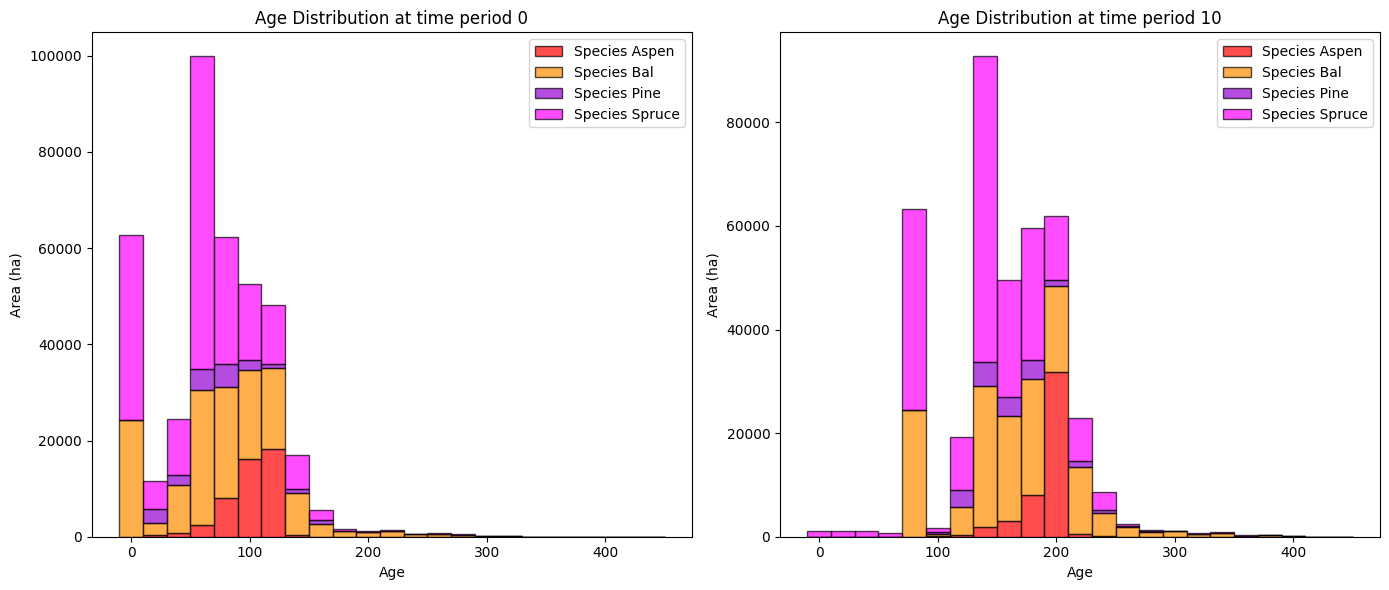

Plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  44508.623748  43563.310060
Pine     602.782616   9389.986273   8787.203656
Bal     4315.588546  53953.406022  49637.817476
Spruce  1072.814408  37810.499083  36737.684675

Overall diversity has **increased** by 138726.02 hectares from time period 0 to time period 10.


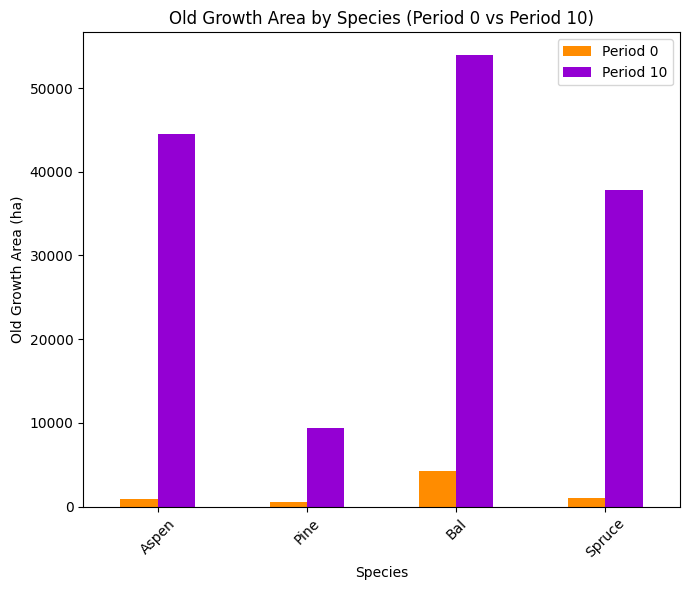

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8169

Diversity has **decreased** by 6.80% from time 0 to time 10.


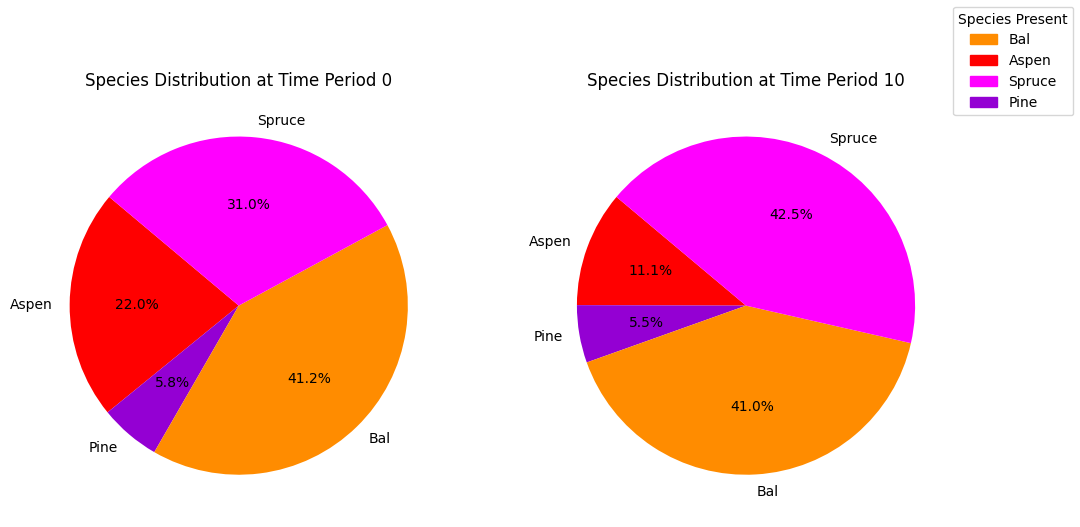

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_redchrs_AAC_10%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xa6023906
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [2e+02, 4e+07]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.16s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

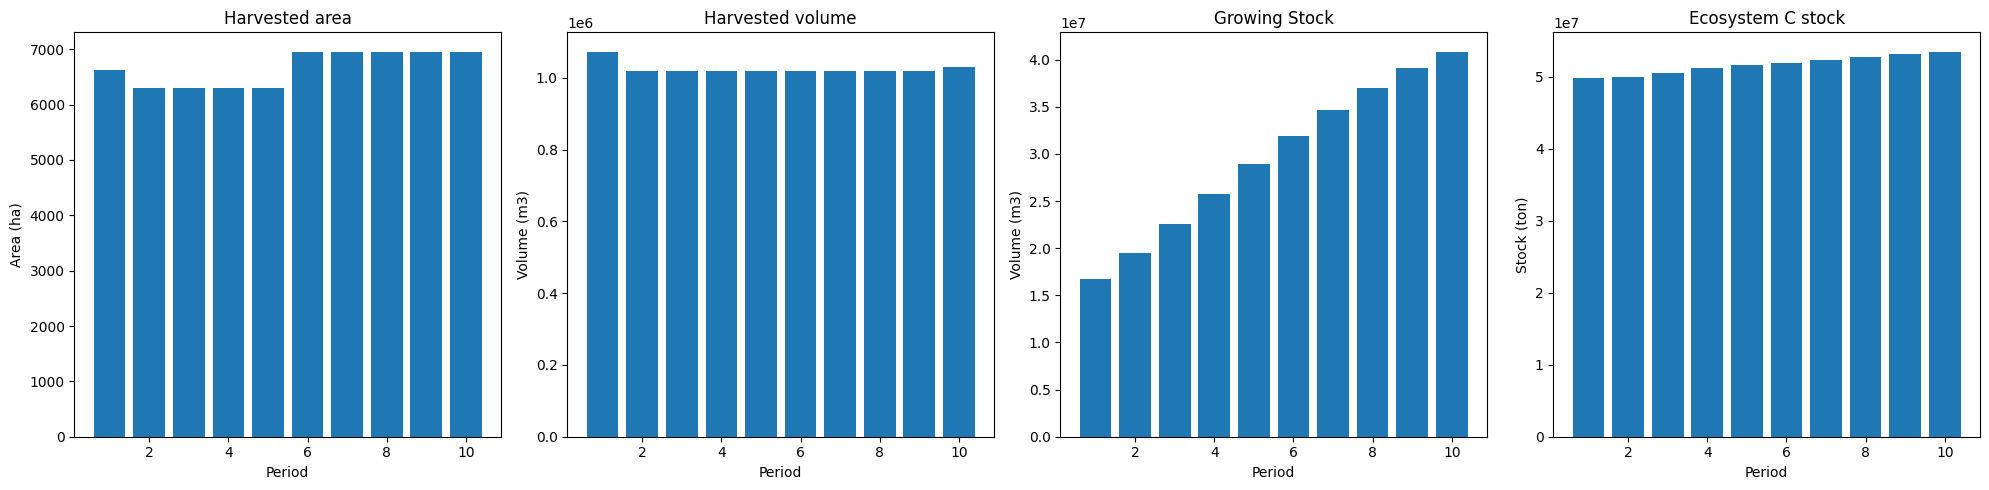

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10842
The economic indicator (the provincial government revenues) is:  369749
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


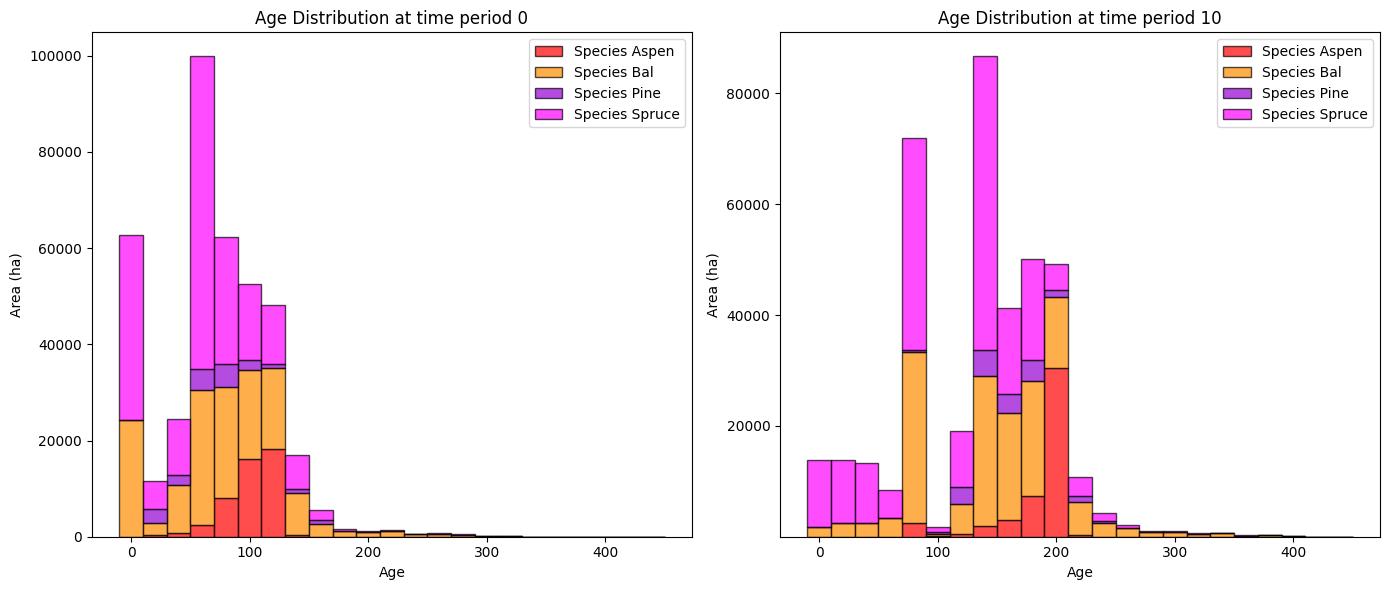

Plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  42010.637725  41065.324037
Pine     602.782616   8973.480700   8370.698084
Bal     4315.588546  39254.113596  34938.525050
Spruce  1072.814408  17500.458410  16427.644002

Overall diversity has **increased** by 100802.19 hectares from time period 0 to time period 10.


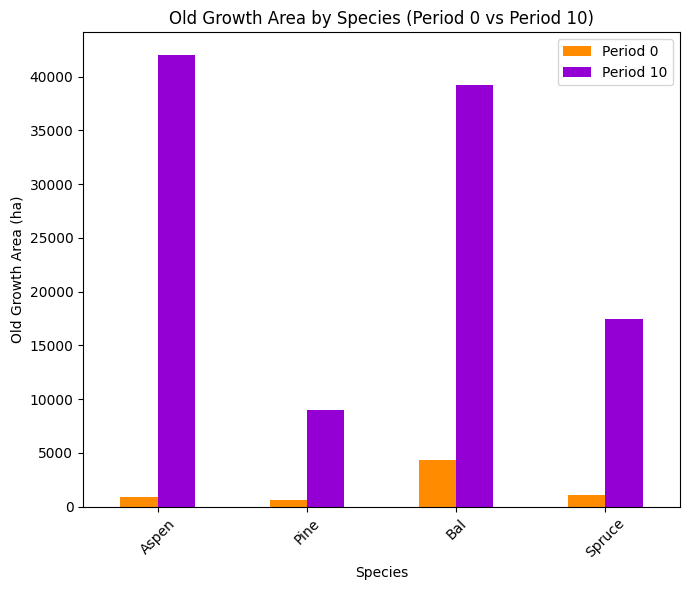

Clustered column plot saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8558

Diversity has **decreased** by 2.91% from time 0 to time 10.


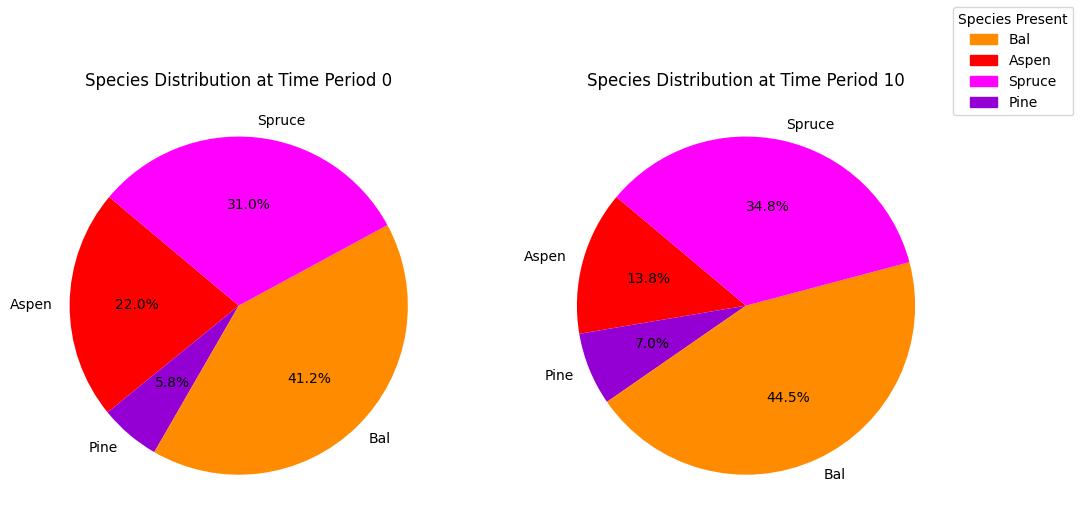

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_bau_redchrs_species_pie.pdf


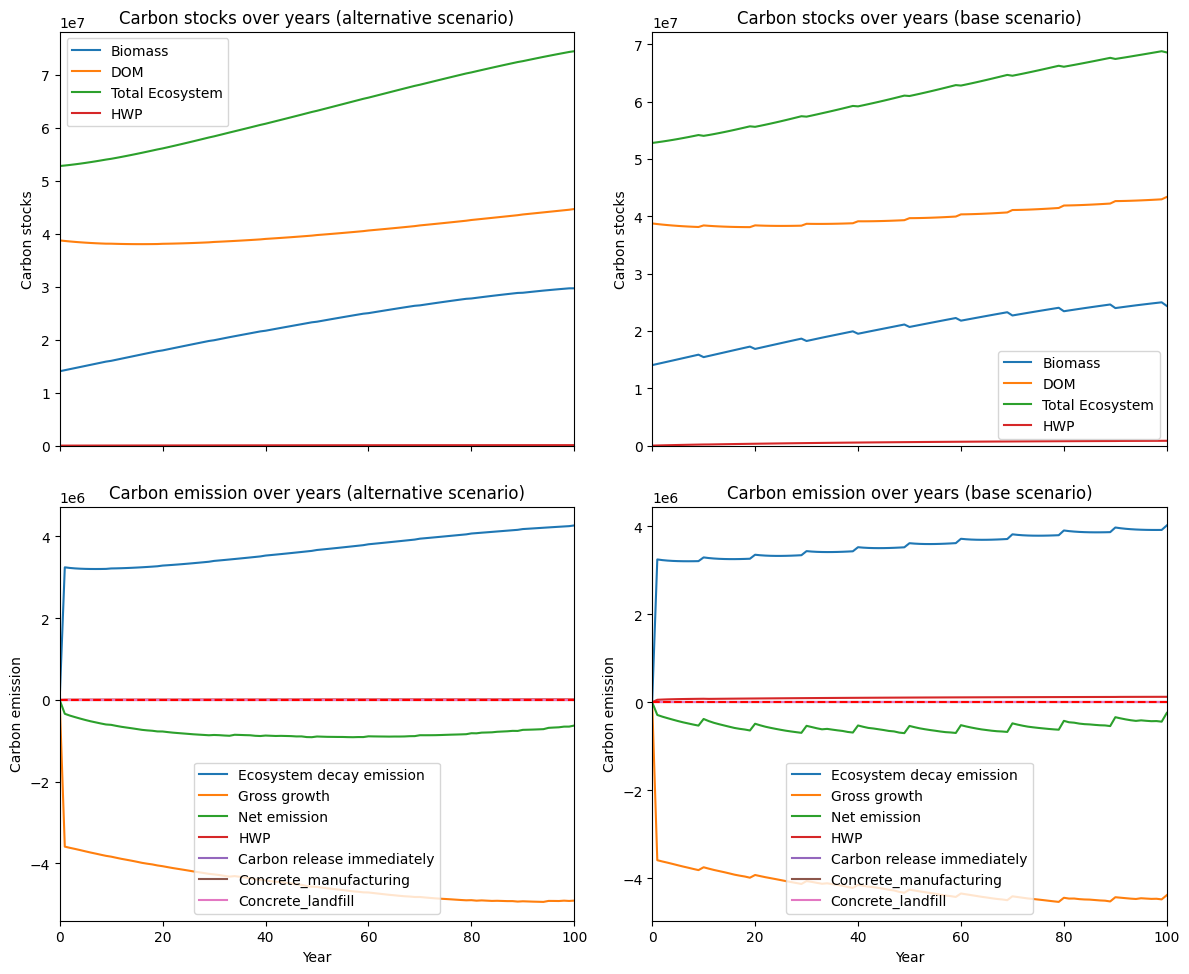

---------------------------------------------------------------------------------------
Net emission difference -3466713.515233204
Net emission base scenario -15313129.2828141
Net emission alternative scenario -11846415.767580897
dollar_per_ton is:  2.8845764024222538
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   2497.986024   2497.986024
Pine    0.0    416.505573    416.505573
Bal     0.0  14699.292426  14699.292426
Spruce  0.0  20310.040673  20310.040673

Overall, the old growth area has **increased** by 37923.82 hectares in the alternative scenario compared to the base scenario.


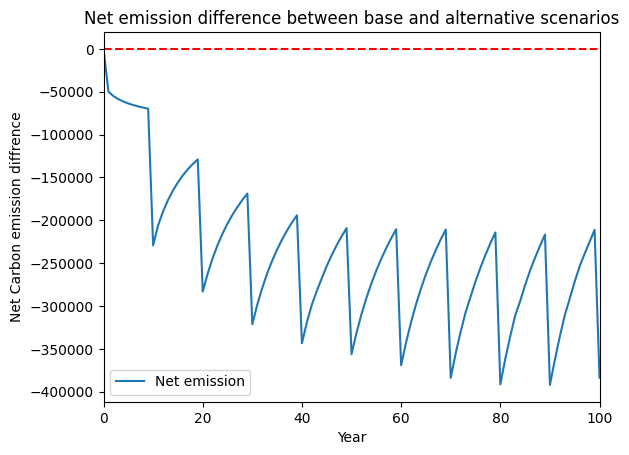

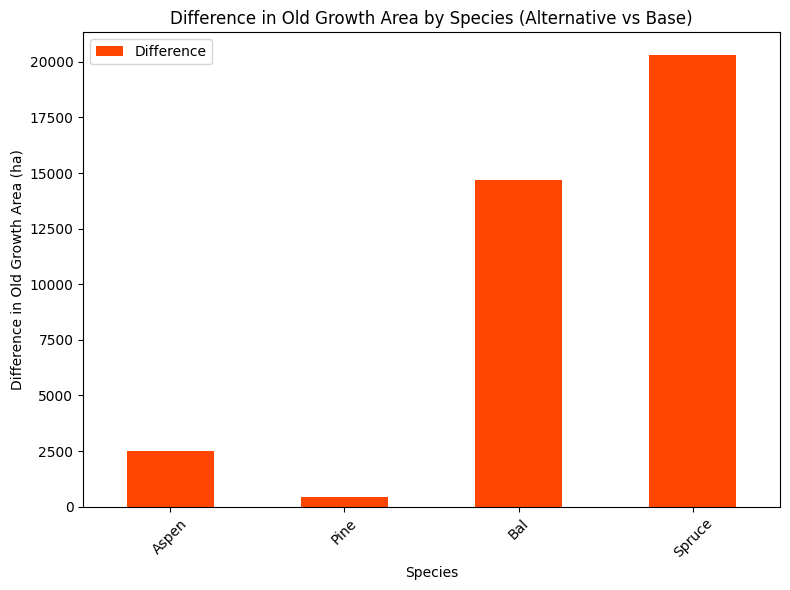

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_max_st_kpi_age_difference.pdf


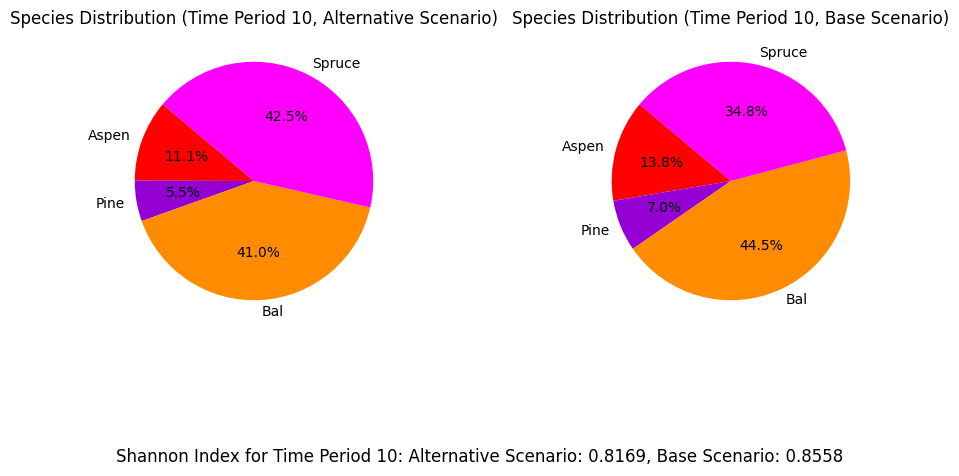

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 70.8 minutes to run all scenarios.


In [26]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [27]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 70.8 minutes to run this script.
